# final11 — Y 1개월 SHIFT 버전

기존 final11 구조는 최대한 유지하고, 타깃만 `Y_t → Y_{t+1}` 구조로 변경한 실험용 노트북이다.

- 기존 final11: `X_t → y_t`
- 본 노트북: `X_t → y_next1 = y_{t+1}`
- 해석: 현재월까지의 거래/파생/외부변수로 다음 월 거래활동성 약화 위험을 예측
- 주의: 기존 final11 성능/SHAP/페르소나와 직접 비교 가능하되, 타깃 정의가 달라졌으므로 결과는 새로 확인해야 한다.


## STEP 0. 라이브러리

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
)

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError("lightgbm이 설치되어 있어야 합니다. `pip install lightgbm` 후 다시 실행하세요.") from e

matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Mac: 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

EPS = 1e-6
EPS2 = 1e-9
RANDOM_STATE = 42
DATA_PATH = '36.csv'
NOTEBOOK_NAME = 'final11'

print(f'NOTEBOOK_NAME = {NOTEBOOK_NAME}')

NOTEBOOK_NAME = final11


## STEP 1. 데이터 로드 + 누락검정 기반 보간

In [2]:
import os
from scipy.stats import norm

# ============================================================
# final11 데이터 구성
# - 원본 전체 법인데이터.csv에서 누락검정 수행
# - 완전관측_정상 + 중간랜덤누락_보간후보만 사용
# - 보간 엔진은 기존 규칙 기반 구조를 유지
# - CSV 출력은 하지 않고 df로 바로 사용
# ============================================================

INPUT_PATH = r'iM_edu.csv'
PERIOD = ('2023-01', '2025-12')
ZERO_CNT_LABEL = '0건'
RUNS_ALPHA = 0.05
GAP_ALPHA = 0.01
APPLY_RANDOM_FILTER_TO_MID = True

# ------------------------------------------------------------
# 1. 보간 컬럼 분류 유틸
# ------------------------------------------------------------
def infer_decimals(s, max_sample=1000):
    """관측값의 소수 자릿수를 추정하여 보간 후 라운딩 자릿수로 사용."""
    vals = pd.to_numeric(s, errors='coerce').dropna().head(max_sample)
    if len(vals) == 0:
        return 0

    decs = []
    for v in vals:
        txt = str(v)
        if 'e' in txt.lower():
            txt = f'{float(v):.10f}'.rstrip('0').rstrip('.')
        if '.' in txt:
            decs.append(len(txt.split('.')[-1].rstrip('0')))
        else:
            decs.append(0)
    return int(max(decs)) if decs else 0


def classify_columns(df):
    """
    보간 규칙별 컬럼 분류.
    - locf: 범주형 상태 + 보유수 버킷
    - zero_cnt: 거래건수 버킷 → 결측 0건
    - zero_amt: 발생성 금액/실적/사용액 → 결측 0
    - cont: 잔액/한도 등 상태성 연속값 → 내부 선형보간 + ffill/bfill
    """
    id_cols = {'법인ID', '기준년월'}
    groups = {'locf': [], 'zero_cnt': [], 'zero_amt': [], 'cont': []}

    for c in df.columns:
        if c in id_cols:
            continue

        cs = str(c)

        # 거래건수 버킷은 결측 월에 거래 없음으로 처리
        if '거래건수' in cs:
            groups['zero_cnt'].append(c)
            continue

        # 범주형 상태 / 보유수 버킷
        if (
            cs in ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구']
            or '좌수' in cs
            or '개수' in cs
        ):
            groups['locf'].append(c)
            continue

        # 잔액/한도는 상태성 연속값
        if any(k in cs for k in ['잔액', '한도']):
            groups['cont'].append(c)
            continue

        # 금액/실적/사용액은 발생성 flow로 보고 결측 0
        if any(k in cs for k in ['금액', '실적', '사용액']):
            groups['zero_amt'].append(c)
            continue

        # 기타 object/category는 LOCF
        if not pd.api.types.is_numeric_dtype(df[c]):
            groups['locf'].append(c)
            continue

        # 기타 숫자형은 보수적으로 상태성 연속값 처리
        groups['cont'].append(c)

    return groups


# ------------------------------------------------------------
# 2. 누락검정 프로필 생성 유틸
# ------------------------------------------------------------
def make_obs_vector(corp_df, all_months):
    actual_months = set(corp_df['기준년월'])
    return [1 if m in actual_months else 0 for m in all_months]


def runs_test_binary(obs_vector):
    """
    H0: 관측(1)과 누락(0)은 랜덤하게 배열되어 있다.
    H1: 관측/누락이 군집되어 있다.
    단측검정: runs가 기대보다 유의하게 적은 방향.
    """
    x = np.array([int(v) for v in obs_vector])
    n1 = np.sum(x == 1)
    n0 = np.sum(x == 0)

    if n0 == 0 or n1 == 0:
        return {
            'runs': np.nan,
            'expected_runs': np.nan,
            'var_runs': np.nan,
            'z_runs': np.nan,
            'p_runs_lower': np.nan,
            'runs_result': '검정불가'
        }

    runs = 1 + np.sum(x[1:] != x[:-1])
    n = len(x)
    expected_runs = 1 + (2 * n1 * n0) / n
    var_runs = ((2 * n1 * n0) * (2 * n1 * n0 - n)) / (n**2 * (n - 1))

    if var_runs <= 0:
        return {
            'runs': runs,
            'expected_runs': expected_runs,
            'var_runs': var_runs,
            'z_runs': np.nan,
            'p_runs_lower': np.nan,
            'runs_result': '검정불가'
        }

    z = (runs - expected_runs) / np.sqrt(var_runs)
    p_lower = norm.cdf(z)
    result = '비랜덤_군집누락' if (p_lower < RUNS_ALPHA and z < 0) else '랜덤누락_가능'

    return {
        'runs': runs,
        'expected_runs': expected_runs,
        'var_runs': var_runs,
        'z_runs': z,
        'p_runs_lower': p_lower,
        'runs_result': result
    }


def build_corp_profile(df, all_months, q_miss):
    N_MONTHS = len(all_months)
    FIRST_MONTH = all_months[0]
    LAST_MONTH = all_months[-1]

    rows = []

    for corp_id, corp_df in df.groupby('법인ID'):
        obs_vector_list = make_obs_vector(corp_df, all_months)
        obs_vector = ''.join(map(str, obs_vector_list))

        month_cnt = sum(obs_vector_list)
        total_gap = N_MONTHS - month_cnt

        if month_cnt == 0:
            continue

        first_idx = obs_vector_list.index(1)
        last_idx = len(obs_vector_list) - 1 - obs_vector_list[::-1].index(1)

        first_month = all_months[first_idx]
        last_month = all_months[last_idx]
        leading_gap = first_idx
        trailing_gap = N_MONTHS - 1 - last_idx

        # 중간 누락 구간
        internal_gaps = []
        current_gap = 0
        for i in range(first_idx, last_idx + 1):
            if obs_vector_list[i] == 0:
                current_gap += 1
            else:
                if current_gap > 0:
                    internal_gaps.append(current_gap)
                current_gap = 0
        if current_gap > 0:
            internal_gaps.append(current_gap)

        max_internal_gap = max(internal_gaps, default=0)
        total_internal_gap = sum(internal_gaps)
        internal_gap_cnt = len(internal_gaps)

        # 전체 최대 연속 누락
        all_gaps = []
        current_gap = 0
        for v in obs_vector_list:
            if v == 0:
                current_gap += 1
            else:
                if current_gap > 0:
                    all_gaps.append(current_gap)
                current_gap = 0
        if current_gap > 0:
            all_gaps.append(current_gap)

        max_gap = max(all_gaps, default=0)
        gap_cnt = len(all_gaps)

        runs_info = runs_test_binary(obs_vector_list)

        rows.append({
            '법인ID': corp_id,
            'obs_vector': obs_vector,
            'month_cnt': month_cnt,
            'total_gap': total_gap,
            'gap_cnt': gap_cnt,
            'max_gap': max_gap,
            'first_month': first_month,
            'last_month': last_month,
            'leading_gap': leading_gap,
            'trailing_gap': trailing_gap,
            'internal_gap_cnt': internal_gap_cnt,
            'max_internal_gap': max_internal_gap,
            'total_internal_gap': total_internal_gap,
            **runs_info
        })

    prof = pd.DataFrame(rows)

    def classify_life_type(row):
        first = row['first_month']
        last = row['last_month']
        max_internal_gap = row['max_internal_gap']

        if first == FIRST_MONTH and last == LAST_MONTH:
            return '완전관측형' if max_internal_gap == 0 else '중간누락형'
        elif first > FIRST_MONTH and last == LAST_MONTH:
            return '신규유입후보'
        elif first == FIRST_MONTH and last < LAST_MONTH:
            return '중도종료후보'
        elif first > FIRST_MONTH and last < LAST_MONTH:
            return '불완전관측형'
        return '기타'

    prof['life_type'] = prof.apply(classify_life_type, axis=1)

    prof['p_leading_gap'] = q_miss ** prof['leading_gap']
    prof['p_trailing_gap'] = q_miss ** prof['trailing_gap']
    prof.loc[prof['leading_gap'] == 0, 'p_leading_gap'] = 1
    prof.loc[prof['trailing_gap'] == 0, 'p_trailing_gap'] = 1

    prof['missing_randomness'] = np.where(
        prof['runs_result'] == '비랜덤_군집누락',
        '비랜덤_군집누락',
        '랜덤누락_가능'
    )

    def final_status(row):
        lt = row['life_type']
        lead_sig = row['p_leading_gap'] < GAP_ALPHA
        trail_sig = row['p_trailing_gap'] < GAP_ALPHA
        internal_nonrandom = row['runs_result'] == '비랜덤_군집누락'

        if lt == '완전관측형':
            return '완전관측_정상'

        if lt == '신규유입후보':
            return '신규유입' if lead_sig else '초반단기누락_보간후보'

        if lt == '중도종료후보':
            return '중도종료_이탈후보' if trail_sig else '후반단기누락_보간후보'

        if lt == '중간누락형':
            return '중간군집누락_비활동후복귀후보' if internal_nonrandom else '중간랜덤누락_보간후보'

        if lt == '불완전관측형':
            if lead_sig and trail_sig:
                return '신규유입후_중도종료후보'
            elif lead_sig and not trail_sig:
                return '신규유입후_후반단기누락보간후보'
            elif not lead_sig and trail_sig:
                return '초반단기누락보간후_중도종료후보'
            else:
                return '초반후반_단기누락보간후보'

        return '기타'

    prof['final_status'] = prof.apply(final_status, axis=1)
    return prof


# ------------------------------------------------------------
# 3. 보간 엔진
# ------------------------------------------------------------
def impute_corp(g, all_months, groups, dec_map):
    """단일 법인 g를 36개월 풀패널로 재확장 + 규칙별 보간. frame 반환."""
    base = pd.DataFrame({'기준년월': all_months})
    merged = base.merge(g, on='기준년월', how='left')
    merged['보간여부'] = merged['법인ID'].isna().astype(int)
    merged['법인ID'] = g['법인ID'].iloc[0]

    # 범주형 상태 + 보유수 버킷: LOCF → NOCB 폴백
    for c in groups['locf']:
        if c in merged.columns:
            merged[c] = merged[c].ffill().bfill()

    # 거래건수 버킷: "0건"
    for c in groups['zero_cnt']:
        if c in merged.columns:
            merged[c] = merged[c].fillna(ZERO_CNT_LABEL)

    # 발생성 금액: 0
    for c in groups['zero_amt']:
        if c in merged.columns:
            merged[c] = merged[c].fillna(0)

    # 연속형 상태(잔액/한도): 내부=선형보간, 후반=LOCF, 초반=NOCB → 재라운딩
    for c in groups['cont']:
        if c in merged.columns:
            s = pd.to_numeric(merged[c], errors='coerce')
            s = s.interpolate(method='linear', limit_area='inside')
            s = s.ffill().bfill()
            merged[c] = s.round(dec_map.get(c, 0))

    return merged


# ------------------------------------------------------------
# 4. 실행 함수
# ------------------------------------------------------------
def main(input_path=INPUT_PATH):
    df_raw = pd.read_csv(input_path)
    df_raw['기준년월'] = (
        df_raw['기준년월']
        .astype(str)
        .str.replace('-', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.slice(0, 6)
        .astype(int)
    )

    months = pd.period_range(PERIOD[0], PERIOD[1], freq='M')
    all_months = [int(m.strftime('%Y%m')) for m in months]
    N = len(all_months)

    df_raw = (
        df_raw[df_raw['기준년월'].isin(all_months)]
        .drop_duplicates(['법인ID', '기준년월'], keep='last')
        .sort_values(['법인ID', '기준년월'])
        .reset_index(drop=True)
    )

    n_corp = df_raw['법인ID'].nunique()
    q_miss = 1 - len(df_raw) / (n_corp * N)
    print(f'법인수={n_corp:,}  관측치={len(df_raw):,}  q_miss={q_miss:.4f}')

    groups = classify_columns(df_raw)
    dec_map = {c: infer_decimals(df_raw[c]) for c in groups['cont']}
    print('분류: LOCF=%d, 0건=%d, 0금액=%d, 선형=%d'
          % (len(groups['locf']), len(groups['zero_cnt']),
             len(groups['zero_amt']), len(groups['cont'])))

    prof = build_corp_profile(df_raw, all_months, q_miss)
    print('\n[최종 상태 분포]')
    print(prof['final_status'].value_counts())

    # --- 그룹 선정 ---
    full_ids = prof.loc[prof['final_status'] == '완전관측_정상', '법인ID']

    # 기존 엔진 코드의 중간단기명과 현재 누락검정명의 중간랜덤명을 모두 허용
    mid_mask = prof['final_status'].isin(['중간랜덤누락_보간후보', '중간단기누락_보간후보'])
    if APPLY_RANDOM_FILTER_TO_MID and 'missing_randomness' in prof.columns:
        mid_mask &= prof['missing_randomness'] == '랜덤누락_가능'
    mid_ids = prof.loc[mid_mask, '법인ID']

    # 후반단기 후보는 참고용으로만 계산하고 final11에는 포함하지 않음
    late_ids = prof.loc[prof['final_status'] == '후반단기누락_보간후보', '법인ID']
    print(f'완전관측={len(full_ids):,}  중간랜덤={len(mid_ids):,}  후반단기={len(late_ids):,} (final11에는 후반단기 제외)')

    out_cols = list(df_raw.columns) + ['보간여부']

    # 1) 완전관측_정상: 보간 없음
    full = df_raw[df_raw['법인ID'].isin(set(full_ids))].copy()
    full['보간여부'] = 0
    full = full[out_cols].sort_values(['법인ID', '기준년월'])

    # 2) 중간랜덤누락_보간후보: 보간 후 추가
    def build_group(ids):
        ids = set(ids)
        if not ids:
            return pd.DataFrame(columns=out_cols), 0

        sub = df_raw[df_raw['법인ID'].isin(ids)]
        parts = [
            impute_corp(g, all_months, groups, dec_map)
            for _, g in sub.groupby('법인ID', sort=False)
        ]
        res = pd.concat(parts, ignore_index=True)[out_cols]
        res = res.sort_values(['법인ID', '기준년월'])
        return res, int(res['보간여부'].sum())

    mid, n_mid = build_group(mid_ids)

    # final11 = 완전관측 + 중간랜덤누락 보간후보
    df_final11 = pd.concat([full, mid], ignore_index=True)
    df_final11 = df_final11.sort_values(['법인ID', '기준년월']).reset_index(drop=True)

    print('\n[final11 데이터 구성]')
    print('완전관측 row:', len(full))
    print('중간랜덤 보간후 row:', len(mid))
    print('보간으로 생성된 row:', n_mid)
    print('최종 df shape:', df_final11.shape)
    print('최종 법인 수:', df_final11['법인ID'].nunique())
    print('기간:', df_final11['기준년월'].min(), '~', df_final11['기준년월'].max())

    return df_final11, prof, groups


df, corp_profile, impute_groups = main(INPUT_PATH)


법인수=15,473  관측치=365,988  q_miss=0.3430
분류: LOCF=27, 0건=8, 0금액=12, 선형=21

[최종 상태 분포]
final_status
중도종료_이탈후보           3592
신규유입                3397
완전관측_정상             3372
중간랜덤누락_보간후보         2351
후반단기누락_보간후보          703
초반단기누락_보간후보          495
신규유입후_중도종료후보         465
중간군집누락_비활동후복귀후보      384
신규유입후_후반단기누락보간후보     369
초반단기누락보간후_중도종료후보     262
초반후반_단기누락보간후보         83
Name: count, dtype: int64
완전관측=3,372  중간랜덤=2,351  후반단기=703 (final11에는 후반단기 제외)

[final11 데이터 구성]
완전관측 row: 121392
중간랜덤 보간후 row: 84636
보간으로 생성된 row: 5077
최종 df shape: (206028, 71)
최종 법인 수: 5723
기간: 202301 ~ 202512


## STEP 2. 전처리 (수치화 + 결측 처리만)

In [3]:
# ── 2-1. 구간 문자열(좌수/거래건수) → 수치 ──
def parse_count_str(s):
    if pd.isna(s) or str(s) in ['', '-']: return 0
    s = str(s)
    e = re.match(r'^(\d+)[개건]$', s)
    if e: return int(e.group(1))
    b = re.match(r'^(\d+)[개건]초과\s*(\d+)[개건]이하$', s)
    if b: return int(b.group(1)) + 1
    o = re.match(r'^(\d+)[개건]\s*초과$', s)
    if o: return int(o.group(1)) + 1
    return 0
for c in [col for col in df.columns if '좌수' in col or '거래건수' in col or '개수' in col]:
    df[c + '_num'] = df[c].apply(parse_count_str)

# ── 2-2. 결측치 처리 ──
df['지역_결측_여부'] = df['사업장_시도'].isna().astype(int)
df['사업장_시도']   = df['사업장_시도'].fillna('Unknown')
df['사업장_시군구'] = df['사업장_시군구'].fillna('Unknown')
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)
print(f"전처리 완료 | 잔여 결측: {df.isnull().sum().sum()}")


전처리 완료 | 잔여 결측: 0


## STEP 3. 타겟 변수(y) 생성 + 1개월 선행 타깃 생성

기존 거래활동성 약화 라벨 `y_current`를 먼저 만든 뒤, 법인ID별로 한 달 뒤 라벨을 당겨와 `y_next1`을 생성한다.

- `y_current`: 해당 월 기준 거래활동성 약화 여부
- `y_next1`: 다음 월 거래활동성 약화 여부
- 모델 학습용 `y`: `y_next1`로 교체

따라서 모델 구조는 `X_t → y_{t+1}` 이다.


In [4]:
# ============================================================
# STEP 3. 타겟 변수 생성 + 1개월 SHIFT 타깃 생성
# - 기존 y_current: 해당 월 거래활동성 약화 여부
# - y_next1: 다음 월 거래활동성 약화 여부
# - 모델 학습용 y는 y_next1로 덮어씀
# ============================================================

# 논문 Frequency 지표 / 거래활동성 약화 proxy 라벨 생성 재료
freq_num_cols = [
    '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num',
    '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num'
]

missing_freq_cols = [c for c in freq_num_cols if c not in df.columns]
if missing_freq_cols:
    raise ValueError(f'거래건수 수치화 컬럼이 없습니다: {missing_freq_cols}')

df = df.sort_values(['법인ID', '기준년월']).copy().reset_index(drop=True)
df['총거래건수'] = df[freq_num_cols].sum(axis=1)

# 조건1: 거래빈도 이동 구간 변화율
# 주의: 기존 코드와 동일하게 현재 row 직전 구간을 사용한다.
# 즉 M_freq_t는 t월 row에서 과거 6개월 흐름을 요약한 값이다.
def compute_rolling_change(series, past=3, recent=3):
    n = len(series)
    M = np.full(n, np.nan)
    for i in range(past + recent, n):
        ps = series.iloc[i-past-recent : i-recent].sum()   # 이전 3개월
        rs = series.iloc[i-recent : i].sum()               # 최근 3개월
        M[i] = (rs - ps) / (ps + EPS)
    return M

df['M_freq'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: compute_rolling_change(x.reset_index(drop=True))
)

# 조건2: 거래 규칙성 / 변동계수
def rolling_cv(series, window=6):
    m = series.rolling(window, min_periods=3).mean()
    sd = series.rolling(window, min_periods=3).std()
    return sd / (m + EPS)

df['freq_CV'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: rolling_cv(x.reset_index(drop=True)).values
)

# warm-up 행은 y_current 계산 불가
# y_current = 해당 월 기준 거래활동성 약화 여부
df['y_available'] = df['M_freq'].notna() & df['freq_CV'].notna()
CV_BASELINE = df.loc[df['y_available'], 'freq_CV'].mean()

df['y_current'] = np.nan
df.loc[df['y_available'], 'y_current'] = (
    (df.loc[df['y_available'], 'M_freq'] <= -0.30) |
    (df.loc[df['y_available'], 'freq_CV'] > CV_BASELINE)
).astype(int)

# ------------------------------------------------------------
# 1개월 선행 타깃 생성
# X_t -> y_next1 = y_current_{t+1}
# ------------------------------------------------------------
df['y_next1'] = df.groupby('법인ID')['y_current'].shift(-1)
df['target_기준년월'] = df.groupby('법인ID')['기준년월'].shift(-1)

# 모델 학습용 행:
# - 현재월 피처가 안정적으로 계산 가능한 행(y_available=True)
# - 다음월 y가 존재하는 행(y_next1 notna)
model_mask = df['y_available'] & df['y_next1'].notna()
df_model = df.loc[model_mask].copy().reset_index(drop=True)

# 기존 downstream 코드와 호환되도록 y 컬럼명을 유지하되, 내용은 y_next1로 교체
# 즉 이후 모든 모델의 target_col='y'는 실제로 다음월 거래활동성 약화 여부를 의미한다.
df_model['y'] = df_model['y_next1'].astype(int)
df_model['y_current'] = df_model['y_current'].astype(int)

print('=' * 80)
print('Y 1개월 SHIFT 타깃 생성 완료')
print('=' * 80)
print('전체 df shape:', df.shape)
print('모델링 df_model shape:', df_model.shape)
print('warm-up 행 수:', int((~df['y_available']).sum()))
print('다음월 y 없음으로 제외된 행 수:', int((df['y_available'] & df['y_next1'].isna()).sum()))
print('모델 구조: X_t -> y_next1 = y_{t+1}')
print('X 기준월 범위:', df_model['기준년월'].min(), '~', df_model['기준년월'].max())
print('Target 기준월 범위:', df_model['target_기준년월'].min(), '~', df_model['target_기준년월'].max())

print('\n[y_next1 분포: 모델 학습 target y]')
print(df_model['y'].value_counts())
print(df_model['y'].value_counts(normalize=True))

print('\n[샘플: X 기준월 -> target 기준월]')
display(df_model[['법인ID', '기준년월', 'target_기준년월', 'y_current', 'y_next1', 'y']].head(10))


Y 1개월 SHIFT 타깃 생성 완료
전체 df shape: (206028, 108)
모델링 df_model shape: (165967, 109)
warm-up 행 수: 34338
다음월 y 없음으로 제외된 행 수: 5723
모델 구조: X_t -> y_next1 = y_{t+1}
X 기준월 범위: 202307 ~ 202511
Target 기준월 범위: 202308.0 ~ 202512.0

[y_next1 분포: 모델 학습 target y]
y
0    101695
1     64272
Name: count, dtype: int64
y
0    0.612742
1    0.387258
Name: proportion, dtype: float64

[샘플: X 기준월 -> target 기준월]


,법인ID,기준년월,target_기준년월,y_current,y_next1,y
0,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202307,202308.0,0,0.0,0
1,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202308,202309.0,0,1.0,1
2,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202309,202310.0,1,1.0,1
3,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202310,202311.0,1,1.0,1
4,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202311,202312.0,1,1.0,1
5,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202312,202401.0,1,1.0,1
6,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202401,202402.0,1,1.0,1
7,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202402,202403.0,1,1.0,1
8,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202403,202404.0,1,1.0,1
9,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202404,202405.0,1,1.0,1


---
## Y SHIFT 실험 해석 주의

이 노트북에서 `y`는 기존 당월 라벨이 아니라 `y_next1`이다.

- `기준년월`: 모델이 사용하는 X의 기준월
- `target_기준년월`: 예측하려는 다음월 y의 기준월
- `y_current`: 당월 거래활동성 약화 여부
- `y_next1`, `y`: 다음월 거래활동성 약화 여부

따라서 성능표는 “현재월 정보로 다음월 거래활동성 약화 여부를 맞힌 성능”으로 읽어야 한다.


---
# PART 2. 업종별 모델링 / 통합모델 / 앙상블

- 모델링 기준 데이터: `df_model` = y가 정의 가능한 30개월
- 대상 업종: 제조업, 도매 및 소매업, 건설업, 부동산업
- 모든 메인 모델에서 거래건수 계열 feature 제거
- 범주형: OneHotEncoding
- 수치형: train 기준 clipping + log1p
- 피처선택: train 기준 corr pruning


In [5]:
# ============================================================
# PART 2 준비: top4 업종 모델링용 데이터 생성
# ============================================================

TOP4_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

# df_model = y_available=True이면서 다음월 y_next1이 존재하는 모델링 데이터
# 모델링/라벨 EDA/Feature Importance/SHAP은 df_model 기준으로 수행한다.
dfx = (
    df_model[df_model['업종_대분류'].isin(TOP4_INDS)]
    .sort_values(['법인ID', '기준년월'])
    .reset_index(drop=True)
    .copy()
)

print('=' * 70)
print('PART 2 시작: top4 업종 모델링 데이터')
print('=' * 70)
print('dfx shape:', dfx.shape)
print('법인 수:', dfx['법인ID'].nunique())
print('기간:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
print('전체 y_next1=1 비율: %.2f%%' % (dfx['y'].mean() * 100))
print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

PART 2 시작: top4 업종 모델링 데이터
dfx shape: (130703, 109)
법인 수: 4507
기간: 202307 ~ 202511
전체 y_next1=1 비율: 39.12%

업종별 행 수


,row_count
업종_대분류,
제조업,56347
도매 및 소매업,32045
건설업,27492
부동산업,14819


## 2-1. 기존 파생변수 생성 유지

거래건수 기반 y 누수를 피하기 위해 거래건수 파생은 모델 feature에서 제거한다. 기존 파생변수 생성 로직 자체는 유지한다.

In [6]:
# 주의: 팀원 y는 거래'건수' 기반 → 누수 방지 위해 파생변수는 거래'금액' 기반으로만 생성
def safe_sum(d, cols):
    ex = [c for c in cols if c in d.columns]
    return d[ex].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if ex else pd.Series(0.0, index=d.index)

# ── 합산 ──────────────────────────────────────────────────────────────
dfx['총예금잔액']   = safe_sum(dfx, ['요구불예금잔액','거치식예금잔액','적립식예금잔액'])
dfx['총여신잔액']   = safe_sum(dfx, ['여신_운전자금대출잔액','여신_시설자금대출잔액'])
dfx['총투자잔액']   = safe_sum(dfx, ['수익증권잔액','신탁잔액','퇴직연금잔액'])
dfx['비대면거래금액'] = safe_sum(dfx, ['인터넷뱅킹거래금액','스마트뱅킹거래금액','폰뱅킹거래금액','ATM거래금액'])
dfx['총거래금액']   = safe_sum(dfx, ['창구거래금액','인터넷뱅킹거래금액','스마트뱅킹거래금액','폰뱅킹거래금액','ATM거래금액','자동이체금액'])
dfx['총카드사용액'] = safe_sum(dfx, ['신용카드사용금액','체크카드사용금액'])
dfx['총외환실적']   = safe_sum(dfx, ['외환_수출실적금액','외환_수입실적금액'])

# ── 비율 ──────────────────────────────────────────────────────────────
dfx['비대면_비중']   = dfx['비대면거래금액'] / (dfx['총거래금액'] + EPS2)
dfx['카드_비중']     = dfx['총카드사용액']   / (dfx['총거래금액'] + EPS2)
dfx['자동이체_비중'] = safe_sum(dfx,['자동이체금액']) / (dfx['총거래금액'] + EPS2)
dfx['외환_비중']     = dfx['총외환실적']     / (dfx['총거래금액'] + EPS2)
dfx['창구_비중']     = safe_sum(dfx,['창구거래금액']) / (dfx['총거래금액'] + EPS2)
dfx['디지털_전환율'] = dfx['비대면거래금액'] / (safe_sum(dfx,['창구거래금액']) + dfx['비대면거래금액'] + EPS2)
dfx['신용_체크_비율'] = safe_sum(dfx,['신용카드사용금액']) / (safe_sum(dfx,['체크카드사용금액']) + EPS2)

# ── 플래그 ────────────────────────────────────────────────────────────
dfx['외환거래여부']   = (dfx['총외환실적'] > 0).astype(int)
dfx['카드사용여부']   = (dfx['총카드사용액'] > 0).astype(int)
dfx['디지털거래여부'] = (dfx['비대면거래금액'] > 0).astype(int)
print('합산·비율·플래그 생성 완료')


합산·비율·플래그 생성 완료


In [7]:
# ── 시계열 파생 (lag/diff/pct/ma/std/accel) ─────────────────────────────
BEHAV_COLS = [c for c in ['총거래금액','비대면거래금액','창구거래금액','자동이체금액',
                          '총카드사용액','총외환실적','인터넷뱅킹거래금액','스마트뱅킹거래금액',
                          '신용카드사용금액','체크카드사용금액','비대면_비중','디지털_전환율',
                          '카드_비중','자동이체_비중'] if c in dfx.columns]
dfx = dfx.sort_values(['법인ID','기준년월']).reset_index(drop=True)
KEY_BEHAV = [c for c in ['총거래금액','비대면거래금액','자동이체금액','총카드사용액','총외환실적'] if c in dfx.columns]

# 예금/대출 잔액도 시계열 파생 대상에 포함한다.
STOCK_COLS = [c for c in ['요구불예금잔액','거치식예금잔액','적립식예금잔액','총예금잔액',
                          '여신_운전자금대출잔액','여신_시설자금대출잔액','총여신잔액','여신한도금액']
              if c in dfx.columns]
ROLL_COLS = BEHAV_COLS + STOCK_COLS

for col in ROLL_COLS:
    g = dfx.groupby('법인ID')[col]
    d1 = g.diff(1)
    dfx[f'{col}_lag1'] = g.shift(1); dfx[f'{col}_lag3'] = g.shift(3); dfx[f'{col}_lag6'] = g.shift(6)
    dfx[f'{col}_diff1'] = d1; dfx[f'{col}_diff3'] = g.diff(3)
    dfx[f'{col}_pct1'] = g.pct_change(1).replace([np.inf,-np.inf], np.nan)
    dfx[f'{col}_pct3'] = g.pct_change(3).replace([np.inf,-np.inf], np.nan)
    dfx[f'{col}_ma3'] = g.transform(lambda x: x.rolling(3, min_periods=1).mean())
    dfx[f'{col}_ma6'] = g.transform(lambda x: x.rolling(6, min_periods=1).mean())
    dfx[f'{col}_std3'] = g.transform(lambda x: x.rolling(3, min_periods=2).std())
    mu6 = g.transform(lambda x: x.rolling(6, min_periods=3).mean())
    sd6 = g.transform(lambda x: x.rolling(6, min_periods=3).std())
    dfx[f'{col}_CV6'] = (sd6 / (mu6 + EPS2)).fillna(0)
    dfx[f'{col}_max6'] = g.transform(lambda x: x.rolling(6, min_periods=3).max())
    dfx[f'{col}_peak_ratio'] = dfx[col] / (dfx[f'{col}_max6'] + EPS2)
    dfx[f'{col}_accel'] = d1 - g.shift(1).diff(1)
    if col in KEY_BEHAV:
        dfx[f'{col}_감소여부'] = (d1.fillna(0) < 0).astype(int)

# 예대 잔액 감소여부 (예금/대출 포함 버전에서 신호로 사용)
for col in STOCK_COLS:
    dfx[f'{col}_감소여부'] = (dfx.groupby('법인ID')[col].diff(1).fillna(0) < 0).astype(int)
dfx['행동복합감소점수'] = dfx[[c+'_감소여부' for c in KEY_BEHAV if c+'_감소여부' in dfx.columns]].sum(axis=1)
print('시계열 파생 완료 (행동+예대 잔액) | dfx shape:', dfx.shape)


시계열 파생 완료 (행동+예대 잔액) | dfx shape: (130703, 448)


In [8]:
# ── 채널 다양성 / 카드 / 수출입 ─────────────────────────────────────────
CH = [c for c in ['창구거래금액','인터넷뱅킹거래금액','스마트뱅킹거래금액','폰뱅킹거래금액','ATM거래금액','자동이체금액'] if c in dfx.columns]
if CH:
    tot = dfx[CH].sum(axis=1) + EPS2
    w = dfx[CH].div(tot, axis=0)
    dfx['채널_HHI집중도'] = (w**2).sum(axis=1)
    dfx['채널_엔트로피']  = -(w*np.log(w+EPS2)).sum(axis=1)
    dfx['활성채널수']     = (dfx[CH] > 0).sum(axis=1)
    dfx['채널집중도_증가'] = (dfx.groupby('법인ID')['채널_HHI집중도'].diff(1) > 0).astype(int)

if '신용카드사용금액' in dfx.columns and '체크카드사용금액' in dfx.columns:
    dfx['체크카드_비율']     = dfx['체크카드사용금액'] / (dfx['신용카드사용금액'] + dfx['체크카드사용금액'] + EPS2)
    dfx['체크카드비율_증가'] = (dfx.groupby('법인ID')['체크카드_비율'].diff(1) > 0).astype(int)

if '외환_수출실적금액' in dfx.columns and '외환_수입실적금액' in dfx.columns:
    fx = dfx['외환_수출실적금액'] + dfx['외환_수입실적금액'] + EPS2
    dfx['수출_비중']      = dfx['외환_수출실적금액'] / fx
    dfx['수출입_불균형']  = (dfx['외환_수출실적금액'] - dfx['외환_수입실적금액']) / fx
    dfx['수출_감소여부']  = (dfx.groupby('법인ID')['외환_수출실적금액'].diff(1) < 0).astype(int)

# 연속 하락 기간
for col in [c for c in ['총거래금액','비대면거래금액','총카드사용액'] if c in dfx.columns]:
    def _cd(s):
        cnt = pd.Series(0, index=s.index)
        for i in range(1, len(s)):
            cnt.iloc[i] = cnt.iloc[i-1]+1 if s.iloc[i] < s.iloc[i-1] else 0
        return cnt
    dfx[f'{col}_연속하락기간'] = dfx.groupby('법인ID')[col].transform(_cd)
print('채널/카드/수출입/연속하락 완료 | dfx shape:', dfx.shape)


채널/카드/수출입/연속하락 완료 | dfx shape: (130703, 460)


## 2-2. 외부데이터 조인

기존 버즈/매크로 구조는 유지하고, 감성지수 merge 부분은 지정 코드로 교체한다.

In [9]:
# ============================================================
# 외부데이터 조인
# - 기존 버즈/매크로 구조는 유지
# - 감성지수 merge는 지정 코드로 교체
# ============================================================

# 1) 버즈
try:
    _buzz = pd.read_csv(r'C:/Projects/bda_exam/9_ML+DL/버즈_전업종중분류.csv')
    _buzz['기준년월'] = _buzz['기준년월'].astype(int)
    _buzz['버즈'] = pd.to_numeric(_buzz['버즈'], errors='coerce')
    _buzz['버즈'] = _buzz['버즈'].fillna(_buzz['버즈'].mean())

    before = dfx.shape
    dfx = dfx.merge(_buzz, on=['업종_중분류', '기준년월'], how='left', validate='many_to_one')
    dfx['버즈'] = dfx['버즈'].fillna(dfx['버즈'].mean())

    print('버즈 join 완료:', before, '→', dfx.shape)

except Exception as e:
    print('버즈 skip:', e)

# 2) 감성지수 merge — 지정 코드 적용
SENTIMENT_PATH = r'C:/Projects/bda_exam/9_ML+DL/news_output/model_sentiment_index.csv'

print('========== 감성지수 merge 시작 ==========')

if os.path.exists(SENTIMENT_PATH):
    sent = pd.read_csv(SENTIMENT_PATH)
    print('sentiment shape:', sent.shape)

    # 기준년월 정리
    if '기준년월' in sent.columns:
        sent['기준년월'] = (
            sent['기준년월']
            .astype(str)
            .str.replace('-', '', regex=False)
            .str.slice(0, 6)
        )
    elif 'month' in sent.columns:
        sent['기준년월'] = pd.to_datetime(sent['month']).dt.strftime('%Y%m')
    else:
        raise ValueError('sent에 기준년월/month 없음')

    sent['기준년월'] = sent['기준년월'].astype(int)

    # 업종명 정리
    if 'industry' in sent.columns:
        sent['업종_대분류'] = sent['industry'].astype(str).str.strip()
    else:
        sent['업종_대분류'] = sent['업종_대분류'].astype(str).str.strip()

    sent['사업장_시도'] = sent['사업장_시도'].astype(str).str.strip()
    dfx['사업장_시도'] = dfx['사업장_시도'].astype(str).str.strip()

    # 기존 감성 관련 컬럼 제거 후 재병합
    sentiment_like_cols = [
        c for c in dfx.columns
        if (
            'sentiment' in c
            or 'positive_mean' in c
            or 'negative_mean' in c
            or 'neutral_mean' in c
            or 'pos_neg_gap' in c
            or c in ['industry_news_count', 'region_news_count']
        )
    ]
    dfx = dfx.drop(columns=sentiment_like_cols, errors='ignore')

    # 업종 감성: 업종+월
    industry_cols = [
        'industry_news_count', 'industry_sentiment_mean', 'industry_sentiment_median',
        'industry_positive_mean', 'industry_negative_mean', 'industry_neutral_mean',
        'industry_sentiment_std', 'industry_pos_neg_gap', 'industry_sentiment_z'
    ]
    industry_cols = [c for c in industry_cols if c in sent.columns]

    industry_sent = (
        sent[['업종_대분류', '기준년월'] + industry_cols]
        .groupby(['업종_대분류', '기준년월'], as_index=False)
        .mean()
    )

    dfx = dfx.merge(
        industry_sent,
        on=['업종_대분류', '기준년월'],
        how='left',
        validate='many_to_one'
    )

    # 지역 감성: 지역+월
    region_cols = [
        'region_news_count', 'region_sentiment_mean', 'region_sentiment_median',
        'region_positive_mean', 'region_negative_mean', 'region_neutral_mean',
        'region_sentiment_std', 'region_pos_neg_gap', 'region_sentiment_z',
        'region_low_count_flag', 'region_sentiment_available', 'region_sentiment_filled'
    ]
    region_cols = [c for c in region_cols if c in sent.columns]

    region_sent = (
        sent[['사업장_시도', '기준년월'] + region_cols]
        .groupby(['사업장_시도', '기준년월'], as_index=False)
        .mean()
    )

    dfx = dfx.merge(
        region_sent,
        on=['사업장_시도', '기준년월'],
        how='left',
        validate='many_to_one'
    )

    # mixed 감성: 업종+지역+월
    mixed_cols = [c for c in ['mixed_sentiment_index'] if c in sent.columns]

    if len(mixed_cols) > 0:
        mixed_sent = (
            sent[['업종_대분류', '사업장_시도', '기준년월'] + mixed_cols]
            .groupby(['업종_대분류', '사업장_시도', '기준년월'], as_index=False)
            .mean()
        )

        dfx = dfx.merge(
            mixed_sent,
            on=['업종_대분류', '사업장_시도', '기준년월'],
            how='left',
            validate='many_to_one'
        )

    # Unknown 플래그
    dfx['region_unknown_flag'] = (dfx['사업장_시도'] == 'Unknown').astype(int)

    # 결측 처리
    if 'industry_sentiment_mean' in dfx.columns:
        for c in industry_cols:
            dfx[c] = dfx[c].fillna(dfx[c].median())

    unknown_mask = dfx['region_unknown_flag'] == 1

    if 'region_sentiment_available' in dfx.columns:
        dfx.loc[unknown_mask, 'region_sentiment_available'] = 0
        dfx['region_sentiment_available'] = dfx['region_sentiment_available'].fillna(0).astype(int)

    if 'region_low_count_flag' in dfx.columns:
        dfx.loc[unknown_mask, 'region_low_count_flag'] = 1
        dfx['region_low_count_flag'] = dfx['region_low_count_flag'].fillna(1).astype(int)

    if 'region_news_count' in dfx.columns:
        dfx['region_news_count'] = dfx['region_news_count'].fillna(0)

    if 'region_sentiment_filled' in dfx.columns and 'industry_sentiment_mean' in dfx.columns:
        dfx.loc[unknown_mask, 'region_sentiment_filled'] = dfx.loc[unknown_mask, 'industry_sentiment_mean']
        dfx['region_sentiment_filled'] = dfx['region_sentiment_filled'].fillna(dfx['industry_sentiment_mean'])

    if 'mixed_sentiment_index' in dfx.columns and 'industry_sentiment_mean' in dfx.columns:
        dfx.loc[unknown_mask, 'mixed_sentiment_index'] = dfx.loc[unknown_mask, 'industry_sentiment_mean']
        dfx['mixed_sentiment_index'] = dfx['mixed_sentiment_index'].fillna(dfx['industry_sentiment_mean'])

    sentiment_cols = [
        c for c in industry_cols + region_cols + mixed_cols + ['region_unknown_flag']
        if c in dfx.columns
    ]

    for c in sentiment_cols:
        if dfx[c].isna().sum() > 0:
            dfx[c] = dfx[c].fillna(dfx[c].median())

    print('감성지수 merge 완료:', dfx.shape)
    display(dfx[sentiment_cols].isna().sum().to_frame('missing_count'))

else:
    print('감성지수 파일 없음. merge 스킵')
    dfx['region_unknown_flag'] = (dfx['사업장_시도'] == 'Unknown').astype(int)

# 3) 매크로
try:
    _macro = pd.read_csv(r'C:/Projects/bda_exam/9_ML+DL/macro_indicators.csv')
    _macro['기준년월'] = _macro['기준년월'].astype(int)

    if 'CD금리' in _macro.columns and '국고채3년' in _macro.columns:
        _macro['CD_국고차이'] = _macro['CD금리'] - _macro['국고채3년']

    before = dfx.shape
    dfx = dfx.merge(_macro, on='기준년월', how='left', validate='many_to_one')

    for c in [x for x in _macro.columns if x != '기준년월']:
        dfx[c] = pd.to_numeric(dfx[c], errors='coerce')
        dfx[c] = dfx.groupby('기준년월')[c].transform(lambda x: x.fillna(x.mean()))
        dfx[c] = dfx[c].fillna(dfx[c].median())

    print('매크로 join 완료:', before, '→', dfx.shape)

except Exception as e:
    print('매크로 skip:', e)

print('외부데이터 조인 후 dfx shape:', dfx.shape)

버즈 skip: [Errno 2] No such file or directory: 'C:/Projects/bda_exam/9_ML+DL/버즈_전업종중분류.csv'
========== 감성지수 merge 시작 ==========
감성지수 파일 없음. merge 스킵
매크로 skip: [Errno 2] No such file or directory: 'C:/Projects/bda_exam/9_ML+DL/macro_indicators.csv'
외부데이터 조인 후 dfx shape: (130703, 461)


## 2-3. 교호작용 피처 (매크로×행동, 버즈×행동)

In [10]:
def _sc(col): return dfx[col] if col in dfx.columns else 0
거래감소 = _sc('총거래금액_감소여부')
복합감소 = _sc('행동복합감소점수')
외환기업 = _sc('외환거래여부')
비대면감소 = _sc('비대면거래금액_감소여부')

# ── 매크로 × 행동 ──────────────────────────────────────────────────────
if '기준금리' in dfx.columns:
    _ru = (dfx['기준금리_전월대비'].fillna(0) > 0).astype(float)
    _rd = (dfx['기준금리_전월대비'].fillna(0) < 0).astype(float)
    _hr = (dfx['기준금리'] > dfx['기준금리'].mean()).astype(float)
    dfx['금리상승_X_거래감소']   = _ru * 거래감소
    dfx['금리상승_X_복합감소']   = _ru * 복합감소
    dfx['금리인하_BUT_거래감소'] = _rd * 거래감소
    dfx['고금리_X_복합감소']     = _hr * 복합감소
if 'USD_KRW' in dfx.columns:
    _uj = (dfx['USD_KRW_전월대비'].fillna(0) > 30).astype(float)
    _hu = (dfx['USD_KRW'] > dfx['USD_KRW'].mean()).astype(float)
    dfx['환율급등_X_외환기업'] = _uj * 외환기업
    dfx['환율급등_X_거래감소'] = _uj * 거래감소
    dfx['고환율_X_복합감소']   = _hu * 복합감소
if '기준금리' in dfx.columns and 'USD_KRW' in dfx.columns:
    _stress = _hr * _hu
    dfx['복합스트레스_X_거래감소'] = _stress * 거래감소
    dfx['복합스트레스_X_복합감소'] = _stress * 복합감소

# ── 버즈 × 행동 ────────────────────────────────────────────────────────
if '버즈' in dfx.columns:
    _bm = (dfx.groupby(['업종_중분류','기준년월'])['버즈'].first().reset_index()
             .sort_values(['업종_중분류','기준년월']))
    gb = _bm.groupby('업종_중분류')['버즈']
    _bm['버즈_전월대비']  = gb.diff(1)
    _bm['버즈_3개월변화'] = gb.diff(3)
    _bm['버즈_pct3']      = gb.pct_change(3).replace([np.inf,-np.inf], np.nan)
    dfx = dfx.merge(_bm[['업종_중분류','기준년월','버즈_전월대비','버즈_3개월변화','버즈_pct3']],
                    on=['업종_중분류','기준년월'], how='left')
    for c in ['버즈_전월대비','버즈_3개월변화','버즈_pct3']:
        dfx[c] = dfx[c].fillna(0)
    _bd  = (dfx['버즈_전월대비'] < 0).astype(float)
    _bd3 = (dfx['버즈_3개월변화'] < 0).astype(float)
    _bl  = (dfx['버즈'] < dfx['버즈'].median()).astype(float)
    _bp  = (dfx['버즈_pct3'] < -0.2).astype(float)
    dfx['버즈하락_X_거래감소']   = _bd * 거래감소
    dfx['버즈하락_X_복합감소']   = _bd * 복합감소
    dfx['버즈추세하락_X_복합감소'] = _bd3 * 복합감소
    dfx['버즈저관심_X_거래감소'] = _bl * 거래감소
    dfx['버즈급감_X_거래감소']   = _bp * 거래감소
    dfx['버즈급감_X_외환기업']   = _bp * 외환기업

interact = [c for c in dfx.columns if '_X_' in c or '_BUT_' in c]
print(f'교호작용 피처 생성: {len(interact)}개')
print('dfx 최종 shape:', dfx.shape)


교호작용 피처 생성: 0개
dfx 최종 shape: (130703, 461)


## 단계2 — 0비율 처리 (100% 0 제거 + 85%↑ zero/nonzero 범주형)

In [11]:
PROTECTED_COLS = ['법인ID','기준년월','기준년월_dt','target_기준년월','y','y_current','y_next1','y_available','M_freq','freq_CV','총거래건수', '보간여부', 'is_imputed_row', 'impute_target_corp']

# 5-1. 100% 0 변수 제거
zero_ratio = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
print('[0비율 상위 15]'); print(zero_ratio.head(15).round(3).to_string())
zero_100_cols = [c for c in zero_ratio[zero_ratio>=1.0].index if c not in PROTECTED_COLS]
print('\n100% 0 제거:', len(zero_100_cols)); print(zero_100_cols[:30])
dfx = dfx.drop(columns=zero_100_cols, errors='ignore')
print('after 100% zero drop:', dfx.shape)

# 5-2. 0비율 85%↑ <100% → zero/nonzero 범주형
HIGH_ZERO_THRESHOLD = 0.85
zr2 = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
high_zero_cols = [c for c in zr2[(zr2>=HIGH_ZERO_THRESHOLD)&(zr2<1.0)].index if c not in PROTECTED_COLS]
print(f'\n0비율 {HIGH_ZERO_THRESHOLD:.0%}↑ 변수:', len(high_zero_cols)); print(high_zero_cols[:30])
high_zero_cat_cols = []
for c in high_zero_cols:
    nc = f'{c}_zero_cat'
    dfx[nc] = np.where(dfx[c].fillna(0)==0, 'zero', 'nonzero')
    high_zero_cat_cols.append(nc)
HIGH_ZERO_NUMERIC_DROP_COLS = high_zero_cols
print('생성 zero_cat:', high_zero_cat_cols[:30])

[0비율 상위 15]
운전_주택자금대출잔액        1.000
시설_주택자금대출좌수_num    1.000
시설_주택자금대출잔액        1.000
운전_주택자금대출좌수_num    1.000
거치식예금잔액_감소여부       0.997
적립식예금잔액_감소여부       0.995
운전_당좌대출잔액          0.993
여신한도금액_감소여부        0.990
운전_외상매출채권담보대출잔액    0.985
운전_당좌대출좌수_num      0.983
수익증권잔액             0.982
수출_감소여부            0.981
운전_무역금융잔액          0.981
시설_에너지절약시설대출잔액     0.979
체크카드비율_증가          0.979

100% 0 제거: 0
[]
after 100% zero drop: (130703, 461)

0비율 85%↑ 변수: 94
['운전_주택자금대출잔액', '시설_주택자금대출좌수_num', '시설_주택자금대출잔액', '운전_주택자금대출좌수_num', '거치식예금잔액_감소여부', '적립식예금잔액_감소여부', '운전_당좌대출잔액', '여신한도금액_감소여부', '운전_외상매출채권담보대출잔액', '운전_당좌대출좌수_num', '수익증권잔액', '수출_감소여부', '운전_무역금융잔액', '시설_에너지절약시설대출잔액', '체크카드비율_증가', '운전_외상매출채권담보대출좌수_num', '시설_에너지절약시설대출좌수_num', '운전_무역금융좌수_num', '수익증권좌수_num', '여신_시설자금대출잔액_감소여부', '거치식예금잔액_CV6', '운전_할인어음잔액', '외환_수출실적거래건수_num', '외환_수출실적금액', '수출_비중', '총외환실적_감소여부', '운전_기업구매자금대출잔액', '체크카드_비율', '체크카드사용금액', '거치식예금잔액_diff1']
생성 zero_cat: ['운전_주택자금대출잔액_zero_cat', '시설_주택자금대출좌수_num_zero_cat', '시설_주택자금대출잔

## 2-4. Feature set 구성

거래건수 계열, 라벨 생성 변수, high-zero 원본 수치형 변수를 feature에서 제거한다.

In [12]:
# ============================================================
# Feature set 구성
# - y/라벨 후보/라벨 파생 변수 완전 제거
# - 거래건수 계열은 y 생성 직접 재료이므로 모든 메인 모델에서 제거
# - 거래금액 계열과 final8 파생/외부 변수는 유지
# - high-zero 원본 수치형 변수는 제거하고 zero/nonzero 범주형만 사용
# ============================================================

# ------------------------------------------------------------
# 1. 누수 금지 컬럼 정의
# ------------------------------------------------------------
FORBIDDEN_EXACT = [
    '법인ID', '기준년월', '기준년월_dt', 'target_기준년월',
    'y', 'y_current', 'y_next1', 'y_old', 'y_v2', 'y_v3', 'y_available', 'y_reason',
    'M_freq', 'freq_CV', '총거래건수',
    '보간여부', 'is_imputed_row', 'impute_target_corp',
    '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num',
    '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num',
    '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수',
    '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수'
]

COUNT_LEAK_KW = [
    '거래건수', '총거래건수', 'M_freq', 'freq_CV', 'freq', 'Frequency'
]

LABEL_LEAK_KW = [
    'label', 'target'
]

def is_forbidden_feature(c):
    """모델 feature에 들어가면 안 되는 컬럼 판별."""
    c = str(c)
    cl = c.lower()

    # y, y_old, y_v2_zero_cat, y_v3_zero_cat 등 전부 제거
    if c in FORBIDDEN_EXACT:
        return True
    if c.startswith('y'):
        return True

    # 거래건수/freq 계열은 y 생성 직접 재료라 제거
    if any(k in c for k in COUNT_LEAK_KW):
        return True

    # 일반적인 라벨/타겟 계열 제거
    if any(k in cl for k in LABEL_LEAK_KW):
        return True

    return False

forbidden_cols = [c for c in dfx.columns if is_forbidden_feature(c)]

print('=' * 70)
print('Feature exclusion 점검')
print('=' * 70)
print('누수/라벨/거래건수/보간플래그 제거 후보 수:', len(forbidden_cols))
print(forbidden_cols[:80])

# final11은 final8의 파생변수/외부데이터 구조를 유지하고, 데이터만 보간포함으로 확장한다.
# 단, y 후보/거래건수 계열/보간플래그와 high-zero 원본 수치형은 제외한다.
SUM_INGREDIENT_COLS = []

EXCLUDE_COLS = set(
    forbidden_cols
    + list(HIGH_ZERO_NUMERIC_DROP_COLS)
    + SUM_INGREDIENT_COLS
)

print('high-zero 원본 수치형 제거 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('총 EXCLUDE 수:', len(EXCLUDE_COLS))

# ------------------------------------------------------------
# 2. 범주형 후보 구성
# ------------------------------------------------------------
BASE_CAT_COLS = ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구']

# high_zero_cat_cols 안에 y_v2_zero_cat 같은 라벨 파생이 있을 수 있으므로 다시 필터링
high_zero_cat_cols_raw = list(high_zero_cat_cols)
high_zero_cat_cols = [
    c for c in high_zero_cat_cols_raw
    if c in dfx.columns and not is_forbidden_feature(c)
]

CAT_COLS_CANDIDATE = [
    c for c in BASE_CAT_COLS + high_zero_cat_cols
    if c in dfx.columns
]

CAT_FEAT_ALL = [
    c for c in CAT_COLS_CANDIDATE
    if c not in EXCLUDE_COLS and not is_forbidden_feature(c)
]

# ------------------------------------------------------------
# 3. 수치형 후보 구성
# ------------------------------------------------------------
NUM_FEAT_ALL = [
    c for c in dfx.columns
    if c not in EXCLUDE_COLS
    and c not in CAT_FEAT_ALL
    and not is_forbidden_feature(c)
    and pd.api.types.is_numeric_dtype(dfx[c])
]

# 결측/inf 처리
for c in CAT_FEAT_ALL:
    dfx[c] = dfx[c].fillna('Unknown').astype(str)

if len(NUM_FEAT_ALL) > 0:
    dfx[NUM_FEAT_ALL] = (
        dfx[NUM_FEAT_ALL]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

print('\n최종 피처 수')
print('NUM_FEAT:', len(NUM_FEAT_ALL))
print('CAT_FEAT:', len(CAT_FEAT_ALL))
print('CAT_FEAT 목록:', CAT_FEAT_ALL[:40])

# ------------------------------------------------------------
# 4. 최종 누수 검증
# ------------------------------------------------------------
leak = [c for c in NUM_FEAT_ALL + CAT_FEAT_ALL if is_forbidden_feature(c)]
assert len(leak) == 0, f'누수 컬럼이 feature에 남아 있습니다: {leak}'

print('최종 누수 검증 OK')
print('제거된 high-zero zero_cat 예시:', [c for c in high_zero_cat_cols_raw if is_forbidden_feature(c)][:20])

Feature exclusion 점검
누수/라벨/거래건수/보간플래그 제거 후보 수: 30
['기준년월', '법인ID', '외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '보간여부', '외환_수출실적거래건수_num', '외환_수입실적거래건수_num', '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num', '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num', '총거래건수', 'M_freq', 'freq_CV', 'y_available', 'y_current', 'y_next1', 'target_기준년월', 'y', '외환_수출실적거래건수_num_zero_cat', '외환_수입실적거래건수_num_zero_cat', '폰뱅킹거래건수_num_zero_cat']
high-zero 원본 수치형 제거 수: 94
총 EXCLUDE 수: 121

최종 피처 수
NUM_FEAT: 316
CAT_FEAT: 95
CAT_FEAT 목록: ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '운전_주택자금대출잔액_zero_cat', '시설_주택자금대출좌수_num_zero_cat', '시설_주택자금대출잔액_zero_cat', '운전_주택자금대출좌수_num_zero_cat', '거치식예금잔액_감소여부_zero_cat', '적립식예금잔액_감소여부_zero_cat', '운전_당좌대출잔액_zero_cat', '여신한도금액_감소여부_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '수익증권잔액_zero_cat', '수출_감소여부_zero_cat', '운전_무역금융잔액_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '체크카드비율_증가_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_

## 단계2 — train/valid/test 시간 분할

`Y_next1` 구조에서는 X 기준월과 target 기준월이 1개월 차이난다.
따라서 test는 **X 기준월의 마지막 3개월**로 잡고, 실제 target은 그 다음 3개월이 된다.

예: X 기준월 202509~202511 → target 기준월 202510~202512


In [13]:
# ============================================================
# train / valid / test 시간 분할 — Y_next1 버전
# - X 기준월의 마지막 3개월을 test로 사용
# - 해당 test의 target은 다음 월 3개월
# - valid: test 제외 후 가장 최근 3개월
# - train: 나머지 과거 기간
# ============================================================

dfx = dfx.copy()

# 기준년월을 int YYYYMM으로 통일
s_ym = (
    dfx['기준년월']
    .astype(str)
    .str.replace('-', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.slice(0, 6)
)
dfx['기준년월'] = s_ym.astype(int)

if 'target_기준년월' in dfx.columns:
    s_tym = (
        dfx['target_기준년월']
        .astype(str)
        .str.replace('-', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.slice(0, 6)
    )
    dfx['target_기준년월'] = s_tym.astype(int)

print('dfx 기준년월 dtype:', dfx['기준년월'].dtype)
print('dfx X 기준년월 범위:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
if 'target_기준년월' in dfx.columns:
    print('dfx Target 기준년월 범위:', dfx['target_기준년월'].min(), '~', dfx['target_기준년월'].max())
print('dfx X 기준년월 unique:', sorted(dfx['기준년월'].unique()))

# Y_next1이므로 마지막 실제 X월은 보통 202511이고 target은 202512
# 하드코딩 대신 dfx에 존재하는 마지막 3개 X월을 test로 설정한다.
all_x_months = sorted(dfx['기준년월'].unique())
test_months_p2 = all_x_months[-3:]
_test_mask = dfx['기준년월'].isin(test_months_p2)
_train_valid_mask = ~_test_mask
valid_months = sorted(dfx.loc[_train_valid_mask, '기준년월'].unique())[-3:]

df_train = dfx[_train_valid_mask & ~dfx['기준년월'].isin(valid_months)].copy().reset_index(drop=True)
df_valid = dfx[_train_valid_mask &  dfx['기준년월'].isin(valid_months)].copy().reset_index(drop=True)
df_test  = dfx[_test_mask].copy().reset_index(drop=True)

print('\n[Split month: X 기준월]')
print('Train X months:', df_train['기준년월'].min(), '~', df_train['기준년월'].max())
print('Valid X months:', sorted(df_valid['기준년월'].unique()))
print('Test X months :', sorted(df_test['기준년월'].unique()))

if 'target_기준년월' in dfx.columns:
    print('\n[Split month: Target 기준월 = y_next1 기준월]')
    print('Train target months:', df_train['target_기준년월'].min(), '~', df_train['target_기준년월'].max())
    print('Valid target months:', sorted(df_valid['target_기준년월'].unique()))
    print('Test target months :', sorted(df_test['target_기준년월'].unique()))

print('\n[Split size]')
print(
    f'Train {len(df_train):,} '
    f'(다음월 위험군 {df_train["y"].mean()*100:.1f}%) | '
    f'Valid {len(df_valid):,} '
    f'(다음월 위험군 {df_valid["y"].mean()*100:.1f}%) | '
    f'Test {len(df_test):,} '
    f'(다음월 위험군 {df_test["y"].mean()*100:.1f}%)'
)

print('\n[업종별 split row 수]')
split_ind_cnt = pd.DataFrame({
    'train': df_train['업종_대분류'].value_counts(),
    'valid': df_valid['업종_대분류'].value_counts(),
    'test': df_test['업종_대분류'].value_counts()
}).fillna(0).astype(int)
display(split_ind_cnt)

# split sanity check
assert len(df_train) > 0, 'df_train이 비어 있습니다.'
assert len(df_valid) > 0, 'df_valid가 비어 있습니다.'
assert len(df_test) > 0, 'df_test가 비어 있습니다.'

assert set(df_train['기준년월']).isdisjoint(set(df_valid['기준년월']))
assert set(df_train['기준년월']).isdisjoint(set(df_test['기준년월']))
assert set(df_valid['기준년월']).isdisjoint(set(df_test['기준년월']))

print('\nsplit sanity check 통과')
print('\n해석: test X월의 정보를 사용해 다음월 target_기준년월의 거래활동성 약화 여부를 예측한다.')


dfx 기준년월 dtype: int32
dfx X 기준년월 범위: 202307 ~ 202511
dfx Target 기준년월 범위: 202308 ~ 202512
dfx X 기준년월 unique: [202307, 202308, 202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404, 202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412, 202501, 202502, 202503, 202504, 202505, 202506, 202507, 202508, 202509, 202510, 202511]

[Split month: X 기준월]
Train X months: 202307 ~ 202505
Valid X months: [202506, 202507, 202508]
Test X months : [202509, 202510, 202511]

[Split month: Target 기준월 = y_next1 기준월]
Train target months: 202308 ~ 202506
Valid target months: [202507, 202508, 202509]
Test target months : [202510, 202511, 202512]

[Split size]
Train 103,661 (다음월 위험군 38.9%) | Valid 13,521 (다음월 위험군 39.5%) | Test 13,521 (다음월 위험군 40.4%)

[업종별 split row 수]


,train,valid,test
업종_대분류,,,
제조업,44689,5829,5829
도매 및 소매업,25415,3315,3315
건설업,21804,2844,2844
부동산업,11753,1533,1533



split sanity check 통과

해석: test X월의 정보를 사용해 다음월 target_기준년월의 거래활동성 약화 여부를 예측한다.


## 3-1. 전처리 함수

train 기준 clipping/log1p, corr pruning, OneHotEncoder 기반 pipeline을 정의한다.

In [14]:
# 이전 간단 유틸 정의 셀은 중복 방지를 위해 비워둔다.
# 실제 전처리/모델링 유틸은 다음 셀에서 정의한다.

In [15]:
# ============================================================
# 전처리/모델링 유틸
# - train 기준 clipping/log1p
# - train 기준 corr pruning: y를 사용하지 않고 X끼리의 중복성만 제거
# - OneHotEncoder + LightGBM pipeline
# ============================================================

LOW_Q, HIGH_Q = 0.005, 0.995
CORR_THRESHOLD = 0.90

LOG_KW = [
    '금액', '잔액', '실적', '사용액', '한도',
    '총예금', '총여신', '총투자', '총거래',
    '비대면거래금액', '창구거래금액', '자동이체금액'
]

NO_LOG_KW = [
    '비중', '비율', '전환율', 'CV', 'pct', 'diff',
    '감소여부', '연속하락기간', 'accel', 'HHI', '엔트로피',
    '_X_', '_BUT_'
]

def is_log_target(col):
    col = str(col)
    has_log_kw = any(k in col for k in LOG_KW)
    has_no_log_kw = any(k in col for k in NO_LOG_KW)
    return has_log_kw and not has_no_log_kw

def fit_clip(Xtr, cols):
    bounds = {}
    for c in cols:
        s = (
            pd.to_numeric(Xtr[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo = s.quantile(LOW_Q)
        hi = s.quantile(HIGH_Q)

        if pd.isna(lo):
            lo = 0
        if pd.isna(hi):
            hi = 0
        if lo > hi:
            lo, hi = hi, lo

        bounds[c] = (lo, hi)
    return bounds

def apply_clip_log(X, cols, bounds, logset):
    X = X.copy()
    for c in cols:
        X[c] = (
            pd.to_numeric(X[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo, hi = bounds.get(c, (X[c].min(), X[c].max()))
        X[c] = X[c].clip(lo, hi)

        if c in logset:
            X[c] = np.log1p(np.maximum(X[c], 0))
    return X

def corr_prune(Xtr, cols, thr=CORR_THRESHOLD):
    """
    y를 사용하지 않는 상관 기반 중복 변수 제거.
    목적은 예측성 높은 변수 선택이 아니라, 거의 동일한 정보를 가진 X 변수 중복 제거다.
    """
    cols = [c for c in cols if c in Xtr.columns]

    if len(cols) <= 1:
        return cols, []

    Xc = Xtr[cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    cm = Xc.corr().abs().fillna(0)
    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

    miss = Xtr[cols].isna().mean().fillna(0)
    var = Xc.var().fillna(0)

    drop = set()

    for col in upper.columns:
        high_corr_rows = upper.index[upper[col] > thr].tolist()
        for row in high_corr_rows:
            if row in drop or col in drop:
                continue

            # 1순위: 결측률 낮은 변수 유지
            if miss[row] != miss[col]:
                drop.add(row if miss[row] > miss[col] else col)
            # 2순위: 분산 큰 변수 유지
            elif var[row] != var[col]:
                drop.add(row if var[row] < var[col] else col)
            # 3순위: 앞에 있는 변수 유지, 뒤쪽 변수 제거
            else:
                drop.add(col)

    kept = [c for c in cols if c not in drop]
    dropped = [c for c in cols if c in drop]

    return kept, dropped

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

def build_pipeline(num_cols, cat_cols, params):
    transformers = []

    if len(cat_cols) > 0:
        transformers.append(('cat', make_ohe(), cat_cols))

    if len(num_cols) > 0:
        transformers.append(('num', 'passthrough', num_cols))

    pre = ColumnTransformer(transformers)

    return Pipeline([
        ('prep', pre),
        ('model', LGBMClassifier(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

def best_threshold(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2 * p * r / (p + r + 1e-10)

    if len(t) == 0:
        return 0.5

    return float(t[np.argmax(f1[:-1])])

def eval_all(y, proba, thr):
    pred = (proba >= thr).astype(int)

    return {
        'ROC_AUC': roc_auc_score(y, proba) if len(np.unique(y)) > 1 else 0.5,
        'PR_AUC': average_precision_score(y, proba) if len(np.unique(y)) > 1 else 0.0,
        'F1': f1_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'Accuracy': accuracy_score(y, pred),
        'CM': confusion_matrix(y, pred).tolist()
    }

LGBM_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
}

print('전처리/모델링 유틸 준비 완료')
print(f'clip: {LOW_Q:.3f}~{HIGH_Q:.3f} | corr threshold: {CORR_THRESHOLD:.2f}')

전처리/모델링 유틸 준비 완료
clip: 0.005~0.995 | corr threshold: 0.90


## 단계4 — 업종별 모델 (train기준 clip/log/corr + LightGBM + valid threshold)

In [16]:
# ============================================================
# 업종별 모델 학습
# - 업종별 train/valid/test 분리
# - train 기준 clip/log/corr pruning
# - valid 기준 threshold 선택
# - test 최종 평가
# ============================================================

TARGET_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

IND_MODELS = {}
IND_RESULTS = []

for ind in TARGET_INDS:
    print('\n' + '=' * 80)
    print(f'[업종별 모델] {ind}')
    print('=' * 80)

    tr = df_train[df_train['업종_대분류'] == ind].copy()
    va = df_valid[df_valid['업종_대분류'] == ind].copy()
    te = df_test [df_test ['업종_대분류'] == ind].copy()

    print(f'train={len(tr):,} | valid={len(va):,} | test={len(te):,}')

    if len(tr) < 100 or tr['y'].sum() < 20:
        print(f'[{ind}] 스킵: train 부족 또는 y=1 부족')
        continue

    if len(va) == 0:
        print(f'[{ind}] 스킵: valid 없음')
        continue

    if len(te) == 0:
        print(f'[{ind}] 스킵: test 없음')
        continue

    if tr['y'].nunique() < 2:
        print(f'[{ind}] 스킵: train y 단일 클래스')
        continue

    # 업종별 모델에서는 업종_대분류가 상수이므로 제외
    num = [c for c in NUM_FEAT_ALL if c in tr.columns]
    cat = [c for c in CAT_FEAT_ALL if c in tr.columns and c != '업종_대분류']

    print(f'초기 num={len(num)} | cat={len(cat)}')

    # train 기준 clip/log fit
    bounds = fit_clip(tr, num)
    logset = set(c for c in num if is_log_target(c))

    trp = apply_clip_log(tr, num, bounds, logset)
    vap = apply_clip_log(va, num, bounds, logset)
    tep = apply_clip_log(te, num, bounds, logset)

    # 범주형 결측/타입 처리
    for c in cat:
        trp[c] = trp[c].astype(str).fillna('missing')
        vap[c] = vap[c].astype(str).fillna('missing')
        tep[c] = tep[c].astype(str).fillna('missing')

    # train 기준 corr pruning: y 사용하지 않음
    n_before = len(num)
    kept, dropped = corr_prune(trp[num], num)

    print(f'[{ind}] corr 제거 전 {n_before} → 후 {len(kept)} (제거 {len(dropped)})')

    if len(kept) + len(cat) == 0:
        print(f'[{ind}] 스킵: 사용 가능한 피처 없음')
        continue

    pw = (tr['y'] == 0).sum() / max((tr['y'] == 1).sum(), 1)

    pipe = build_pipeline(
        kept,
        cat,
        {**LGBM_PARAMS, 'scale_pos_weight': pw}
    )

    use_cols = kept + cat
    pipe.fit(trp[use_cols], tr['y'])

    # valid threshold
    pv = pipe.predict_proba(vap[use_cols])[:, 1]

    if va['y'].nunique() < 2:
        print(f'[{ind}] valid y 단일 클래스 → threshold 0.5 사용')
        thr = 0.5
    else:
        thr = best_threshold(va['y'], pv)

    # test 평가
    proba_te = pipe.predict_proba(tep[use_cols])[:, 1]
    m = eval_all(te['y'], proba_te, thr)

    # feature importance
    lg = pipe.named_steps['model']
    prep = pipe.named_steps['prep']

    names = []
    if len(cat) > 0:
        ohe = prep.named_transformers_.get('cat')
        if ohe is not None:
            names += list(ohe.get_feature_names_out(cat))
    names += kept

    fi = pd.DataFrame({
        'feature': names[:len(lg.feature_importances_)],
        'importance': lg.feature_importances_[:len(names)]
    }).sort_values('importance', ascending=False)

    IND_MODELS[ind] = {
        'pipeline': pipe,
        'num_features': kept,
        'cat_features': cat,
        'high_zero_cat_cols': high_zero_cat_cols,
        'high_zero_numeric_drop_cols': HIGH_ZERO_NUMERIC_DROP_COLS,
        'dropped_corr_features': dropped,
        'threshold': thr,
        'metrics': m,
        'feature_importance': fi,
        'clip_bounds': bounds,
        'log_set': logset
    }

    IND_RESULTS.append({
        '업종': ind,
        'train': len(tr),
        'valid': len(va),
        'test': len(te),
        'train_y1_rate': round(tr['y'].mean(), 4),
        'valid_y1_rate': round(va['y'].mean(), 4),
        'test_y1_rate': round(te['y'].mean(), 4),
        'num수': len(kept),
        'cat수': len(cat),
        'corr제거': len(dropped),
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    })

    print(
        f'[{ind}] '
        f'AUC={m["ROC_AUC"]:.4f} | '
        f'PR={m["PR_AUC"]:.4f} | '
        f'F1={m["F1"]:.4f} | '
        f'Recall={m["Recall"]:.4f} | '
        f'Precision={m["Precision"]:.4f}'
    )

res_ind = pd.DataFrame(IND_RESULTS)

print('\n[업종별 성능]')
if len(res_ind) > 0:
    display(res_ind)
else:
    print('학습 완료된 업종 모델이 없습니다.')


[업종별 모델] 제조업
train=44,689 | valid=5,829 | test=5,829
초기 num=316 | cat=94
[제조업] corr 제거 전 316 → 후 231 (제거 85)
[제조업] AUC=0.9021 | PR=0.8738 | F1=0.7734 | Recall=0.7824 | Precision=0.7646

[업종별 모델] 도매 및 소매업
train=25,415 | valid=3,315 | test=3,315
초기 num=316 | cat=94
[도매 및 소매업] corr 제거 전 316 → 후 221 (제거 95)
[도매 및 소매업] AUC=0.9217 | PR=0.8758 | F1=0.7868 | Recall=0.7827 | Precision=0.7908

[업종별 모델] 건설업
train=21,804 | valid=2,844 | test=2,844
초기 num=316 | cat=94
[건설업] corr 제거 전 316 → 후 217 (제거 99)
[건설업] AUC=0.8701 | PR=0.8289 | F1=0.7438 | Recall=0.7791 | Precision=0.7116

[업종별 모델] 부동산업
train=11,753 | valid=1,533 | test=1,533
초기 num=316 | cat=94
[부동산업] corr 제거 전 316 → 후 242 (제거 74)
[부동산업] AUC=0.8390 | PR=0.8533 | F1=0.7804 | Recall=0.9093 | Precision=0.6835

[업종별 성능]


,업종,train,valid,test,train_y1_rate,valid_y1_rate,test_y1_rate,num수,cat수,corr제거,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,제조업,44689,5829,5829,0.3786,0.3862,0.3989,231,94,85,0.9021,0.8738,0.7734,0.7824,0.7646,0.8171,0.528
1,도매 및 소매업,25415,3315,3315,0.3174,0.3219,0.3526,221,94,95,0.9217,0.8758,0.7868,0.7827,0.7908,0.8504,0.604
2,건설업,21804,2844,2844,0.4190,0.4233,0.4075,217,94,99,0.8701,0.8289,0.7438,0.7791,0.7116,0.7813,0.487
3,부동산업,11753,1533,1533,0.5287,0.5329,0.5251,242,94,74,0.8390,0.8533,0.7804,0.9093,0.6835,0.7312,0.291


## 단계4 — 통합 모델 (업종_대분류 포함)

In [17]:
# ============================================================
# 통합 모델 학습
# - 통합: 업종_대분류 포함
# - train 기준 clip/log/corr pruning
# - valid 기준 threshold 선택
# - test 최종 평가
# ============================================================

num = [c for c in NUM_FEAT_ALL if c in df_train.columns]
cat = [c for c in CAT_FEAT_ALL if c in df_train.columns]   # 통합: 업종_대분류 포함

print('통합 num 초기 수:', len(num))
print('통합 cat 초기 수:', len(cat))

INT_bounds = fit_clip(df_train, num)
INT_logset = set(c for c in num if is_log_target(c))

trp = apply_clip_log(df_train, num, INT_bounds, INT_logset)
vap = apply_clip_log(df_valid, num, INT_bounds, INT_logset)
tep = apply_clip_log(df_test,  num, INT_bounds, INT_logset)

for c in cat:
    trp[c] = trp[c].astype(str).fillna('missing')
    vap[c] = vap[c].astype(str).fillna('missing')
    tep[c] = tep[c].astype(str).fillna('missing')

# train 기준 corr pruning: y 사용하지 않음
INT_kept, INT_dropped = corr_prune(trp[num], num)
print(f'통합 corr 제거 {len(INT_dropped)} → 최종 num {len(INT_kept)}')

INT_cat = cat

pw = (df_train['y'] == 0).sum() / max((df_train['y'] == 1).sum(), 1)

INT_PIPE = build_pipeline(
    INT_kept,
    INT_cat,
    {**LGBM_PARAMS, 'scale_pos_weight': pw}
)

use_cols = INT_kept + INT_cat
INT_PIPE.fit(trp[use_cols], df_train['y'])

pv = INT_PIPE.predict_proba(vap[use_cols])[:, 1]

if df_valid['y'].nunique() < 2:
    print('valid y가 단일 클래스라 threshold 0.5 사용')
    THR_INT = 0.5
else:
    THR_INT = best_threshold(df_valid['y'], pv)

proba_te = INT_PIPE.predict_proba(tep[use_cols])[:, 1]
INT_M = eval_all(df_test['y'], proba_te, THR_INT)

print(
    f'[통합] '
    f'AUC={INT_M["ROC_AUC"]:.4f} | '
    f'PR={INT_M["PR_AUC"]:.4f} | '
    f'F1={INT_M["F1"]:.4f} | '
    f'Recall={INT_M["Recall"]:.4f} | '
    f'Precision={INT_M["Precision"]:.4f} | '
    f'Accuracy={INT_M["Accuracy"]:.4f} | '
    f'thr={THR_INT:.3f}'
)

통합 num 초기 수: 316
통합 cat 초기 수: 95
통합 corr 제거 89 → 최종 num 227
[통합] AUC=0.8957 | PR=0.8633 | F1=0.7703 | Recall=0.7895 | Precision=0.7520 | Accuracy=0.8099 | thr=0.547


## 단계4 — 앙상블 (업종 라우팅 + 통합 + 블렌딩)

In [18]:
# ============================================================
# 업종별 라우팅 + 통합모델 + 블렌딩 평가
# - 이미 학습된 모델 피처에 누수 피처가 있으면 실행 중단
# - 각 모델이 학습한 feature 기준으로만 전처리/예측
# ============================================================

# ------------------------------------------------------------
# 0. 이미 학습된 모델 피처 누수 검사
# ------------------------------------------------------------
leak_report = []

for c in list(INT_kept) + list(INT_cat):
    if is_forbidden_feature(c):
        leak_report.append({'model': '통합', 'feature': c})

for ind, info in IND_MODELS.items():
    feat = list(info.get('num_features', [])) + list(info.get('cat_features', []))
    for c in feat:
        if is_forbidden_feature(c):
            leak_report.append({'model': ind, 'feature': c})

leak_report_df = pd.DataFrame(leak_report)

if len(leak_report_df) > 0:
    print('[누수 피처 발견]')
    display(leak_report_df)
    raise ValueError('모델 피처에 누수 컬럼이 포함되어 있습니다. Feature set/모델 학습 셀을 먼저 확인하세요.')

print('누수 피처 검사 통과')

# ------------------------------------------------------------
# 1. 모델별 전처리 함수
# ------------------------------------------------------------
def preprocess_for_model(d, num_cols, cat_cols, bounds, logset):
    d = d.copy()

    missing_num = [c for c in num_cols if c not in d.columns]
    missing_cat = [c for c in cat_cols if c not in d.columns]

    if len(missing_num) > 0:
        raise ValueError(f'누락된 numeric feature: {missing_num[:20]}')

    if len(missing_cat) > 0:
        raise ValueError(f'누락된 categorical feature: {missing_cat[:20]}')

    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        dp[c] = dp[c].astype(str).fillna('missing')

    return dp

# ------------------------------------------------------------
# 2. 업종별 라우팅 예측 함수
# ------------------------------------------------------------
def routed_predict(d):
    d = d.copy()
    arr = np.full(len(d), np.nan)

    for ind, info in IND_MODELS.items():
        m = (d['업종_대분류'] == ind).values

        if m.sum() == 0:
            continue

        num_cols = list(info['num_features'])
        cat_cols = list(info['cat_features'])
        feat = num_cols + cat_cols

        bad = [c for c in feat if is_forbidden_feature(c)]
        if len(bad) > 0:
            raise ValueError(f'[{ind}] 누수 피처 포함: {bad}')

        dp = preprocess_for_model(
            d.loc[m].copy(),
            num_cols=num_cols,
            cat_cols=cat_cols,
            bounds=info['clip_bounds'],
            logset=info['log_set']
        )

        arr[np.where(m)[0]] = info['pipeline'].predict_proba(dp[feat])[:, 1]

    return arr

# ------------------------------------------------------------
# 3. Test 예측
# ------------------------------------------------------------
te_routed = routed_predict(df_test)

tep_int = preprocess_for_model(
    df_test.copy(),
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

te_int = INT_PIPE.predict_proba(
    tep_int[list(INT_kept) + list(INT_cat)]
)[:, 1]

# 업종별 모델이 없는 업종은 통합모델 예측값으로 대체
nanm = np.isnan(te_routed)
te_routed[nanm] = te_int[nanm]

# 블렌딩
te_blend = 0.5 * te_routed + 0.5 * te_int

# ------------------------------------------------------------
# 4. Valid 예측: threshold 결정용
# ------------------------------------------------------------
va_routed = routed_predict(df_valid)

vap_int = preprocess_for_model(
    df_valid.copy(),
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

va_int = INT_PIPE.predict_proba(
    vap_int[list(INT_kept) + list(INT_cat)]
)[:, 1]

nanm2 = np.isnan(va_routed)
va_routed[nanm2] = va_int[nanm2]

va_blend = 0.5 * va_routed + 0.5 * va_int

# ------------------------------------------------------------
# 5. threshold 결정
# ------------------------------------------------------------
thr_r = best_threshold(df_valid['y'], va_routed)
thr_b = best_threshold(df_valid['y'], va_blend)

# ------------------------------------------------------------
# 6. test 성능 평가
# ------------------------------------------------------------
R_routed = eval_all(df_test['y'], te_routed, thr_r)
R_blend  = eval_all(df_test['y'], te_blend, thr_b)

def _row(name, m, thr):
    return {
        '모델': name,
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    }

res_ens = pd.DataFrame([
    _row('업종라우팅', R_routed, thr_r),
    _row('통합', INT_M, THR_INT),
    _row('블렌딩(0.5:0.5)', R_blend, thr_b)
])

print('[앙상블/통합 성능]')
display(res_ens)

print('\n[혼동행렬]')
print('  라우팅:', R_routed['CM'])
print('  통합  :', INT_M['CM'])
print('  블렌딩:', R_blend['CM'])

print('\n[예측확률 분포 확인]')
print('라우팅 proba')
display(pd.Series(te_routed).describe())
print('통합 proba')
display(pd.Series(te_int).describe())
print('블렌딩 proba')
display(pd.Series(te_blend).describe())

누수 피처 검사 통과
[앙상블/통합 성능]


,모델,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,업종라우팅,0.8948,0.8618,0.7740,0.8122,0.7392,0.8085,0.475
1,통합,0.8957,0.8633,0.7703,0.7895,0.7520,0.8099,0.547
2,블렌딩(0.5:0.5),0.8991,0.8681,0.7723,0.7829,0.7621,0.8137,0.540



[혼동행렬]
  라우팅: [[6499, 1564], [1025, 4433]]
  통합  : [[6642, 1421], [1149, 4309]]
  블렌딩: [[6729, 1334], [1185, 4273]]

[예측확률 분포 확인]
라우팅 proba


count    13521.000000
mean         0.432026
std          0.355994
min          0.000121
25%          0.073543
50%          0.370855
75%          0.781341
max          0.999935
dtype: float64

통합 proba


count    13521.000000
mean         0.447380
std          0.339396
min          0.002193
25%          0.099439
50%          0.427159
75%          0.756124
max          0.999915
dtype: float64

블렌딩 proba


count    13521.000000
mean         0.439703
std          0.343804
min          0.001407
25%          0.090492
50%          0.400433
75%          0.763626
max          0.999876
dtype: float64

## 5-1. SHAP / Feature Importance


[제조업] Feature Importance Top 20


,feature,importance
286,자동이체금액_CV6,270
252,총거래금액_CV6,238
381,자동이체_비중_CV6,231
388,요구불예금잔액_CV6,225
226,자동이체금액,210
387,요구불예금잔액_ma3,210
382,자동이체_비중_max6,208
355,디지털_전환율_CV6,200
221,운전_일반자금대출잔액,196
227,요구불입금금액,176



[도매 및 소매업] Feature Importance Top 20


,feature,importance
263,자동이체금액_CV6,357
356,자동이체_비중_CV6,234
331,디지털_전환율_CV6,229
205,자동이체금액,204
362,요구불예금잔액_ma3,199
357,자동이체_비중_max6,196
228,총거래금액_CV6,193
264,자동이체금액_max6,191
363,요구불예금잔액_CV6,184
200,운전_일반자금대출잔액,179



[건설업] Feature Importance Top 20


,feature,importance
232,총거래금액_CV6,271
264,자동이체금액_CV6,236
356,자동이체_비중_CV6,232
320,비대면_비중_CV6,225
378,총예금잔액_CV6,223
206,자동이체금액,214
344,카드_비중_max6,203
321,비대면_비중_max6,198
309,신용카드사용금액_CV6,194
256,자동이체금액_lag1,190



[부동산업] Feature Importance Top 20


,feature,importance
375,요구불예금잔액_ma6,255
229,총거래금액_CV6,247
369,자동이체_비중_CV6,235
209,총여신잔액,231
268,자동이체금액_CV6,227
195,여신_운전자금대출잔액,190
390,총예금잔액_CV6,187
367,자동이체_비중_ma3,183
208,총예금잔액,176
299,인터넷뱅킹거래금액_CV6,168


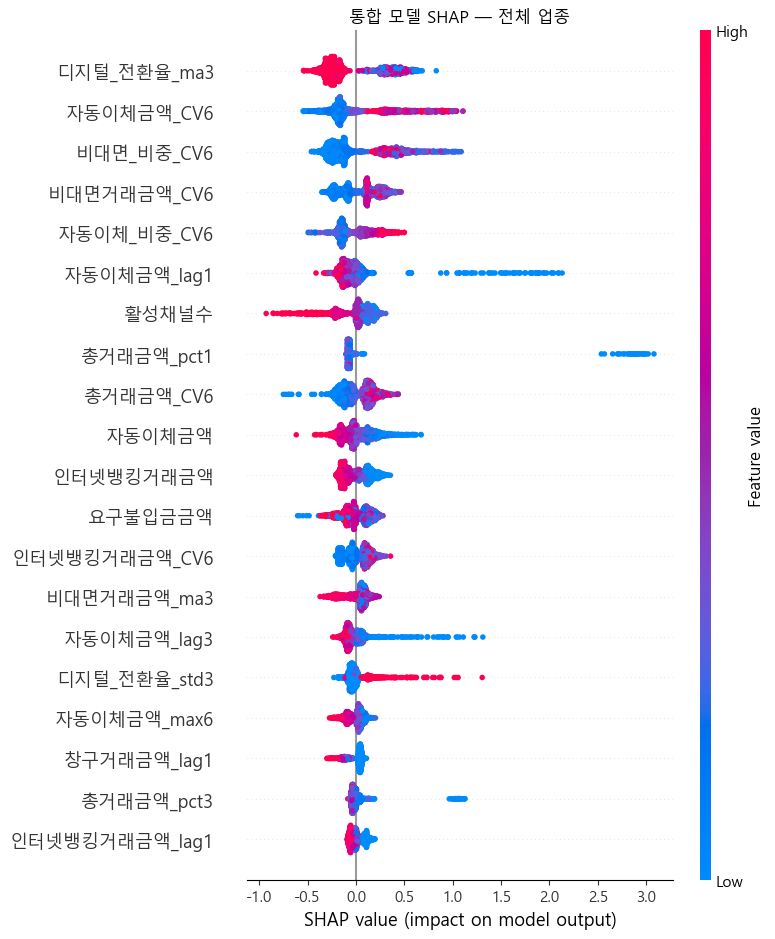

In [19]:
# ============================================================
# SHAP / Feature Importance
# ============================================================

# 업종별 Feature Importance Top 20은 SHAP 설치 여부와 무관하게 출력
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}] Feature Importance Top 20')
    display(info['feature_importance'].head(20))

# 통합 모델 SHAP은 shap 패키지가 있을 때만 실행
try:
    import shap

    prep = INT_PIPE.named_steps['prep']
    lgbm = INT_PIPE.named_steps['model']

    sample_n = min(1500, len(df_test))
    Xte_raw = df_test.sample(sample_n, random_state=RANDOM_STATE).copy()

    Xte_int = preprocess_for_model(
        Xte_raw,
        num_cols=list(INT_kept),
        cat_cols=list(INT_cat),
        bounds=INT_bounds,
        logset=INT_logset
    )[list(INT_kept) + list(INT_cat)]

    Xt_transformed = prep.transform(Xte_int)
    if hasattr(Xt_transformed, 'toarray'):
        Xt = Xt_transformed.toarray()
    else:
        Xt = np.asarray(Xt_transformed)

    ohe = prep.named_transformers_.get('cat') if 'cat' in prep.named_transformers_ else None
    feature_names = (list(ohe.get_feature_names_out(INT_cat)) if ohe is not None else []) + list(INT_kept)

    explainer = shap.TreeExplainer(lgbm)
    shap_values = explainer.shap_values(Xt)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(
        shap_values,
        Xt,
        feature_names=feature_names,
        show=False,
        max_display=20
    )
    plt.title('통합 모델 SHAP — 전체 업종')
    plt.tight_layout()
    plt.show()

    SHAP_INT = {
        'shap': shap_values,
        'X': Xt,
        'names': feature_names
    }

except Exception as e:
    print('SHAP 계산 스킵:', e)
    SHAP_INT = None

## 단계5 — 중요 변수 기반 EDA (y=0 vs y=1, df_model 기준 원본단위)

In [20]:
# 업종별 상위 중요 수치형 변수에 대해 y=0/1 비교 (clip/log 전 원본 dfx 기준)
EDA_ROWS = []

for ind, info in IND_MODELS.items():
    sub = dfx[dfx['업종_대분류'] == ind]

    # FI 상위 중 수치형 원본 변수만(one-hot 더미 제외), 누수 피처 제외
    top_num = [
        f for f in info['feature_importance']['feature']
        if f in NUM_FEAT_ALL and not is_forbidden_feature(f)
    ][:8]

    print(f'\n[{ind}] 주요 수치형 변수 y=0 vs y=1')

    for f in top_num:
        g0 = sub.loc[sub['y'] == 0, f]
        g1 = sub.loc[sub['y'] == 1, f]

        row = {
            '업종': ind,
            '변수': f,
            'y0_평균': round(g0.mean(), 2),
            'y1_평균': round(g1.mean(), 2),
            'y0_중앙': round(g0.median(), 2),
            'y1_중앙': round(g1.median(), 2),
            '차이': round(g1.mean() - g0.mean(), 2),
            '차이율': round((g1.mean() - g0.mean()) / (abs(g0.mean()) + 1e-9), 3)
        }
        EDA_ROWS.append(row)

    print(pd.DataFrame([r for r in EDA_ROWS if r['업종'] == ind]).to_string(index=False))

# high-zero categorical 변수의 y=1 비율 차이
print('\n[high-zero zero_cat 변수의 y=1 비율 (nonzero일 때)]')
for c in [c for c in high_zero_cat_cols if c in CAT_FEAT_ALL][:10]:
    nz = dfx[dfx[c] == 'nonzero']
    if len(nz) > 0:
        print(f'  {c}: nonzero일 때 y=1 비율 {nz["y"].mean()*100:.1f}% (전체 {dfx["y"].mean()*100:.1f}%)')


[제조업] 주요 수치형 변수 y=0 vs y=1
 업종           변수  y0_평균  y1_평균  y0_중앙  y1_중앙      차이    차이율
제조업   자동이체금액_CV6   0.24   0.46   0.16   0.41    0.22  0.933
제조업    총거래금액_CV6   0.38   0.71   0.30   0.60    0.32  0.838
제조업  자동이체_비중_CV6   0.37   0.59   0.32   0.54    0.21  0.567
제조업  요구불예금잔액_CV6   0.70   0.78   0.60   0.69    0.07  0.103
제조업       자동이체금액 236.50 114.12  26.00   6.40 -122.38 -0.517
제조업  요구불예금잔액_ma3 176.34  92.16  31.67   4.36  -84.18 -0.477
제조업 자동이체_비중_max6   0.36   0.61   0.25   0.71    0.25  0.702
제조업  디지털_전환율_CV6   0.18   0.63   0.00   0.49    0.45  2.526

[도매 및 소매업] 주요 수치형 변수 y=0 vs y=1
      업종           변수  y0_평균  y1_평균  y0_중앙  y1_중앙      차이    차이율
도매 및 소매업   자동이체금액_CV6   0.24   0.43   0.16   0.36    0.19  0.814
도매 및 소매업  자동이체_비중_CV6   0.34   0.55   0.28   0.50    0.21  0.608
도매 및 소매업  디지털_전환율_CV6   0.13   0.60   0.00   0.38    0.47  3.581
도매 및 소매업       자동이체금액 204.06  22.93  18.00   3.40 -181.13 -0.888
도매 및 소매업  요구불예금잔액_ma3 116.39  57.85  19.67   1.84  -58.53 -0.503
도매 및 소매업 

## 5-3. 출력물 정리

In [21]:
# # ============================================================
# # 출력물 정리
# # ============================================================

# print('=' * 70)
# print('15-1. 데이터 요약')
# print('=' * 70)
# print('NOTEBOOK_NAME       :', NOTEBOOK_NAME)
# print('전체 df shape       :', df.shape)
# if '보간여부' in df.columns:
#     print('보간 생성 row 수    :', int(df['보간여부'].sum()))
# if 'corp_profile' in globals():
#     print('누락검정 법인 수    :', corp_profile['법인ID'].nunique())
# print('df_model shape      :', df_model.shape)
# print('법인ID 수           :', df_model['법인ID'].nunique())
# print('기간                :', df['기준년월'].min(), '~', df['기준년월'].max())
# print('warm-up 행 수       :', (~df['y_available']).sum())
# print('y 분포              :', dict(df_model['y'].value_counts()))

# print('\n업종별 행 수')
# display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

# print('\n업종별 법인 수')
# display(dfx.groupby('업종_대분류')['법인ID'].nunique().sort_values(ascending=False).to_frame('corp_count'))

# print('\n' + '=' * 70)
# print('15-2. 0비율 처리 요약')
# print('=' * 70)
# print('100% 0 제거 변수 수        :', len(zero_100_cols))
# print('0비율 85%↑ zero_cat 변수 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
# print('zero_cat 컬럼              :', high_zero_cat_cols[:50])
# print('high-zero 원본 제거 컬럼    :', HIGH_ZERO_NUMERIC_DROP_COLS[:50])

# print('\n' + '=' * 70)
# print('15-3. 업종별 모델 성능')
# print('=' * 70)
# display(res_ind)

# print('\n' + '=' * 70)
# print('15-4. 통합/앙상블 성능')
# print('=' * 70)
# display(res_ens)

# print('\n' + '=' * 70)
# print('15-5. 업종별 Top Feature')
# print('=' * 70)
# for ind, info in IND_MODELS.items():
#     print(f'\n[{ind}]')
#     display(info['feature_importance'].head(10))

# print('\n' + '=' * 70)
# print('15-6. EDA 요약')
# print('=' * 70)

# if EDA_ROWS:
#     eda_df = pd.DataFrame(EDA_ROWS).reindex(columns=[
#         '업종', '변수',
#         'y0_평균', 'y1_평균',
#         'y0_중앙', 'y1_중앙',
#         '차이', '차이율'
#     ])
#     display(eda_df)
# else:
#     eda_df = pd.DataFrame()
#     print('EDA_ROWS가 비어 있습니다.')

# # 결과 저장
# res_ind_path = f'{NOTEBOOK_NAME}_업종별성능.csv'
# res_ens_path = f'{NOTEBOOK_NAME}_앙상블성능.csv'
# eda_path = f'{NOTEBOOK_NAME}_eda요약.csv'

# res_ind.to_csv(res_ind_path, index=False, encoding='utf-8-sig')
# res_ens.to_csv(res_ens_path, index=False, encoding='utf-8-sig')
# eda_df.to_csv(eda_path, index=False, encoding='utf-8-sig')

# print('\n저장 완료:')
# print(' -', res_ind_path)
# print(' -', res_ens_path)
# print(' -', eda_path)

# 페르소나 정리

## 1. SHAP 기반 법인ID 벡터 생성

In [22]:
# ============================================================
# 1. final11 통합모델 SHAP 기반 법인ID 벡터 생성
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

import shap

RANDOM_STATE = 42

# ------------------------------------------------------------
# 설정값
# ------------------------------------------------------------

ID_COL = '법인ID'
DATE_COL = '기준년월'
Y_COL = 'y'
IND_COL = '업종_대분류'

# SHAP 계산 대상
# final11에서 dfx가 있으면 top4 업종 모델링 데이터 기준
# 없으면 df_model 사용
PERSONA_DF = dfx.copy() if 'dfx' in globals() else df_model.copy()

# 너무 느리면 법인별 일부 월만 샘플링
# None이면 전체 사용
SHAP_MAX_ROWS_PER_CORP = None
# 예: 너무 느리면 12로 바꿔도 됨
# SHAP_MAX_ROWS_PER_CORP = 12

# 클러스터링에 사용할 SHAP 상위 변수 수
TOP_N_SHAP_FEATURES = 40

print('[PERSONA_DF]')
print('shape:', PERSONA_DF.shape)
print('법인 수:', PERSONA_DF[ID_COL].nunique())
print('기간:', PERSONA_DF[DATE_COL].min(), '~', PERSONA_DF[DATE_COL].max())
print('y 비율:', PERSONA_DF[Y_COL].mean())


# ------------------------------------------------------------
# final11 통합모델용 전처리 함수
# ------------------------------------------------------------

def preprocess_for_model_local(d, num_cols, cat_cols, bounds, logset):
    d = d.copy()

    missing_num = [c for c in num_cols if c not in d.columns]
    missing_cat = [c for c in cat_cols if c not in d.columns]

    if len(missing_num) > 0:
        raise ValueError(f'누락된 numeric feature: {missing_num[:20]}')

    if len(missing_cat) > 0:
        raise ValueError(f'누락된 categorical feature: {missing_cat[:20]}')

    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        dp[c] = dp[c].astype(str).fillna('missing')

    return dp


# ------------------------------------------------------------
# SHAP 계산용 row 샘플링
# ------------------------------------------------------------

if SHAP_MAX_ROWS_PER_CORP is not None:
    shap_df = (
        PERSONA_DF
        .sort_values([ID_COL, DATE_COL])
        .groupby(ID_COL, group_keys=False)
        .apply(lambda g: g.tail(SHAP_MAX_ROWS_PER_CORP))
        .reset_index(drop=True)
    )
else:
    shap_df = PERSONA_DF.copy().reset_index(drop=True)

print('\n[SHAP 계산 대상]')
print('shape:', shap_df.shape)
print('법인 수:', shap_df[ID_COL].nunique())


# ------------------------------------------------------------
# 통합모델 전처리 + transform
# ------------------------------------------------------------

INT_features = list(INT_kept) + list(INT_cat)

shap_dp = preprocess_for_model_local(
    shap_df,
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

prep = INT_PIPE.named_steps['prep']
model = INT_PIPE.named_steps['model']

X_trans = prep.transform(shap_dp[INT_features])

try:
    feature_names = prep.get_feature_names_out()
except:
    feature_names = None

if sparse.issparse(X_trans):
    X_shap = X_trans.toarray()
else:
    X_shap = np.asarray(X_trans)

if feature_names is None:
    feature_names = [f'f_{i}' for i in range(X_shap.shape[1])]
else:
    feature_names = list(feature_names)

assert X_shap.shape[1] == len(feature_names), 'SHAP feature name 길이가 transform 결과와 다릅니다.'

print('\n[Transformed X]')
print('X_shap shape:', X_shap.shape)
print('feature name 수:', len(feature_names))


# ------------------------------------------------------------
# SHAP 계산
# ------------------------------------------------------------

explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_shap)

# binary classification 처리
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

# 혹시 3차원으로 나오는 버전 대응
if len(np.asarray(shap_values).shape) == 3:
    shap_values = np.asarray(shap_values)[:, :, 1]

shap_values = np.asarray(shap_values)

print('\n[SHAP]')
print('shap_values shape:', shap_values.shape)


# ------------------------------------------------------------
# OneHot SHAP을 원래 변수명 기준으로 묶기
# ------------------------------------------------------------

def map_transformed_feature_to_base_feature(fname, num_cols, cat_cols):
    """
    ColumnTransformer feature name을 원래 변수명으로 매핑.
    예:
    num__요구불예금잔액 -> 요구불예금잔액
    cat__업종_대분류_제조업 -> 업종_대분류
    """
    fname = str(fname)

    # ColumnTransformer prefix 제거
    if '__' in fname:
        _, rest = fname.split('__', 1)
    else:
        rest = fname

    # 수치형이면 그대로
    if rest in num_cols:
        return rest

    # 범주형 one-hot이면 원래 범주형 컬럼명으로 매핑
    # 업종_대분류처럼 컬럼명에 '_'가 있으므로 길이 긴 컬럼부터 매칭
    for c in sorted(cat_cols, key=len, reverse=True):
        if rest == c or rest.startswith(c + '_'):
            return c

    return rest


base_feature_map = [
    map_transformed_feature_to_base_feature(
        f,
        num_cols=list(INT_kept),
        cat_cols=list(INT_cat)
    )
    for f in feature_names
]

shap_raw_df = pd.DataFrame(shap_values, columns=feature_names)

# 원래 변수명 기준으로 SHAP 합산
shap_grouped_df = (
    shap_raw_df
    .T
    .groupby(base_feature_map)
    .sum()
    .T
)

shap_grouped_df[ID_COL] = shap_df[ID_COL].values
shap_grouped_df[DATE_COL] = shap_df[DATE_COL].values

print('\n[Grouped SHAP]')
print('shape:', shap_grouped_df.shape)
display(shap_grouped_df.head())


# ------------------------------------------------------------
# 법인ID 단위 SHAP 벡터화
# ------------------------------------------------------------

shap_feature_cols = [
    c for c in shap_grouped_df.columns
    if c not in [ID_COL, DATE_COL]
]

corp_shap_vector = (
    shap_grouped_df
    .groupby(ID_COL)[shap_feature_cols]
    .mean()
    .reset_index()
)

# 전체 평균 절대 SHAP 기준 top feature 선택
mean_abs_shap = (
    corp_shap_vector[shap_feature_cols]
    .abs()
    .mean()
    .sort_values(ascending=False)
)

top_shap_features = mean_abs_shap.head(TOP_N_SHAP_FEATURES).index.tolist()

print('\n[클러스터링 사용 SHAP 변수]')
print('사용 변수 수:', len(top_shap_features))
display(mean_abs_shap.head(30).reset_index().rename(columns={'index': 'feature', 0: 'mean_abs_shap'}))

X_persona = corp_shap_vector[top_shap_features].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler_persona = StandardScaler()
X_persona_scaled = scaler_persona.fit_transform(X_persona)

print('\n[법인ID SHAP 벡터]')
print('corp_shap_vector:', corp_shap_vector.shape)
print('X_persona_scaled:', X_persona_scaled.shape)

[PERSONA_DF]
shape: (130703, 555)
법인 수: 4507
기간: 202307 ~ 202511
y 비율: 0.3912228487486898

[SHAP 계산 대상]
shape: (130703, 555)
법인 수: 4507

[Transformed X]
X_shap shape: (130703, 460)
feature name 수: 460

[SHAP]
shap_values shape: (130703, 460)

[Grouped SHAP]
shape: (130703, 324)


,ATM거래금액,region_unknown_flag_zero_cat,거치식예금잔액_CV6_zero_cat,거치식예금잔액_accel_zero_cat,거치식예금잔액_diff1_zero_cat,거치식예금잔액_diff3_zero_cat,거치식예금잔액_lag1_zero_cat,거치식예금잔액_lag3,거치식예금잔액_lag6,거치식예금잔액_ma3_zero_cat,...,카드_비중_pct3,카드_비중_peak_ratio,카드_비중_std3,카드사용여부,퇴직연금좌수_num,폰뱅킹거래금액_zero_cat,행동복합감소점수,활성채널수,법인ID,기준년월
0,-0.004224,0.0,0.000058,-0.000041,-0.000011,0.000187,-0.000212,-0.007073,0.015776,0.000126,...,0.000157,0.036039,-0.009840,0.0,-0.072809,-0.000221,0.004005,0.258407,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,202307
1,-0.000794,0.0,0.000126,-0.000041,-0.000011,0.000187,0.001143,-0.006796,0.015736,0.000126,...,0.000171,0.035157,-0.013210,0.0,-0.072297,-0.000258,-0.001355,0.231976,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,202308
2,-0.000647,0.0,-0.000435,0.001219,0.001903,0.000093,0.000181,-0.003084,0.000307,0.000161,...,-0.003366,-0.002232,0.032920,0.0,-0.051258,-0.000328,0.001395,0.125612,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,202309
3,0.001881,0.0,0.000008,0.000761,0.000002,-0.027905,0.000004,0.031409,-0.003822,0.000135,...,-0.000730,0.002029,0.020700,0.0,-0.041383,-0.000293,-0.003249,0.048334,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,202310
4,0.001283,0.0,-0.000250,-0.000029,0.000010,-0.028363,0.000004,0.035605,-0.010236,-0.000085,...,0.004626,0.009496,0.021741,0.0,-0.041273,-0.000359,-0.001374,0.042965,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,202311



[클러스터링 사용 SHAP 변수]
사용 변수 수: 40


,feature,mean_abs_shap
0,디지털_전환율_ma3,0.228925
1,비대면_비중_CV6,0.193451
2,자동이체금액_CV6,0.166457
3,활성채널수,0.134821
4,비대면거래금액_CV6,0.116766
5,인터넷뱅킹거래금액,0.106966
6,자동이체금액,0.106251
7,자동이체_비중_CV6,0.098557
8,요구불입금금액,0.094318
9,총거래금액_pct1,0.092018



[법인ID SHAP 벡터]
corp_shap_vector: (4507, 323)
X_persona_scaled: (4507, 40)


## 2. k 후보별 엘보우 / 실루엣 / 지표 확인

[k 후보별 평가]


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size,cluster_size_ratio
0,2,144368.415337,0.187312,1120.616920,1.890117,1887,2620,1.388
1,3,131962.239691,0.126614,824.566152,2.239089,1306,1841,1.410
2,4,123499.361535,0.129858,690.106712,2.075457,461,1771,3.842
3,5,117318.309785,0.121181,604.026622,2.182641,448,1622,3.621
4,6,112939.997179,0.106584,536.740500,2.292610,399,1044,2.617
5,7,109542.822220,0.100324,484.311818,2.230701,172,977,5.680
6,8,106399.289849,0.103951,446.282940,2.160144,117,948,8.103
7,9,103829.727512,0.095753,413.987674,2.166171,122,807,6.615
8,10,101339.512502,0.098818,389.228795,2.116633,113,823,7.283


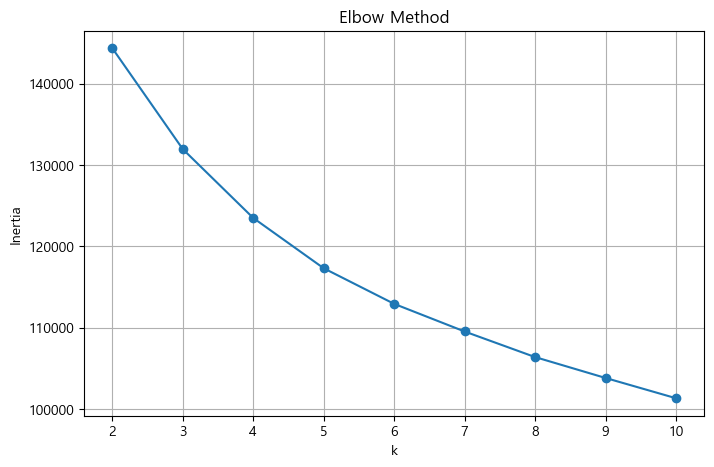

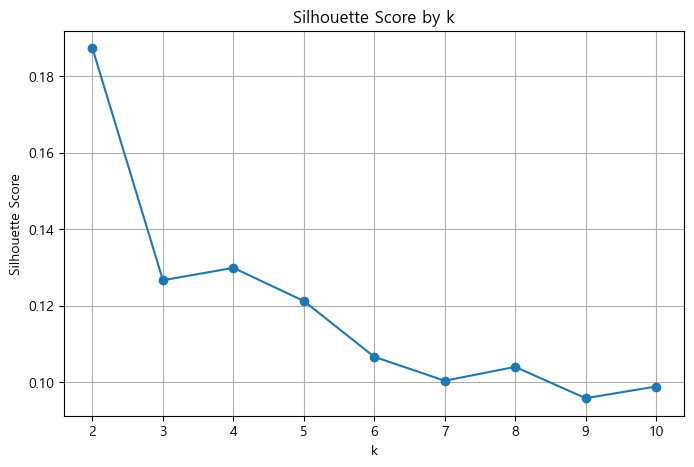

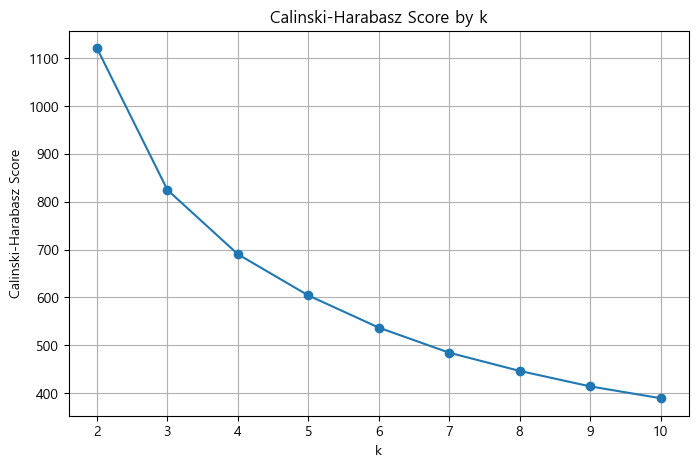

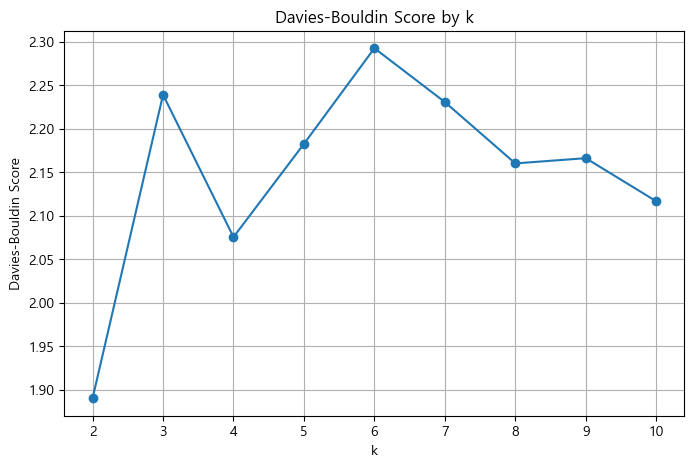

In [23]:
# ============================================================
# 2. KMeans k 후보별 평가
# - 엘보우: inertia
# - 실루엣: silhouette
# - 보조지표: Calinski-Harabasz, Davies-Bouldin
# ============================================================

K_RANGE = range(2, 11)

k_eval_rows = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=30
    )

    labels = km.fit_predict(X_persona_scaled)

    cluster_counts = pd.Series(labels).value_counts().sort_index()

    inertia = km.inertia_
    sil = silhouette_score(X_persona_scaled, labels)
    ch = calinski_harabasz_score(X_persona_scaled, labels)
    db = davies_bouldin_score(X_persona_scaled, labels)

    k_eval_rows.append({
        'k': k,
        'inertia': inertia,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
        'min_cluster_size': int(cluster_counts.min()),
        'max_cluster_size': int(cluster_counts.max()),
        'cluster_size_ratio': round(cluster_counts.max() / cluster_counts.min(), 3)
    })

k_eval_df = pd.DataFrame(k_eval_rows)

print('[k 후보별 평가]')
display(k_eval_df)


# ------------------------------------------------------------
# Elbow plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(k_eval_df['k'], k_eval_df['inertia'], marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# Silhouette plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(k_eval_df['k'], k_eval_df['silhouette'], marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 보조지표 plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(k_eval_df['k'], k_eval_df['calinski_harabasz'], marker='o')
plt.xlabel('k')
plt.ylabel('Calinski-Harabasz Score')
plt.title('Calinski-Harabasz Score by k')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_eval_df['k'], k_eval_df['davies_bouldin'], marker='o')
plt.xlabel('k')
plt.ylabel('Davies-Bouldin Score')
plt.title('Davies-Bouldin Score by k')
plt.grid(True)
plt.show()

## 3. PCA 2차원으로 k별 군집 모양 확인

PCA explained variance ratio: [0.27609664 0.1008983 ]
PCA 누적 설명력: 0.3769949333549533


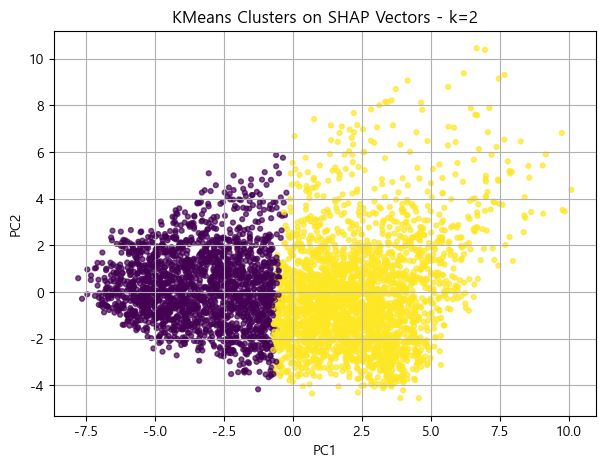

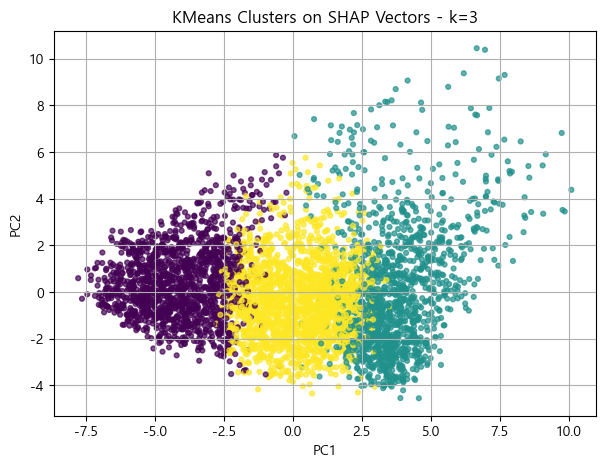

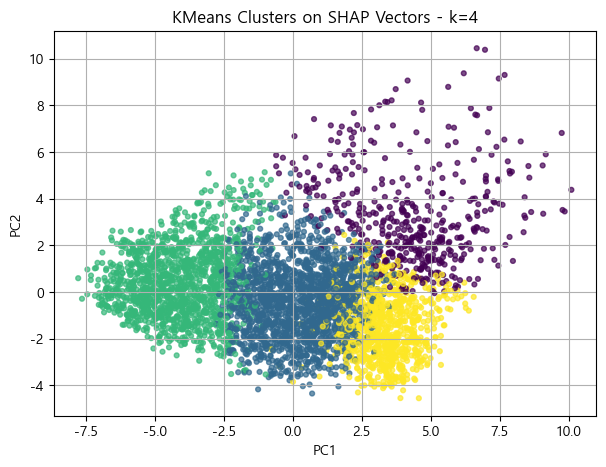

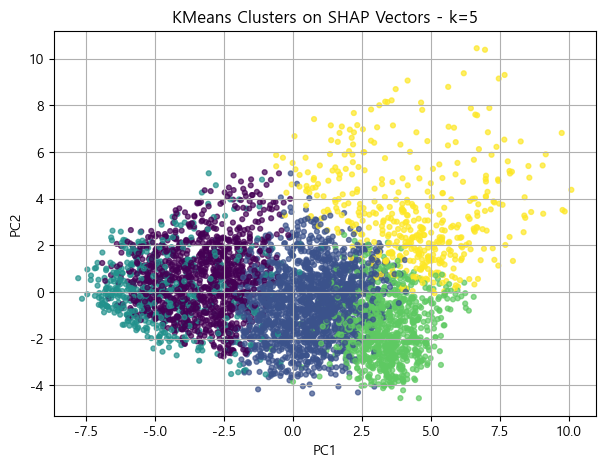

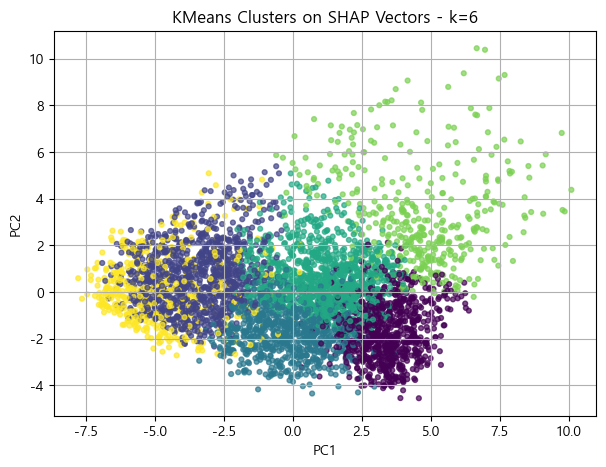

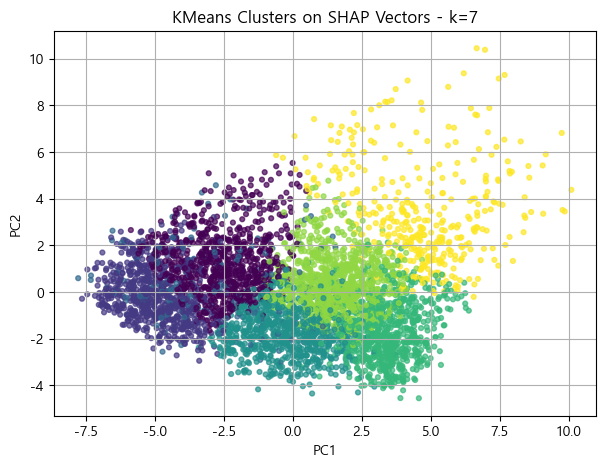

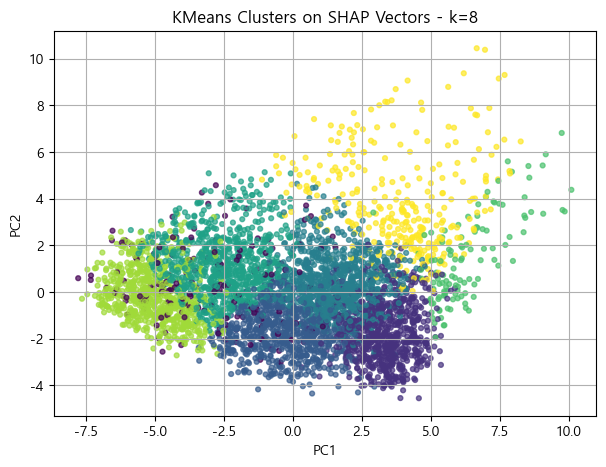

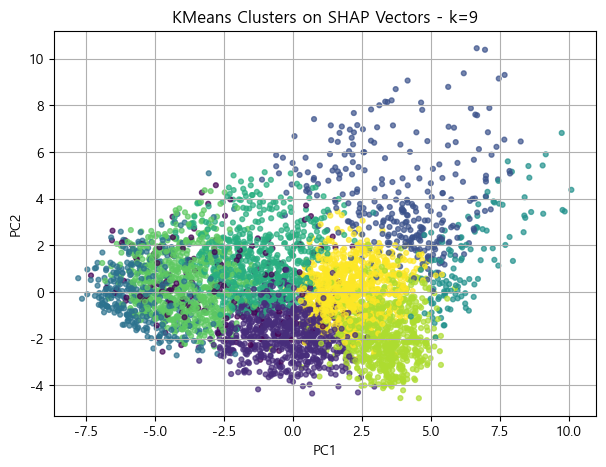

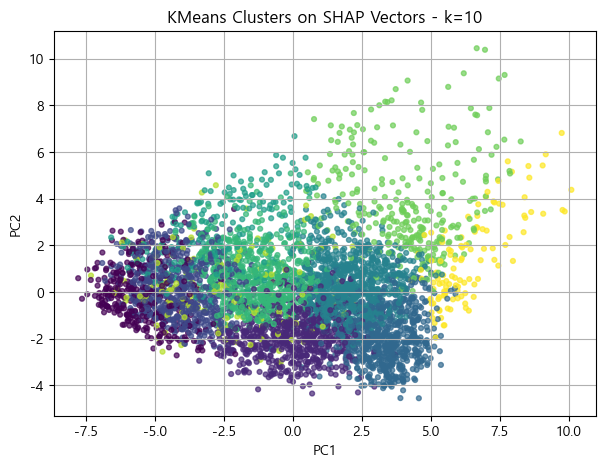

In [24]:
# ============================================================
# 3. PCA 2D 시각화로 k별 군집 모양 확인
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_persona_scaled)

print('PCA explained variance ratio:', pca.explained_variance_ratio_)
print('PCA 누적 설명력:', pca.explained_variance_ratio_.sum())

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=30
    )
    labels = km.fit_predict(X_persona_scaled)

    plt.figure(figsize=(7, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=12, alpha=0.7)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'KMeans Clusters on SHAP Vectors - k={k}')
    plt.grid(True)
    plt.show()

## 4. k 선택 후 최종 클러스터링

In [25]:
# ============================================================
# 4. 최종 k 선택 후 클러스터링
# ============================================================

# 여기만 바꿔서 실행
FINAL_K = 4

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=50
)

cluster_labels = final_kmeans.fit_predict(X_persona_scaled)

cluster_result = corp_shap_vector[[ID_COL]].copy()
cluster_result['cluster'] = cluster_labels

print('[최종 클러스터 분포]')
display(cluster_result['cluster'].value_counts().sort_index().reset_index().rename(
    columns={'index': 'cluster', 'cluster': 'count'}
))

cluster_result.head()

[최종 클러스터 분포]


,count,count
0,0,909
1,1,1767
2,2,1354
3,3,477


,법인ID,cluster
0,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,1
1,003c33dcf7856f7037b627ba17c959cbd74e07d1255d12...,0
2,003d5d6feb335b229b1fea54ba309701754f8d2cee2d7b...,1
3,0049899d0fdac0ff0724b8b9e1a38dd4296834622a356d...,2
4,006d592b8fa183c207c37c4d50d6d01d8cdfdbf1a06984...,3


## 5. 클러스터 해석용 데이터 붙이기

In [26]:
# ============================================================
# 5. 클러스터 해석용 정보 결합 - 메모리 절약 버전
# - PERSONA_DF 전체 copy 금지
# - 필요한 meta 컬럼만 복사
# - 예측은 원본 PERSONA_DF를 chunk 단위로 슬라이싱
# ============================================================

import gc
import numpy as np
import pandas as pd

BATCH_SIZE = 2000


# ------------------------------------------------------------
# 0. SHAP 계산에서 남은 큰 객체 메모리 정리
# ------------------------------------------------------------

for obj_name in [
    'X_trans', 'X_shap', 'shap_values_raw', 'shap_values',
    'shap_raw_df', 'shap_grouped_df'
]:
    if obj_name in globals():
        try:
            del globals()[obj_name]
        except:
            pass

gc.collect()


# ------------------------------------------------------------
# 1. 전처리 함수
# ------------------------------------------------------------

def preprocess_for_model_light(d, num_cols, cat_cols, bounds, logset):
    """
    chunk 단위 전처리.
    d는 이미 필요한 컬럼만 가진 작은 chunk로 들어온다고 가정.
    """
    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        if c in dp.columns:
            dp[c] = dp[c].astype(str).fillna('missing')

    return dp


# ------------------------------------------------------------
# 2. 통합모델 batch predict
# ------------------------------------------------------------

def predict_int_batch_from_source(source_df, batch_size=2000):
    """
    PERSONA_DF 전체를 복사하지 않고,
    필요한 컬럼만 chunk로 잘라서 통합모델 예측.
    """
    n = len(source_df)

    num_cols = list(INT_kept)
    cat_cols = list(INT_cat)
    feat = num_cols + cat_cols

    out = np.zeros(n, dtype=np.float32)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        # 여기서 필요한 컬럼만 잘라옴
        chunk = source_df.iloc[start:end][feat]

        dp = preprocess_for_model_light(
            chunk,
            num_cols=num_cols,
            cat_cols=cat_cols,
            bounds=INT_bounds,
            logset=INT_logset
        )

        out[start:end] = INT_PIPE.predict_proba(dp[feat])[:, 1].astype(np.float32)

        del chunk, dp
        gc.collect()

    return out


# ------------------------------------------------------------
# 3. 업종라우팅 batch predict
# ------------------------------------------------------------

def routed_predict_batch_from_source(source_df, batch_size=2000):
    """
    PERSONA_DF 전체 복사 없이 업종별 모델 batch 예측.
    """
    n = len(source_df)
    arr = np.full(n, np.nan, dtype=np.float32)

    # 업종_대분류만 별도 Series로 참조
    industry_series = source_df['업종_대분류']

    for ind, info in IND_MODELS.items():
        idx = np.where((industry_series == ind).values)[0]

        if len(idx) == 0:
            continue

        num_cols = list(info['num_features'])
        cat_cols = list(info['cat_features'])
        feat = num_cols + cat_cols

        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start + batch_size]

            # 필요한 feature만 잘라옴
            chunk = source_df.iloc[batch_idx][feat]

            dp = preprocess_for_model_light(
                chunk,
                num_cols=num_cols,
                cat_cols=cat_cols,
                bounds=info['clip_bounds'],
                logset=info['log_set']
            )

            arr[batch_idx] = info['pipeline'].predict_proba(dp[feat])[:, 1].astype(np.float32)

            del chunk, dp
            gc.collect()

    return arr


# 아래쪽 코드 호환용
routed_predict = routed_predict_batch_from_source


# ------------------------------------------------------------
# 4. 필요한 meta 컬럼만 작은 dataframe으로 생성
# ------------------------------------------------------------

meta_cols = [
    ID_COL,
    DATE_COL,
    Y_COL,
    '업종_대분류',
    '업종_중분류',
    '사업장_시도',
    'impute_target_corp',
    '보간여부'
]

meta_cols = [c for c in meta_cols if c in PERSONA_DF.columns]

# 전체 copy 금지. 필요한 컬럼만 복사.
persona_meta_df = PERSONA_DF.loc[:, meta_cols].reset_index(drop=True).copy()

print('[persona_meta_df]')
print('shape:', persona_meta_df.shape)
print('법인 수:', persona_meta_df[ID_COL].nunique())
print('기간:', persona_meta_df[DATE_COL].min(), '~', persona_meta_df[DATE_COL].max())


# ------------------------------------------------------------
# 5. final11 블렌딩 위험도 계산
# ------------------------------------------------------------

print('\n[통합모델 score 계산 - batch]')
persona_int_score = predict_int_batch_from_source(
    PERSONA_DF,
    batch_size=BATCH_SIZE
)
print('통합 score 계산 완료')


print('\n[업종라우팅 score 계산 - batch]')
persona_routed_score = routed_predict_batch_from_source(
    PERSONA_DF,
    batch_size=BATCH_SIZE
)

nanm = np.isnan(persona_routed_score)
persona_routed_score[nanm] = persona_int_score[nanm]

print('라우팅 score 계산 완료')
print('라우팅 NaN 대체 수:', int(nanm.sum()))


persona_blend_score = 0.5 * persona_routed_score + 0.5 * persona_int_score

# score는 작은 meta df에만 붙임
persona_meta_df['int_score'] = persona_int_score
persona_meta_df['routed_score'] = persona_routed_score
persona_meta_df['blend_score'] = persona_blend_score

print('\n[score 분포]')
display(persona_meta_df[['int_score', 'routed_score', 'blend_score']].describe())


# ------------------------------------------------------------
# 6. 법인ID별 요약 변수
# ------------------------------------------------------------

def mode_or_nan(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]


def recent_mean(g, col, n=3):
    g = g.sort_values(DATE_COL).tail(n)
    if len(g) == 0:
        return np.nan
    return g[col].mean()


def safe_col(g, col, func, default=np.nan):
    if col not in g.columns:
        return default
    return func(g[col])


corp_profile = (
    persona_meta_df
    .groupby(ID_COL)
    .apply(lambda g: pd.Series({
        '업종_대분류': mode_or_nan(g['업종_대분류']) if '업종_대분류' in g.columns else np.nan,
        '업종_중분류': mode_or_nan(g['업종_중분류']) if '업종_중분류' in g.columns else np.nan,
        '사업장_시도': mode_or_nan(g['사업장_시도']) if '사업장_시도' in g.columns else np.nan,
        'n_months': len(g),
        'y_rate': g[Y_COL].mean() if Y_COL in g.columns else np.nan,
        'risk_months': g[Y_COL].sum() if Y_COL in g.columns else np.nan,
        'blend_score_mean': g['blend_score'].mean(),
        'blend_score_recent3': recent_mean(g, 'blend_score', n=3),
        'blend_score_recent6': recent_mean(g, 'blend_score', n=6),
        'int_score_mean': g['int_score'].mean(),
        'routed_score_mean': g['routed_score'].mean(),
        'impute_target_corp': g['impute_target_corp'].max() if 'impute_target_corp' in g.columns else np.nan,
        '보간행비율': g['보간여부'].mean() if '보간여부' in g.columns else np.nan
    }))
    .reset_index()
)

persona_base = (
    cluster_result
    .merge(corp_profile, on=ID_COL, how='left')
)

print('\n[persona_base]')
display(persona_base.head())
display(persona_base['cluster'].value_counts().sort_index())


# ------------------------------------------------------------
# 7. 메모리 정리
# ------------------------------------------------------------

del persona_int_score, persona_routed_score, persona_blend_score
gc.collect()

[persona_meta_df]
shape: (130703, 7)
법인 수: 4507
기간: 202307 ~ 202511

[통합모델 score 계산 - batch]
통합 score 계산 완료

[업종라우팅 score 계산 - batch]
라우팅 score 계산 완료
라우팅 NaN 대체 수: 0

[score 분포]


,int_score,routed_score,blend_score
count,130703.000000,130703.000000,130703.000000
mean,0.443378,0.427771,0.435575
std,0.337300,0.364862,0.346044
min,0.001276,0.000121,0.000914
25%,0.103179,0.067680,0.090492
50%,0.410900,0.326857,0.374856
75%,0.754907,0.809684,0.774117
max,0.999951,0.999944,0.999921



[persona_base]


,법인ID,cluster,업종_대분류,업종_중분류,사업장_시도,n_months,y_rate,risk_months,blend_score_mean,blend_score_recent3,blend_score_recent6,int_score_mean,routed_score_mean,impute_target_corp,보간행비율
0,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,1,건설업,전문직별 공사업,경북,29,0.793103,23,0.762103,0.787069,0.796787,0.717701,0.806505,NaN,0.000000
1,003c33dcf7856f7037b627ba17c959cbd74e07d1255d12...,0,도매 및 소매업,도매 및 상품 중개업,경북,29,0.448276,13,0.651013,0.728505,0.696488,0.655785,0.646241,NaN,0.000000
2,003d5d6feb335b229b1fea54ba309701754f8d2cee2d7b...,1,제조업,기타 기계 및 장비 제조업,경북,29,0.206897,6,0.194969,0.426777,0.250032,0.230452,0.159485,NaN,0.034483
3,0049899d0fdac0ff0724b8b9e1a38dd4296834622a356d...,2,제조업,고무 및 플라스틱제품 제조업,경북,29,0.103448,3,0.056094,0.109545,0.113514,0.068216,0.043971,NaN,0.000000
4,006d592b8fa183c207c37c4d50d6d01d8cdfdbf1a06984...,3,제조업,식료품 제조업,경북,29,0.896552,26,0.811565,0.879886,0.932554,0.803395,0.819734,NaN,0.068966


cluster
0     909
1    1767
2    1354
3     477
Name: count, dtype: int64

0

## 6. 클러스터별 요약표

In [27]:
# ============================================================
# 6. 클러스터별 요약표
# ============================================================

persona_summary = (
    persona_base
    .groupby('cluster')
    .agg(
        corp_count=(ID_COL, 'nunique'),
        y_rate_mean=('y_rate', 'mean'),
        risk_months_mean=('risk_months', 'mean'),
        blend_score_mean=('blend_score_mean', 'mean'),
        blend_score_recent3_mean=('blend_score_recent3', 'mean'),
        blend_score_recent6_mean=('blend_score_recent6', 'mean'),
        int_score_mean=('int_score_mean', 'mean'),
        routed_score_mean=('routed_score_mean', 'mean'),
        impute_target_rate=('impute_target_corp', 'mean'),
        imputed_row_rate_mean=('보간행비율', 'mean')
    )
    .reset_index()
    .sort_values('blend_score_mean', ascending=False)
)

print('[클러스터별 위험도 요약]')
display(persona_summary)


# ------------------------------------------------------------
# 클러스터별 업종 분포
# ------------------------------------------------------------

print('[클러스터별 업종 대분류 분포 - count]')
cluster_ind_count = pd.crosstab(persona_base['cluster'], persona_base['업종_대분류'])
display(cluster_ind_count)

print('[클러스터별 업종 대분류 분포 - row ratio]')
cluster_ind_rate = pd.crosstab(persona_base['cluster'], persona_base['업종_대분류'], normalize='index')
display(cluster_ind_rate)


# ------------------------------------------------------------
# 클러스터별 지역 분포
# ------------------------------------------------------------

if '사업장_시도' in persona_base.columns:
    print('[클러스터별 지역 분포 - row ratio]')
    cluster_region_rate = pd.crosstab(persona_base['cluster'], persona_base['사업장_시도'], normalize='index')
    display(cluster_region_rate)

[클러스터별 위험도 요약]


,cluster,corp_count,y_rate_mean,risk_months_mean,blend_score_mean,blend_score_recent3_mean,blend_score_recent6_mean,int_score_mean,routed_score_mean,impute_target_rate,imputed_row_rate_mean
3,3,477,0.807056,23.404612,0.805890,0.805845,0.812193,0.804397,0.807383,NaN,0.135762
0,0,909,0.675885,19.600660,0.733123,0.736876,0.739834,0.741804,0.724442,NaN,0.019878
1,1,1767,0.370119,10.733447,0.428687,0.433108,0.435613,0.440635,0.416738,NaN,0.013426
2,2,1354,0.081164,2.353767,0.114348,0.119817,0.115017,0.119427,0.109269,NaN,0.008837


[클러스터별 업종 대분류 분포 - count]


업종_대분류,건설업,도매 및 소매업,부동산업,제조업
cluster,,,,
0,160,216,183,350
1,459,333,242,733
2,247,463,16,628
3,82,93,70,232


[클러스터별 업종 대분류 분포 - row ratio]


업종_대분류,건설업,도매 및 소매업,부동산업,제조업
cluster,,,,
0,0.176018,0.237624,0.201320,0.385039
1,0.259762,0.188455,0.136955,0.414827
2,0.182422,0.341950,0.011817,0.463811
3,0.171908,0.194969,0.146751,0.486373


[클러스터별 지역 분포 - row ratio]


사업장_시도,Unknown,경북,기타,대구,부울경,수도권
cluster,,,,,,
0,0.039604,0.316832,0.030803,0.319032,0.127613,0.166117
1,0.048104,0.353707,0.007357,0.469157,0.076401,0.045274
2,0.039143,0.406942,0.004431,0.491876,0.038405,0.019202
3,0.035639,0.341719,0.012579,0.398323,0.104822,0.106918


## 7. 클러스터별 SHAP 특징 추출

In [28]:
# ============================================================
# 7. 클러스터별 SHAP 특징 추출
# - 해당 클러스터가 어떤 변수 영향으로 구분되는지 확인
# ============================================================

corp_shap_with_cluster = (
    corp_shap_vector
    .merge(cluster_result, on=ID_COL, how='left')
)

shap_cols_for_profile = [
    c for c in corp_shap_with_cluster.columns
    if c not in [ID_COL, 'cluster']
]

global_mean_shap = corp_shap_with_cluster[shap_cols_for_profile].mean()

cluster_shap_mean = (
    corp_shap_with_cluster
    .groupby('cluster')[shap_cols_for_profile]
    .mean()
)

# 전체 평균 대비 클러스터 SHAP 차이
cluster_shap_diff = cluster_shap_mean - global_mean_shap

rows = []

TOP_N_PER_CLUSTER = 10

for cl in sorted(corp_shap_with_cluster['cluster'].unique()):
    s = cluster_shap_diff.loc[cl].sort_values(ascending=False)
    pos_top = s.head(TOP_N_PER_CLUSTER)
    neg_top = s.tail(TOP_N_PER_CLUSTER).sort_values()

    for feat, val in pos_top.items():
        rows.append({
            'cluster': cl,
            'direction': '위험도 상승 방향 SHAP 상대적으로 큼',
            'feature': feat,
            'cluster_minus_global_shap': val
        })

    for feat, val in neg_top.items():
        rows.append({
            'cluster': cl,
            'direction': '위험도 하락 방향 SHAP 상대적으로 큼',
            'feature': feat,
            'cluster_minus_global_shap': val
        })

cluster_shap_profile = pd.DataFrame(rows)

print('[클러스터별 SHAP 특징]')
display(cluster_shap_profile)


# 보기 좋게 클러스터별 top positive만
print('[클러스터별 위험도 상승 방향 Top SHAP]')
display(
    cluster_shap_profile
    .query("direction == '위험도 상승 방향 SHAP 상대적으로 큼'")
    .sort_values(['cluster', 'cluster_minus_global_shap'], ascending=[True, False])
)

[클러스터별 SHAP 특징]


,cluster,direction,feature,cluster_minus_global_shap
0,0,위험도 상승 방향 SHAP 상대적으로 큼,디지털_전환율_ma3,0.345712
1,0,위험도 상승 방향 SHAP 상대적으로 큼,비대면_비중_CV6,0.156561
2,0,위험도 상승 방향 SHAP 상대적으로 큼,인터넷뱅킹거래금액,0.153846
3,0,위험도 상승 방향 SHAP 상대적으로 큼,활성채널수,0.135440
4,0,위험도 상승 방향 SHAP 상대적으로 큼,자동이체금액,0.098156
...,...,...,...,...
75,3,위험도 하락 방향 SHAP 상대적으로 큼,창구거래금액_diff1,-0.001330
76,3,위험도 하락 방향 SHAP 상대적으로 큼,인터넷뱅킹거래금액_pct1,-0.001283
77,3,위험도 하락 방향 SHAP 상대적으로 큼,비대면_비중_diff1,-0.001084
78,3,위험도 하락 방향 SHAP 상대적으로 큼,총외환실적_lag3,-0.001077


[클러스터별 위험도 상승 방향 Top SHAP]


,cluster,direction,feature,cluster_minus_global_shap
0,0,위험도 상승 방향 SHAP 상대적으로 큼,디지털_전환율_ma3,0.345712
1,0,위험도 상승 방향 SHAP 상대적으로 큼,비대면_비중_CV6,0.156561
2,0,위험도 상승 방향 SHAP 상대적으로 큼,인터넷뱅킹거래금액,0.153846
3,0,위험도 상승 방향 SHAP 상대적으로 큼,활성채널수,0.135440
4,0,위험도 상승 방향 SHAP 상대적으로 큼,자동이체금액,0.098156
5,0,위험도 상승 방향 SHAP 상대적으로 큼,요구불입금금액,0.082946
6,0,위험도 상승 방향 SHAP 상대적으로 큼,인터넷뱅킹거래금액_lag1,0.070636
7,0,위험도 상승 방향 SHAP 상대적으로 큼,비대면거래금액_ma3,0.053110
8,0,위험도 상승 방향 SHAP 상대적으로 큼,자동이체금액_max6,0.050571
9,0,위험도 상승 방향 SHAP 상대적으로 큼,비대면거래금액_peak_ratio,0.046424


## 클러스터 확인용

In [29]:
# ============================================================
# k=2,3,4 후보별 클러스터링 결과 비교
# ============================================================

K_CANDIDATES = [2, 3, 4]

cluster_compare_results = {}

for k in K_CANDIDATES:
    print('\n' + '=' * 100)
    print(f'[KMeans 클러스터링 결과] k = {k}')
    print('=' * 100)

    # ------------------------------------------------------------
    # 1. KMeans 학습
    # ------------------------------------------------------------
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )

    labels = km.fit_predict(X_persona_scaled)

    temp_cluster_result = corp_shap_vector[[ID_COL]].copy()
    temp_cluster_result['cluster'] = labels

    # ------------------------------------------------------------
    # 2. 해석용 정보 결합
    # ------------------------------------------------------------
    temp_persona_base = (
        temp_cluster_result
        .merge(corp_profile, on=ID_COL, how='left')
    )

    # ------------------------------------------------------------
    # 3. 클러스터별 위험도 요약
    # ------------------------------------------------------------
    temp_summary = (
        temp_persona_base
        .groupby('cluster')
        .agg(
            corp_count=(ID_COL, 'nunique'),
            y_rate_mean=('y_rate', 'mean'),
            risk_months_mean=('risk_months', 'mean'),
            blend_score_mean=('blend_score_mean', 'mean'),
            blend_score_recent3_mean=('blend_score_recent3', 'mean'),
            blend_score_recent6_mean=('blend_score_recent6', 'mean'),
            int_score_mean=('int_score_mean', 'mean'),
            routed_score_mean=('routed_score_mean', 'mean'),
            impute_target_rate=('impute_target_corp', 'mean'),
            imputed_row_rate_mean=('보간행비율', 'mean')
        )
        .reset_index()
        .sort_values('blend_score_mean', ascending=False)
    )

    print('\n[클러스터별 위험도 요약]')
    display(temp_summary)

    # ------------------------------------------------------------
    # 4. 클러스터별 업종 분포
    # ------------------------------------------------------------
    print('\n[클러스터별 업종 분포 - count]')
    temp_ind_count = pd.crosstab(
        temp_persona_base['cluster'],
        temp_persona_base['업종_대분류']
    )
    display(temp_ind_count)

    print('\n[클러스터별 업종 분포 - row ratio]')
    temp_ind_rate = pd.crosstab(
        temp_persona_base['cluster'],
        temp_persona_base['업종_대분류'],
        normalize='index'
    )
    display(temp_ind_rate)

    # ------------------------------------------------------------
    # 5. 클러스터별 지역 분포
    # ------------------------------------------------------------
    if '사업장_시도' in temp_persona_base.columns:
        print('\n[클러스터별 지역 분포 - row ratio]')
        temp_region_rate = pd.crosstab(
            temp_persona_base['cluster'],
            temp_persona_base['사업장_시도'],
            normalize='index'
        )
        display(temp_region_rate)

    # ------------------------------------------------------------
    # 6. 클러스터별 SHAP 특징
    # ------------------------------------------------------------
    temp_shap_with_cluster = (
        corp_shap_vector
        .merge(temp_cluster_result, on=ID_COL, how='left')
    )

    shap_cols_for_profile = [
        c for c in temp_shap_with_cluster.columns
        if c not in [ID_COL, 'cluster']
    ]

    global_mean_shap = temp_shap_with_cluster[shap_cols_for_profile].mean()

    cluster_shap_mean = (
        temp_shap_with_cluster
        .groupby('cluster')[shap_cols_for_profile]
        .mean()
    )

    cluster_shap_diff = cluster_shap_mean - global_mean_shap

    shap_rows = []

    TOP_N_PER_CLUSTER = 8

    for cl in sorted(temp_shap_with_cluster['cluster'].unique()):
        s = cluster_shap_diff.loc[cl].sort_values(ascending=False)

        pos_top = s.head(TOP_N_PER_CLUSTER)
        neg_top = s.tail(TOP_N_PER_CLUSTER).sort_values()

        for feat, val in pos_top.items():
            shap_rows.append({
                'cluster': cl,
                'direction': '위험도 상승 방향',
                'feature': feat,
                'cluster_minus_global_shap': val
            })

        for feat, val in neg_top.items():
            shap_rows.append({
                'cluster': cl,
                'direction': '위험도 하락 방향',
                'feature': feat,
                'cluster_minus_global_shap': val
            })

    temp_cluster_shap_profile = pd.DataFrame(shap_rows)

    print('\n[클러스터별 위험도 상승 방향 SHAP Top]')
    display(
        temp_cluster_shap_profile
        .query("direction == '위험도 상승 방향'")
        .sort_values(['cluster', 'cluster_minus_global_shap'], ascending=[True, False])
    )

    print('\n[클러스터별 위험도 하락 방향 SHAP Top]')
    display(
        temp_cluster_shap_profile
        .query("direction == '위험도 하락 방향'")
        .sort_values(['cluster', 'cluster_minus_global_shap'], ascending=[True, True])
    )

    # ------------------------------------------------------------
    # 7. 이름 후보용 요약 테이블
    # ------------------------------------------------------------
    def get_top_categories(g, col, top_n=2):
        if col not in g.columns:
            return ''
        vc = g[col].value_counts(normalize=True).head(top_n)
        return ', '.join([f'{idx}({val:.1%})' for idx, val in vc.items()])

    temp_top_industry = (
        temp_persona_base
        .groupby('cluster')
        .apply(lambda g: get_top_categories(g, '업종_대분류', top_n=2))
        .reset_index(name='top_industries')
    )

    temp_top_region = (
        temp_persona_base
        .groupby('cluster')
        .apply(lambda g: get_top_categories(g, '사업장_시도', top_n=2))
        .reset_index(name='top_regions')
    )

    temp_top_pos_features = (
        temp_cluster_shap_profile
        .query("direction == '위험도 상승 방향'")
        .sort_values(['cluster', 'cluster_minus_global_shap'], ascending=[True, False])
        .groupby('cluster')
        .head(3)
        .groupby('cluster')['feature']
        .apply(lambda x: ', '.join(x))
        .reset_index(name='top_risk_shap_features')
    )

    temp_naming = (
        temp_summary
        .merge(temp_top_industry, on='cluster', how='left')
        .merge(temp_top_region, on='cluster', how='left')
        .merge(temp_top_pos_features, on='cluster', how='left')
    )

    print('\n[페르소나 이름 후보용 테이블]')
    display(temp_naming)

    # ------------------------------------------------------------
    # 8. 결과 저장
    # ------------------------------------------------------------
    cluster_compare_results[k] = {
        'kmeans': km,
        'cluster_result': temp_cluster_result,
        'persona_base': temp_persona_base,
        'summary': temp_summary,
        'industry_count': temp_ind_count,
        'industry_rate': temp_ind_rate,
        'shap_profile': temp_cluster_shap_profile,
        'naming': temp_naming
    }


[KMeans 클러스터링 결과] k = 2

[클러스터별 위험도 요약]


,cluster,corp_count,y_rate_mean,risk_months_mean,blend_score_mean,blend_score_recent3_mean,blend_score_recent6_mean,int_score_mean,routed_score_mean,impute_target_rate,imputed_row_rate_mean
1,1,2620,0.588365,17.062595,0.637006,0.642593,0.645728,0.646000,0.628011,NaN,0.038839
0,0,1887,0.117501,3.407525,0.155898,0.158002,0.155579,0.162047,0.149749,NaN,0.008881



[클러스터별 업종 분포 - count]


업종_대분류,건설업,도매 및 소매업,부동산업,제조업
cluster,,,,
0,388,550,57,892
1,560,555,454,1051



[클러스터별 업종 분포 - row ratio]


...

,cluster,direction,feature,cluster_minus_global_shap
0,0,위험도 상승 방향,디지털_전환율_ma3,0.345712
1,0,위험도 상승 방향,비대면_비중_CV6,0.156561
2,0,위험도 상승 방향,인터넷뱅킹거래금액,0.153846
3,0,위험도 상승 방향,활성채널수,0.135440
4,0,위험도 상승 방향,자동이체금액,0.098156
5,0,위험도 상승 방향,요구불입금금액,0.082946
6,0,위험도 상승 방향,인터넷뱅킹거래금액_lag1,0.070636
7,0,위험도 상승 방향,비대면거래금액_ma3,0.053110
16,1,위험도 상승 방향,비대면거래금액_ma3,0.052843
17,1,위험도 상승 방향,비대면거래금액_CV6,0.050915



[클러스터별 위험도 하락 방향 SHAP Top]


,cluster,direction,feature,cluster_minus_global_shap
8,0,위험도 하락 방향,자동이체_비중_CV6,-0.055394
9,0,위험도 하락 방향,자동이체금액_CV6,-0.040329
10,0,위험도 하락 방향,자동이체_비중_ma6,-0.026833
11,0,위험도 하락 방향,디지털_전환율_max6,-0.017534
12,0,위험도 하락 방향,총거래금액_pct1,-0.016039
13,0,위험도 하락 방향,여신_운전자금대출잔액,-0.013139
14,0,위험도 하락 방향,총외환실적_ma6_zero_cat,-0.011704
15,0,위험도 하락 방향,인터넷뱅킹거래금액_std3,-0.011636
24,1,위험도 하락 방향,디지털_전환율_ma3,-0.111916
25,1,위험도 하락 방향,총거래금액_pct1,-0.033098



[페르소나 이름 후보용 테이블]


,cluster,corp_count,y_rate_mean,risk_months_mean,blend_score_mean,blend_score_recent3_mean,blend_score_recent6_mean,int_score_mean,routed_score_mean,impute_target_rate,imputed_row_rate_mean,top_industries,top_regions,top_risk_shap_features
0,3,477,0.807056,23.404612,0.805890,0.805845,0.812193,0.804397,0.807383,NaN,0.135762,"제조업(48.6%), 도매 및 소매업(19.5%)","대구(39.8%), 경북(34.2%)","자동이체금액_CV6, 비대면_비중_CV6, 총거래금액_pct1"
1,0,909,0.675885,19.600660,0.733123,0.736876,0.739834,0.741804,0.724442,NaN,0.019878,"제조업(38.5%), 도매 및 소매업(23.8%)","대구(31.9%), 경북(31.7%)","디지털_전환율_ma3, 비대면_비중_CV6, 인터넷뱅킹거래금액"
2,1,1767,0.370119,10.733447,0.428687,0.433108,0.435613,0.440635,0.416738,NaN,0.013426,"제조업(41.5%), 건설업(26.0%)","대구(46.9%), 경북(35.4%)","비대면거래금액_ma3, 비대면거래금액_CV6, 요구불입금금액"
3,2,1354,0.081164,2.353767,0.114348,0.119817,0.115017,0.119427,0.109269,NaN,0.008837,"제조업(46.4%), 도매 및 소매업(34.2%)","대구(49.2%), 경북(40.7%)","여신_운전자금대출잔액, 자동이체_비중_ma6, 인터넷뱅킹거래금액_std3"


In [30]:
# ============================================================
# k=2,3,4 클러스터링 결과 CSV 저장
# ============================================================

import os
import pandas as pd

SAVE_DIR = './cluster_outputs_final11'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. k 평가 지표 저장
if 'k_eval_df' in globals():
    k_eval_df.to_csv(
        os.path.join(SAVE_DIR, 'k_eval_df.csv'),
        index=False,
        encoding='utf-8-sig'
    )

# 2. k별 결과 저장
for k, obj in cluster_compare_results.items():
    print(f'[저장 중] k={k}')

    # 법인ID별 cluster 결과
    obj['cluster_result'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_cluster_result.csv'),
        index=False,
        encoding='utf-8-sig'
    )

    # 클러스터 해석용 법인별 profile
    obj['persona_base'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_persona_base.csv'),
        index=False,
        encoding='utf-8-sig'
    )

    # 클러스터별 요약
    obj['summary'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_summary.csv'),
        index=False,
        encoding='utf-8-sig'
    )

    # 업종 count
    obj['industry_count'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_industry_count.csv'),
        encoding='utf-8-sig'
    )

    # 업종 비율
    obj['industry_rate'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_industry_rate.csv'),
        encoding='utf-8-sig'
    )

    # SHAP profile
    obj['shap_profile'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_shap_profile.csv'),
        index=False,
        encoding='utf-8-sig'
    )

    # 이름 후보용 테이블
    obj['naming'].to_csv(
        os.path.join(SAVE_DIR, f'k{k}_naming.csv'),
        index=False,
        encoding='utf-8-sig'
    )

print('저장 완료:', SAVE_DIR)

[저장 중] k=2
[저장 중] k=3
[저장 중] k=4
저장 완료: ./cluster_outputs_final11


In [31]:
# ============================================================
# 저장된 CSV 전체 ZIP 압축
# ============================================================

import shutil

zip_path = shutil.make_archive(
    base_name='cluster_outputs_final11',
    format='zip',
    root_dir=SAVE_DIR
)

print('ZIP 저장 완료:', zip_path)

ZIP 저장 완료: c:\Programs\iMDBA8\Projects\4th_Project\최종소망\cluster_outputs_final11.zip


## 최종 구조
k=2가 정량적으로는 최선이 맞고,
k=3가 페르소나 제안엔 최적임 (내부 구조 따져봤을 때)
하여 이를 병렬처리로
k=2를 활용하여 고위험, 저위험을 나누고/ k=3을 활용하여 세부 페르소나를 분석함

또한 업종별 모델을 활용하여 법인 데이터가 들어왔을 때
페르소나 + 업종별 shap value로 최종 제언을 함

### 0. 기본설정+공통함수

In [32]:
# ============================================================
# final11 페르소나 최종 구조
# - k=2: 1차 위험 게이트
# - k=3: 페르소나 해석
# - 통합 SHAP + 업종별 SHAP 2단 해석
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import shap

RANDOM_STATE = 42

ID_COL = '법인ID'
DATE_COL = '기준년월'
Y_COL = 'y'  # Y_next1 SHIFT 버전에서는 y가 다음월 거래활동성 약화 target
IND_COL = '업종_대분류'

# 이미 앞에서 만든 변수들이 있어야 함
required_vars = [
    'X_persona_scaled',
    'corp_shap_vector',
    'corp_profile',
    'PERSONA_DF',
    'INT_PIPE',
    'INT_kept',
    'INT_cat',
    'INT_bounds',
    'INT_logset',
    'IND_MODELS'
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(f'필요한 변수가 없습니다: {missing_vars}')

print('필요 변수 확인 완료')

필요 변수 확인 완료


### k=2, k=3 클러스터 생성

In [33]:
# ============================================================
# 1. k=2, k=3 클러스터 생성
# ============================================================

def fit_kmeans_cluster(k, X, corp_ids):
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50
    )
    labels = km.fit_predict(X)

    result = pd.DataFrame({
        ID_COL: corp_ids,
        f'cluster_k{k}': labels
    })

    return km, result


corp_ids_for_cluster = corp_shap_vector[ID_COL].values

km2, cluster_k2 = fit_kmeans_cluster(
    k=2,
    X=X_persona_scaled,
    corp_ids=corp_ids_for_cluster
)

km3, cluster_k3 = fit_kmeans_cluster(
    k=3,
    X=X_persona_scaled,
    corp_ids=corp_ids_for_cluster
)

persona_master = (
    cluster_k2
    .merge(cluster_k3, on=ID_COL, how='left')
    .merge(corp_profile, on=ID_COL, how='left')
)

print('[persona_master 기본]')
display(persona_master.head())
print(persona_master.shape)

[persona_master 기본]


,법인ID,cluster_k2,cluster_k3,업종_대분류,업종_중분류,사업장_시도,n_months,y_rate,risk_months,blend_score_mean,blend_score_recent3,blend_score_recent6,int_score_mean,routed_score_mean,impute_target_corp,보간행비율
0,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,1,2,건설업,전문직별 공사업,경북,29,0.793103,23,0.762103,0.787069,0.796787,0.717701,0.806505,NaN,0.000000
1,003c33dcf7856f7037b627ba17c959cbd74e07d1255d12...,1,1,도매 및 소매업,도매 및 상품 중개업,경북,29,0.448276,13,0.651013,0.728505,0.696488,0.655785,0.646241,NaN,0.000000
2,003d5d6feb335b229b1fea54ba309701754f8d2cee2d7b...,0,2,제조업,기타 기계 및 장비 제조업,경북,29,0.206897,6,0.194969,0.426777,0.250032,0.230452,0.159485,NaN,0.034483
3,0049899d0fdac0ff0724b8b9e1a38dd4296834622a356d...,0,0,제조업,고무 및 플라스틱제품 제조업,경북,29,0.103448,3,0.056094,0.109545,0.113514,0.068216,0.043971,NaN,0.000000
4,006d592b8fa183c207c37c4d50d6d01d8cdfdbf1a06984...,1,1,제조업,식료품 제조업,경북,29,0.896552,26,0.811565,0.879886,0.932554,0.803395,0.819734,NaN,0.068966


(4507, 16)


### 2. k=2를 위험게이트로 라벨링

In [34]:
# ============================================================
# 2. k=2 위험게이트 라벨링
# - blend_score_mean이 높은 cluster = 위험관리군
# - 낮은 cluster = 안정군
# ============================================================

k2_summary = (
    persona_master
    .groupby('cluster_k2')
    .agg(
        corp_count=(ID_COL, 'nunique'),
        y_rate_mean=('y_rate', 'mean'),
        risk_months_mean=('risk_months', 'mean'),
        blend_score_mean=('blend_score_mean', 'mean'),
        blend_score_recent3_mean=('blend_score_recent3', 'mean'),
        impute_target_rate=('impute_target_corp', 'mean'),
        imputed_row_rate_mean=('보간행비율', 'mean')
    )
    .reset_index()
    .sort_values('blend_score_mean', ascending=False)
)

display(k2_summary)

# 높은 위험도 cluster를 위험관리군으로 지정
k2_order = k2_summary.sort_values('blend_score_mean', ascending=False)['cluster_k2'].tolist()

k2_label_map = {
    k2_order[0]: '위험관리군',
    k2_order[1]: '안정유지군'
}

persona_master['risk_gate_k2'] = persona_master['cluster_k2'].map(k2_label_map)

print('[k=2 라벨링]')
display(
    persona_master
    .groupby(['cluster_k2', 'risk_gate_k2'])
    .agg(
        corp_count=(ID_COL, 'nunique'),
        blend_score_mean=('blend_score_mean', 'mean'),
        y_rate_mean=('y_rate', 'mean')
    )
    .reset_index()
)

,cluster_k2,corp_count,y_rate_mean,risk_months_mean,blend_score_mean,blend_score_recent3_mean,impute_target_rate,imputed_row_rate_mean
1,1,2620,0.588365,17.062595,0.637006,0.642593,NaN,0.038839
0,0,1887,0.117501,3.407525,0.155898,0.158002,NaN,0.008881


[k=2 라벨링]


,cluster_k2,risk_gate_k2,corp_count,blend_score_mean,y_rate_mean
0,0,안정유지군,1887,0.155898,0.117501
1,1,위험관리군,2620,0.637006,0.588365


### k=3 페르소나 라벨링

In [35]:
# ============================================================
# 3. k=3 페르소나 라벨링
# - 위험도 순서대로 고위험 / 중위험 / 저위험 라벨링
# ============================================================

k3_summary = (
    persona_master
    .groupby('cluster_k3')
    .agg(
        corp_count=(ID_COL, 'nunique'),
        y_rate_mean=('y_rate', 'mean'),
        risk_months_mean=('risk_months', 'mean'),
        blend_score_mean=('blend_score_mean', 'mean'),
        blend_score_recent3_mean=('blend_score_recent3', 'mean'),
        blend_score_recent6_mean=('blend_score_recent6', 'mean'),
        impute_target_rate=('impute_target_corp', 'mean'),
        imputed_row_rate_mean=('보간행비율', 'mean')
    )
    .reset_index()
    .sort_values('blend_score_mean', ascending=False)
)

display(k3_summary)

k3_order = k3_summary.sort_values('blend_score_mean', ascending=False)['cluster_k3'].tolist()

# 앞서 해석한 이름 기준
k3_label_map = {
    k3_order[0]: '비대면·자동이체 급변 고위험군',
    k3_order[1]: '거래규모 변동성 확대 중위험군',
    k3_order[2]: '안정 거래 유지 저위험군'
}

persona_master['persona_k3'] = persona_master['cluster_k3'].map(k3_label_map)

print('[k=3 페르소나 라벨링]')
display(
    persona_master
    .groupby(['cluster_k3', 'persona_k3'])
    .agg(
        corp_count=(ID_COL, 'nunique'),
        blend_score_mean=('blend_score_mean', 'mean'),
        y_rate_mean=('y_rate', 'mean'),
        risk_months_mean=('risk_months', 'mean')
    )
    .reset_index()
    .sort_values('blend_score_mean', ascending=False)
)

,cluster_k3,corp_count,y_rate_mean,risk_months_mean,blend_score_mean,blend_score_recent3_mean,blend_score_recent6_mean,impute_target_rate,imputed_row_rate_mean
1,1,1306,0.736838,21.368300,0.772297,0.777691,0.780345,NaN,0.061652
2,2,1841,0.373916,10.843563,0.432976,0.435609,0.439232,NaN,0.013842
0,0,1360,0.082759,2.400000,0.115739,0.120678,0.115904,NaN,0.009204


[k=3 페르소나 라벨링]


,cluster_k3,persona_k3,corp_count,blend_score_mean,y_rate_mean,risk_months_mean
1,1,비대면·자동이체 급변 고위험군,1306,0.772297,0.736838,21.368300
2,2,거래규모 변동성 확대 중위험군,1841,0.432976,0.373916,10.843563
0,0,안정 거래 유지 저위험군,1360,0.115739,0.082759,2.400000


### 4. k=2와 k=3 관계 확인
:: 이 표를 보고 k=2 위험관리군과 k=3 고/중/저위험 이 논리적으로 잘 맞는지 확인

In [36]:
# ============================================================
# 4. k=2 위험게이트와 k=3 페르소나 관계 확인
# ============================================================

print('[k=2 risk gate x k=3 persona count]')
cross_count = pd.crosstab(
    persona_master['risk_gate_k2'],
    persona_master['persona_k3']
)
display(cross_count)

print('[k=2 risk gate x k=3 persona ratio by k2]')
cross_rate = pd.crosstab(
    persona_master['risk_gate_k2'],
    persona_master['persona_k3'],
    normalize='index'
)
display(cross_rate)

print('[k=3 persona x k=2 risk gate ratio by k3]')
cross_rate_k3 = pd.crosstab(
    persona_master['persona_k3'],
    persona_master['risk_gate_k2'],
    normalize='index'
)
display(cross_rate_k3)

[k=2 risk gate x k=3 persona count]


persona_k3,거래규모 변동성 확대 중위험군,비대면·자동이체 급변 고위험군,안정 거래 유지 저위험군
risk_gate_k2,,,
안정유지군,527,0,1360
위험관리군,1314,1306,0


[k=2 risk gate x k=3 persona ratio by k2]


persona_k3,거래규모 변동성 확대 중위험군,비대면·자동이체 급변 고위험군,안정 거래 유지 저위험군
risk_gate_k2,,,
안정유지군,0.279279,0.000000,0.720721
위험관리군,0.501527,0.498473,0.000000


[k=3 persona x k=2 risk gate ratio by k3]


risk_gate_k2,안정유지군,위험관리군
persona_k3,,
거래규모 변동성 확대 중위험군,0.286257,0.713743
비대면·자동이체 급변 고위험군,0.000000,1.000000
안정 거래 유지 저위험군,1.000000,0.000000


### 5. 최종 페르소나 요약표

In [37]:
# ============================================================
# 5. 최종 페르소나 요약표
# ============================================================

final_persona_summary = (
    persona_master
    .groupby(['risk_gate_k2', 'persona_k3'])
    .agg(
        corp_count=(ID_COL, 'nunique'),
        y_rate_mean=('y_rate', 'mean'),
        risk_months_mean=('risk_months', 'mean'),
        blend_score_mean=('blend_score_mean', 'mean'),
        blend_score_recent3_mean=('blend_score_recent3', 'mean'),
        blend_score_recent6_mean=('blend_score_recent6', 'mean'),
        impute_target_rate=('impute_target_corp', 'mean'),
        imputed_row_rate_mean=('보간행비율', 'mean')
    )
    .reset_index()
    .sort_values('blend_score_mean', ascending=False)
)

display(final_persona_summary)


print('[페르소나별 업종 분포]')
persona_ind_rate = pd.crosstab(
    persona_master['persona_k3'],
    persona_master[IND_COL],
    normalize='index'
)
display(persona_ind_rate)


if '사업장_시도' in persona_master.columns:
    print('[페르소나별 지역 분포]')
    persona_region_rate = pd.crosstab(
        persona_master['persona_k3'],
        persona_master['사업장_시도'],
        normalize='index'
    )
    display(persona_region_rate)

,risk_gate_k2,persona_k3,corp_count,y_rate_mean,risk_months_mean,blend_score_mean,blend_score_recent3_mean,blend_score_recent6_mean,impute_target_rate,imputed_row_rate_mean
3,위험관리군,비대면·자동이체 급변 고위험군,1306,0.736838,21.368300,0.772297,0.777691,0.780345,NaN,0.061652
2,위험관리군,거래규모 변동성 확대 중위험군,1314,0.440797,12.783105,0.502538,0.508318,0.511931,NaN,0.016165
0,안정유지군,거래규모 변동성 확대 중위험군,527,0.207158,6.007590,0.259535,0.254322,0.257968,NaN,0.008048
1,안정유지군,안정 거래 유지 저위험군,1360,0.082759,2.400000,0.115739,0.120678,0.115904,NaN,0.009204


[페르소나별 업종 분포]


업종_대분류,건설업,도매 및 소매업,부동산업,제조업
persona_k3,,,,
거래규모 변동성 확대 중위험군,0.257469,0.187398,0.136339,0.418794
비대면·자동이체 급변 고위험군,0.173047,0.227412,0.186064,0.413476
안정 거래 유지 저위험군,0.182353,0.340441,0.012500,0.464706


[페르소나별 지역 분포]


사업장_시도,Unknown,경북,기타,대구,부울경,수도권
persona_k3,,,,,,
거래규모 변동성 확대 중위험군,0.045627,0.353612,0.007061,0.468767,0.078762,0.046171
비대면·자동이체 급변 고위험군,0.041348,0.323890,0.026034,0.340735,0.117917,0.150077
안정 거래 유지 저위험군,0.038971,0.406618,0.004412,0.490441,0.039706,0.019853


### 6. 통합모델 SHAP 계산 함수

In [38]:
# ============================================================
# 6. 개별 법인ID용 통합모델 SHAP 함수
# ============================================================

def preprocess_for_model_single(d, num_cols, cat_cols, bounds, logset):
    d = d.copy()
    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        if c in dp.columns:
            dp[c] = dp[c].astype(str).fillna('missing')

    return dp


def map_transformed_feature_to_base_feature(fname, num_cols, cat_cols):
    fname = str(fname)

    if '__' in fname:
        _, rest = fname.split('__', 1)
    else:
        rest = fname

    if rest in num_cols:
        return rest

    for c in sorted(cat_cols, key=len, reverse=True):
        if rest == c or rest.startswith(c + '_'):
            return c

    return rest


def get_model_shap_for_rows(pipe, d, num_cols, cat_cols, bounds, logset):
    """
    pipe: sklearn pipeline(prep + model)
    d: 원본 row dataframe
    return: 원래 변수명 기준 SHAP dataframe
    """
    feat = list(num_cols) + list(cat_cols)

    dp = preprocess_for_model_single(
        d,
        num_cols=list(num_cols),
        cat_cols=list(cat_cols),
        bounds=bounds,
        logset=logset
    )

    prep = pipe.named_steps['prep']
    model = pipe.named_steps['model']

    X_trans = prep.transform(dp[feat])

    try:
        feature_names = list(prep.get_feature_names_out())
    except:
        feature_names = [f'f_{i}' for i in range(X_trans.shape[1])]

    if sparse.issparse(X_trans):
        X_arr = X_trans.toarray()
    else:
        X_arr = np.asarray(X_trans)

    explainer = shap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(X_arr)

    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]
    else:
        shap_values = shap_values_raw

    if len(np.asarray(shap_values).shape) == 3:
        shap_values = np.asarray(shap_values)[:, :, 1]

    shap_values = np.asarray(shap_values)

    base_feature_map = [
        map_transformed_feature_to_base_feature(
            f,
            num_cols=list(num_cols),
            cat_cols=list(cat_cols)
        )
        for f in feature_names
    ]

    shap_df = pd.DataFrame(shap_values, columns=feature_names)

    shap_grouped = (
        shap_df
        .T
        .groupby(base_feature_map)
        .sum()
        .T
    )

    return shap_grouped

### 7. 특정 법인ID 진단 함수

In [39]:
# ============================================================
# 7. 특정 법인ID 진단 함수
# ============================================================

def make_action_suggestions(top_features):
    """
    SHAP 상위 변수명을 기반으로 간단한 은행 액션 제언 생성.
    """
    suggestions = []

    feature_text = ' '.join(top_features)

    if '자동이체' in feature_text:
        suggestions.append('자동이체 등록/해지 변화, 정기결제 이탈 여부를 확인한다.')

    if '비대면' in feature_text or '인터넷뱅킹' in feature_text or '스마트뱅킹' in feature_text:
        suggestions.append('비대면 채널 이용 감소 또는 채널 전환 여부를 점검한다.')

    if '요구불입금' in feature_text or '입금' in feature_text:
        suggestions.append('매출 입금 계좌가 타행으로 이동했는지 확인한다.')

    if '요구불출금' in feature_text or '출금' in feature_text:
        suggestions.append('출금 흐름 급변 및 운영자금 유출 패턴을 확인한다.')

    if '여신' in feature_text or '대출' in feature_text or '한도' in feature_text:
        suggestions.append('대출잔액, 여신한도, 운전자금 수요 변화 및 타행 대출 이동 가능성을 점검한다.')

    if '신용카드' in feature_text or '카드' in feature_text:
        suggestions.append('법인카드 사용 감소 및 결제계좌 이탈 여부를 확인한다.')

    if '활성채널수' in feature_text:
        suggestions.append('은행 접점 채널 수가 줄었는지 확인하고, 비활성 채널 재이용을 유도한다.')

    if 'CV6' in feature_text or 'pct' in feature_text or '변동' in feature_text:
        suggestions.append('최근 3~6개월 거래 변동성이 커졌으므로 월별 추이를 모니터링한다.')

    if len(suggestions) == 0:
        suggestions.append('거래활동성 변화가 큰 주요 항목을 중심으로 최근 3~6개월 추이를 점검한다.')

    # 중복 제거
    suggestions = list(dict.fromkeys(suggestions))

    return suggestions


def diagnose_corp(corp_id, use_recent_n=1, top_n=8):
    """
    특정 법인ID에 대해 최종 위험도 + 페르소나 + 통합 SHAP + 업종별 SHAP 진단.
    
    use_recent_n=1이면 최근월 기준.
    use_recent_n=3이면 최근 3개월 평균 SHAP 기준.
    """
    if corp_id not in set(PERSONA_DF[ID_COL]):
        raise ValueError(f'{corp_id} 법인ID가 PERSONA_DF에 없습니다.')

    corp_rows = (
        PERSONA_DF[PERSONA_DF[ID_COL] == corp_id]
        .sort_values(DATE_COL)
        .tail(use_recent_n)
        .copy()
    )

    corp_info = persona_master[persona_master[ID_COL] == corp_id].copy()

    if len(corp_info) == 0:
        raise ValueError(f'{corp_id} 법인ID가 persona_master에 없습니다.')

    corp_info_row = corp_info.iloc[0]

    ind = corp_info_row[IND_COL]

    # ------------------------------------------------------------
    # 통합모델 SHAP
    # ------------------------------------------------------------
    int_shap = get_model_shap_for_rows(
        pipe=INT_PIPE,
        d=corp_rows,
        num_cols=list(INT_kept),
        cat_cols=list(INT_cat),
        bounds=INT_bounds,
        logset=INT_logset
    )

    int_shap_mean = int_shap.mean().sort_values(ascending=False)

    int_top_pos = int_shap_mean.head(top_n).reset_index()
    int_top_pos.columns = ['feature', 'shap_value']

    int_top_neg = int_shap_mean.tail(top_n).sort_values().reset_index()
    int_top_neg.columns = ['feature', 'shap_value']

    # ------------------------------------------------------------
    # 업종별모델 SHAP
    # ------------------------------------------------------------
    if ind in IND_MODELS:
        info = IND_MODELS[ind]

        ind_shap = get_model_shap_for_rows(
            pipe=info['pipeline'],
            d=corp_rows,
            num_cols=list(info['num_features']),
            cat_cols=list(info['cat_features']),
            bounds=info['clip_bounds'],
            logset=info['log_set']
        )

        ind_shap_mean = ind_shap.mean().sort_values(ascending=False)

        ind_top_pos = ind_shap_mean.head(top_n).reset_index()
        ind_top_pos.columns = ['feature', 'shap_value']

        ind_top_neg = ind_shap_mean.tail(top_n).sort_values().reset_index()
        ind_top_neg.columns = ['feature', 'shap_value']
    else:
        ind_top_pos = pd.DataFrame(columns=['feature', 'shap_value'])
        ind_top_neg = pd.DataFrame(columns=['feature', 'shap_value'])

    # ------------------------------------------------------------
    # 점수 요약
    # ------------------------------------------------------------
    score_summary = corp_info[[
        ID_COL,
        IND_COL,
        '업종_중분류',
        '사업장_시도',
        'risk_gate_k2',
        'persona_k3',
        'y_rate',
        'risk_months',
        'blend_score_mean',
        'blend_score_recent3',
        'blend_score_recent6',
        'impute_target_corp',
        '보간행비율'
    ]].copy()

    # ------------------------------------------------------------
    # 제언 생성
    # ------------------------------------------------------------
    top_features = (
        int_top_pos['feature'].tolist()
        + ind_top_pos['feature'].tolist()
    )

    suggestions = make_action_suggestions(top_features)

    print('=' * 100)
    print(f'[법인ID 진단] {corp_id}')
    print('=' * 100)

    print('\n[1. 기본 위험도 / 페르소나]')
    display(score_summary)

    print('\n[2. 통합모델 SHAP - 위험도 상승 요인]')
    display(int_top_pos)

    print('\n[3. 통합모델 SHAP - 위험도 하락 요인]')
    display(int_top_neg)

    if len(ind_top_pos) > 0:
        print(f'\n[4. 업종별모델 SHAP - {ind} 내부 위험도 상승 요인]')
        display(ind_top_pos)

        print(f'\n[5. 업종별모델 SHAP - {ind} 내부 위험도 하락 요인]')
        display(ind_top_neg)
    else:
        print(f'\n[4. 업종별모델 SHAP] {ind} 업종별 모델이 없어 생략')

    print('\n[6. 은행 관리 제언 후보]')
    for i, s in enumerate(suggestions, 1):
        print(f'{i}. {s}')

    return {
        'score_summary': score_summary,
        'int_top_pos': int_top_pos,
        'int_top_neg': int_top_neg,
        'industry_top_pos': ind_top_pos,
        'industry_top_neg': ind_top_neg,
        'suggestions': suggestions
    }

### 8. 예시실행

In [40]:
# ============================================================
# [은행 실무자 제언] final11 기반 법인 거래활동성 약화 위험 진단 리포트 - 최종본
# ============================================================
# 구조:
# 1. 최신월 final11 블렌딩 위험도 산출/확인
# 2. k=2 위험 게이트 + k=3 페르소나 확인
# 3. 통합모델 SHAP 해석
# 4. 업종별모델 SHAP 해석
# 5. SHAP 파생변수를 실무용 원본 거래항목으로 매핑
# 6. 최근 6개월 모델 위험도 추이
# 7. 최근 6개월 실제 거래 추이
# 8. 최신 추세 자동 해석
# 9. RM 대응 조치 출력
# ============================================================

import gc
import numpy as np
import pandas as pd
from scipy import sparse
import shap

try:
    from IPython.display import display
except:
    display = print


# ============================================================
# 0. 기본 설정
# ============================================================

ID_COL = '법인ID'
DATE_COL = '기준년월'
Y_COL = 'y'  # Y_next1 SHIFT 버전에서는 y가 다음월 거래활동성 약화 target
IND_COL = '업종_대분류'

BATCH_SIZE = 1000

REQUIRED_OBJECTS = [
    'PERSONA_DF',
    'persona_master',
    'INT_PIPE',
    'INT_kept',
    'INT_cat',
    'INT_bounds',
    'INT_logset',
    'IND_MODELS',
    'apply_clip_log'
]

missing_objects = [x for x in REQUIRED_OBJECTS if x not in globals()]
if missing_objects:
    raise ValueError(f'아래 객체가 필요합니다. 먼저 위쪽 셀을 실행하세요: {missing_objects}')

print('[확인] 필요 객체 확인 완료')


# ============================================================
# 1. 유틸 함수
# ============================================================

def mode_or_nan(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]


def recent_mean(g, col, n=3):
    g = g.sort_values(DATE_COL).tail(n)
    if len(g) == 0 or col not in g.columns:
        return np.nan
    return g[col].mean()


def fmt_score(x):
    if pd.isna(x):
        return '확인불가'
    return f'{x:.3f}'


def fmt_pct(x):
    if pd.isna(x):
        return '확인불가'
    return f'{x:.1%}'


def fmt_int(x):
    if pd.isna(x):
        return '확인불가'
    return f'{int(round(x))}'


def _fmt_num(x):
    if pd.isna(x):
        return '확인불가'
    try:
        return f'{x:,.2f}'
    except:
        return str(x)


def make_risk_level(score):
    if pd.isna(score):
        return '확인불가'
    if score >= 0.80:
        return '매우 높음'
    elif score >= 0.60:
        return '높음'
    elif score >= 0.40:
        return '중간'
    elif score >= 0.20:
        return '낮음'
    else:
        return '매우 낮음'


def shap_direction_text(v):
    if v > 0:
        return '위험도 상승 방향 ▲'
    elif v < 0:
        return '위험도 하락 방향 ▼'
    else:
        return '영향 없음'


def _safe_last_value(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return np.nan
    return df[col].iloc[-1]


def _safe_prev_value(df, col):
    if df is None or len(df) < 2 or col not in df.columns:
        return np.nan
    return df[col].iloc[-2]


def _safe_mean_before_latest(df, col):
    if df is None or len(df) <= 1 or col not in df.columns:
        return np.nan
    return df[col].iloc[:-1].mean()


def _direction_text(latest, prev):
    if pd.isna(latest) or pd.isna(prev):
        return '비교 불가'
    if latest > prev:
        return '전월 대비 증가'
    elif latest < prev:
        return '전월 대비 감소'
    else:
        return '전월과 동일'


def _active_month_count(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return np.nan
    return int((df[col].fillna(0) > 0).sum())


def _zero_month_count(df, col):
    if df is None or len(df) == 0 or col not in df.columns:
        return np.nan
    return int((df[col].fillna(0) == 0).sum())


# ============================================================
# 2. 모델 예측 점수 계산
# ============================================================

def preprocess_for_model_report(d, num_cols, cat_cols, bounds, logset):
    d = d.copy()

    missing_num = [c for c in num_cols if c not in d.columns]
    missing_cat = [c for c in cat_cols if c not in d.columns]

    if len(missing_num) > 0:
        raise ValueError(f'누락된 numeric feature: {missing_num[:10]}')
    if len(missing_cat) > 0:
        raise ValueError(f'누락된 categorical feature: {missing_cat[:10]}')

    dp = apply_clip_log(d, list(num_cols), bounds, logset)

    for c in cat_cols:
        dp[c] = dp[c].astype(str).fillna('missing')

    return dp


def predict_int_batch_from_source(source_df, batch_size=BATCH_SIZE):
    n = len(source_df)

    num_cols = list(INT_kept)
    cat_cols = list(INT_cat)
    feat = num_cols + cat_cols

    out = np.zeros(n, dtype=np.float32)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        chunk = source_df.iloc[start:end][feat].copy()

        dp = preprocess_for_model_report(
            d=chunk,
            num_cols=num_cols,
            cat_cols=cat_cols,
            bounds=INT_bounds,
            logset=INT_logset
        )

        out[start:end] = INT_PIPE.predict_proba(dp[feat])[:, 1].astype(np.float32)

        del chunk, dp
        gc.collect()

    return out


def routed_predict_batch_from_source(source_df, batch_size=BATCH_SIZE):
    n = len(source_df)
    arr = np.full(n, np.nan, dtype=np.float32)

    if IND_COL not in source_df.columns:
        return arr

    industry_series = source_df[IND_COL]

    for ind, info in IND_MODELS.items():
        idx = np.where((industry_series == ind).values)[0]

        if len(idx) == 0:
            continue

        num_cols = list(info['num_features'])
        cat_cols = list(info['cat_features'])
        feat = num_cols + cat_cols

        for start in range(0, len(idx), batch_size):
            batch_idx = idx[start:start + batch_size]

            chunk = source_df.iloc[batch_idx][feat].copy()

            dp = preprocess_for_model_report(
                d=chunk,
                num_cols=num_cols,
                cat_cols=cat_cols,
                bounds=info['clip_bounds'],
                logset=info['log_set']
            )

            arr[batch_idx] = info['pipeline'].predict_proba(dp[feat])[:, 1].astype(np.float32)

            del chunk, dp
            gc.collect()

    return arr


def make_persona_meta_df_with_scores(source_df, batch_size=BATCH_SIZE):
    """
    PERSONA_DF에서 필요한 meta 컬럼만 복사하고,
    final11 통합/업종라우팅/블렌딩 점수를 붙인다.
    """

    meta_cols = [
        ID_COL,
        DATE_COL,
        Y_COL,
        IND_COL,
        '업종_중분류',
        '사업장_시도',
        'impute_target_corp',
        '보간여부'
    ]
    meta_cols = [c for c in meta_cols if c in source_df.columns]

    meta = source_df.loc[:, meta_cols].reset_index(drop=True).copy()

    print('[점수 계산] 통합모델 int_score 계산 중...')
    int_score = predict_int_batch_from_source(source_df, batch_size=batch_size)

    print('[점수 계산] 업종라우팅 routed_score 계산 중...')
    routed_score = routed_predict_batch_from_source(source_df, batch_size=batch_size)

    nanm = np.isnan(routed_score)
    routed_score[nanm] = int_score[nanm]

    blend_score = 0.5 * int_score + 0.5 * routed_score

    meta['int_score'] = int_score
    meta['routed_score'] = routed_score
    meta['blend_score'] = blend_score

    print('[점수 계산 완료]')
    print('shape:', meta.shape)
    print('라우팅 NaN 대체 수:', int(nanm.sum()))

    return meta


def ensure_persona_meta_df(force_recompute=False):
    """
    persona_meta_df가 이미 있으면 사용.
    없거나 점수 컬럼이 부족하면 새로 생성.
    """
    global persona_meta_df

    need_cols = [ID_COL, DATE_COL, 'int_score', 'routed_score', 'blend_score']

    if (not force_recompute) and ('persona_meta_df' in globals()):
        missing = [c for c in need_cols if c not in persona_meta_df.columns]
        if len(missing) == 0:
            print('[확인] 기존 persona_meta_df 사용')
            return persona_meta_df
        else:
            print('[주의] persona_meta_df는 있으나 점수 컬럼이 부족하여 재생성:', missing)

    persona_meta_df = make_persona_meta_df_with_scores(
        source_df=PERSONA_DF,
        batch_size=BATCH_SIZE
    )

    return persona_meta_df


def attach_score_profiles_to_persona_master(persona_master, score_df):
    """
    persona_master에 평균/최근/최신월 점수를 붙인다.
    """

    required = [ID_COL, DATE_COL, 'int_score', 'routed_score', 'blend_score']
    missing = [c for c in required if c not in score_df.columns]
    if len(missing) > 0:
        raise ValueError(f'score_df에 필요한 컬럼이 없습니다: {missing}')

    profile = (
        score_df
        .groupby(ID_COL)
        .apply(lambda g: pd.Series({
            'n_months': len(g),
            'y_rate': g[Y_COL].mean() if Y_COL in g.columns else np.nan,
            'risk_months': g[Y_COL].sum() if Y_COL in g.columns else np.nan,
            'blend_score_mean': g['blend_score'].mean(),
            'blend_score_recent3': recent_mean(g, 'blend_score', n=3),
            'blend_score_recent6': recent_mean(g, 'blend_score', n=6),
            'int_score_mean': g['int_score'].mean(),
            'routed_score_mean': g['routed_score'].mean(),
            'impute_target_corp': g['impute_target_corp'].max() if 'impute_target_corp' in g.columns else np.nan,
            '보간행비율': g['보간여부'].mean() if '보간여부' in g.columns else np.nan
        }))
        .reset_index()
    )

    latest = (
        score_df
        .sort_values([ID_COL, DATE_COL])
        .groupby(ID_COL)
        .tail(1)
        .loc[:, [ID_COL, DATE_COL, 'int_score', 'routed_score', 'blend_score']]
        .rename(columns={
            DATE_COL: 'latest_ym',
            'int_score': 'latest_int_score',
            'routed_score': 'latest_routed_score',
            'blend_score': 'latest_blend_score'
        })
        .reset_index(drop=True)
    )

    drop_cols = [
        'n_months',
        'y_rate',
        'risk_months',
        'blend_score_mean',
        'blend_score_recent3',
        'blend_score_recent6',
        'int_score_mean',
        'routed_score_mean',
        'impute_target_corp',
        '보간행비율',
        'latest_ym',
        'latest_int_score',
        'latest_routed_score',
        'latest_blend_score',
        'latest_risk_level',
        'mean_risk_level',
        '보간포함여부'
    ]

    out = (
        persona_master
        .drop(columns=drop_cols, errors='ignore')
        .merge(profile, on=ID_COL, how='left')
        .merge(latest, on=ID_COL, how='left')
    )

    out['latest_risk_level'] = out['latest_blend_score'].apply(make_risk_level)
    out['mean_risk_level'] = out['blend_score_mean'].apply(make_risk_level)

    if '보간행비율' in out.columns:
        out['보간포함여부'] = np.where(
            out['보간행비율'].fillna(0) > 0,
            '보간 포함',
            '보간 없음'
        )
    else:
        out['보간포함여부'] = '확인 불가'

    return out


# 실제 실행: persona_meta_df 확보 + persona_master 점수 업데이트
persona_meta_df = ensure_persona_meta_df(force_recompute=False)
persona_master = attach_score_profiles_to_persona_master(persona_master, persona_meta_df)

print('[확인] persona_master 점수 업데이트 완료')
display_cols = [
    ID_COL, IND_COL, 'risk_gate_k2', 'persona_k3',
    'latest_ym', 'latest_blend_score', 'latest_risk_level',
    'blend_score_mean', 'mean_risk_level'
]
display_cols = [c for c in display_cols if c in persona_master.columns]
display(persona_master[display_cols].head())


# ============================================================
# 3. 위험 변수 사전
# ============================================================

RISK_LEXICON = [
    (
        ['총거래금액', '비대면거래금액', '창구거래금액', '인터넷뱅킹거래금액', '스마트뱅킹거래금액', 'ATM거래금액'],
        '거래활동 변동',
        '전체 거래 규모 또는 주요 채널 거래금액의 변동성이 커지고 있습니다.',
        '📌 최근 3~6개월 총거래금액과 채널별 거래금액 급변 여부를 확인하고, 주거래 이탈 가능성을 점검한다.'
    ),
    (
        ['자동이체금액', '자동이체_비중', '자동이체'],
        '결제 기반 변동',
        '자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.',
        '📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계좌 유지 여부를 확인한다.'
    ),
    (
        ['총카드사용액', '신용카드', '체크카드', '카드'],
        '카드 이용 변동',
        '법인카드 사용 패턴 변화가 감지되었습니다.',
        '📌 법인카드 사용 감소 또는 타행 카드 전환 가능성을 확인하고, 결제계좌 유지 여부를 점검한다.'
    ),
    (
        ['총외환실적', '수출', '수입', '외환'],
        '외환 거래 변동',
        '수출입 또는 외환 거래 실적 변화가 위험도 판단에 영향을 주고 있습니다.',
        '📌 외환 거래 감소 또는 타행 외환거래 이전 가능성을 확인하고, 필요 시 외환 담당자와 공동 대응한다.'
    ),
    (
        ['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '총예금잔액', '요구불입금금액', '요구불출금금액', '입금', '출금'],
        '수신·입출금 흐름 변동',
        '예금 잔액 또는 입출금 흐름의 변화가 위험 신호로 작용했습니다.',
        '📌 매출 입금 계좌 유지 여부, 운영자금 출금 급변, 예금 잔액 이동 가능성을 확인한다.'
    ),
    (
        ['여신_운전자금대출잔액', '여신_시설자금대출잔액', '총여신잔액', '여신한도', '대출', '여신'],
        '여신 거래 변동',
        '대출 잔액, 여신한도, 운전자금 관련 변화가 감지되었습니다.',
        '📌 운전자금 수요 변화, 조기상환, 타행 차환 가능성, 만기 도래 여신 재약정 필요성을 점검한다.'
    ),
    (
        ['비대면_비중', '디지털_전환율', '채널_HHI', '채널_엔트로피', '활성채널수', '비대면'],
        '채널 이용패턴 변화',
        '비대면 비중 또는 이용 채널 구조가 변화하고 있습니다.',
        '📌 인터넷뱅킹/스마트뱅킹 이용 급변, 활성 채널 감소, 타 채널 또는 타행 이동 가능성을 점검한다.'
    ),
    (
        ['BSI', 'ESI', '뉴스심리', '업황', '자금사정', 'sentiment', '감성'],
        '업종 경기 악화 가능성',
        '업종 경기 또는 시장 심리 관련 변수가 위험도 판단에 영향을 주고 있습니다.',
        '📌 업종 경기 위축 가능성을 고려하여 상환능력과 거래 지속성을 추가 모니터링한다.'
    ),
    (
        ['금리', '기준금리', 'CD금리', '국고채', '금리상승', '금리인하'],
        '금리 환경 압박',
        '금리 환경 변화가 법인의 거래활동성에 영향을 줄 수 있습니다.',
        '📌 금융비용 부담 변화, 대출 구조 조정 필요성, 고정/변동금리 선호 변화를 확인한다.'
    ),
    (
        ['환율', 'USD_KRW', '환율급등'],
        '환율 리스크',
        '환율 변동 관련 변수가 위험도 판단에 영향을 주고 있습니다.',
        '📌 수출입 법인의 환리스크 노출 여부를 확인하고, 외환 거래 이탈 가능성을 점검한다.'
    ),
    (
        ['버즈', '검색'],
        '업종 관심도 변화',
        '해당 업종에 대한 시장 관심도 변화가 감지되었습니다.',
        '📌 업종 위축 가능성을 참고하여 관련 법인의 거래활동성 변화를 선제 모니터링한다.'
    ),
    (
        ['행동복합감소점수', '연속하락기간', '_감소여부', 'pct', 'CV6', 'std3', 'lag', 'diff', 'ma'],
        '복합·지속 변동 신호',
        '단기 변화율, 변동성, 이동평균, 지연변수에서 위험 신호가 나타났습니다.',
        '📌 단발성 변화인지 지속적 약화 패턴인지 최근 3~6개월 월별 추이를 확인한다.'
    ),
]


def get_risk_info(feat_name):
    feat_name = str(feat_name)

    for keywords, category, meaning, action in RISK_LEXICON:
        if any(k in feat_name for k in keywords):
            return category, meaning, action

    return (
        '기타 이상 신호',
        '해당 변수에서 모델이 포착한 이상 신호가 있습니다.',
        '📌 개별 변수의 최근 월별 추이를 확인하고 담당 RM에게 공유한다.'
    )


# ============================================================
# 4. SHAP 계산 함수
# ============================================================

def map_transformed_feature_to_base_feature(fname, num_cols, cat_cols):
    fname = str(fname)

    if '__' in fname:
        _, rest = fname.split('__', 1)
    else:
        rest = fname

    if rest in num_cols:
        return rest

    for c in sorted(cat_cols, key=len, reverse=True):
        if rest == c or rest.startswith(c + '_'):
            return c

    return rest


def get_model_shap_grouped(pipe, d, num_cols, cat_cols, bounds, logset):
    """
    특정 법인 row에 대해 SHAP 계산.
    OneHot 이후 feature를 원래 변수명 기준으로 합산.
    """

    feat = list(num_cols) + list(cat_cols)

    dp = preprocess_for_model_report(
        d=d,
        num_cols=list(num_cols),
        cat_cols=list(cat_cols),
        bounds=bounds,
        logset=logset
    )

    prep = pipe.named_steps['prep']
    model = pipe.named_steps['model']

    X_trans = prep.transform(dp[feat])

    try:
        feature_names = list(prep.get_feature_names_out())
    except:
        feature_names = [f'f_{i}' for i in range(X_trans.shape[1])]

    if sparse.issparse(X_trans):
        X_arr = X_trans.toarray()
    else:
        X_arr = np.asarray(X_trans)

    explainer = shap.TreeExplainer(model)
    shap_values_raw = explainer.shap_values(X_arr)

    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]
    else:
        shap_values = shap_values_raw

    if len(np.asarray(shap_values).shape) == 3:
        shap_values = np.asarray(shap_values)[:, :, 1]

    shap_values = np.asarray(shap_values)

    base_feature_map = [
        map_transformed_feature_to_base_feature(
            f,
            num_cols=list(num_cols),
            cat_cols=list(cat_cols)
        )
        for f in feature_names
    ]

    shap_df = pd.DataFrame(shap_values, columns=feature_names)

    shap_grouped = (
        shap_df
        .T
        .groupby(base_feature_map)
        .sum()
        .T
    )

    return shap_grouped


def get_top_shap_tables(shap_grouped, top_n=8):
    shap_mean = shap_grouped.mean().sort_values(ascending=False)

    top_pos = shap_mean.head(top_n).reset_index()
    top_pos.columns = ['feature', 'shap_value']

    top_neg = shap_mean.tail(top_n).sort_values().reset_index()
    top_neg.columns = ['feature', 'shap_value']

    return top_pos, top_neg


# ============================================================
# 5. SHAP 파생변수 → 실무 해석용 원본 변수 매핑
# ============================================================

DERIVED_SUFFIXES = [
    '_lag1', '_lag3', '_lag6',
    '_CV6', '_std3', '_std6',
    '_diff1', '_diff3', '_diff6',
    '_pct1', '_pct3', '_pct6',
    '_ma3', '_ma6',
    '_max3', '_max6',
    '_min3', '_min6',
    '_peak_ratio'
]


def strip_derived_suffix(feat):
    base = str(feat)

    for suf in DERIVED_SUFFIXES:
        if base.endswith(suf):
            return base[:-len(suf)]

    return base


def shap_feature_to_business_features(feat, df_columns):
    """
    SHAP 변수명을 실무자가 볼 수 있는 원본/직관 변수로 매핑.
    예:
    자동이체금액_CV6 -> 자동이체금액, 자동이체_비중, 총거래금액
    총거래금액_pct1 -> 총거래금액
    비대면_비중_CV6 -> 비대면거래금액, 비대면_비중, 인터넷뱅킹거래금액 등
    """

    feat = str(feat)
    df_columns = set(df_columns)

    candidates = []

    base = strip_derived_suffix(feat)
    candidates.append(base)

    if '자동이체' in feat:
        candidates += [
            '자동이체금액',
            '자동이체_비중',
            '총거래금액'
        ]

    if '비대면' in feat or '디지털_전환율' in feat:
        candidates += [
            '비대면거래금액',
            '비대면_비중',
            '디지털_전환율',
            '인터넷뱅킹거래금액',
            '스마트뱅킹거래금액',
            '총거래금액',
            '활성채널수'
        ]

    if '총거래금액' in feat:
        candidates += [
            '총거래금액',
            '창구거래금액',
            '인터넷뱅킹거래금액',
            '스마트뱅킹거래금액',
            'ATM거래금액',
            '비대면거래금액'
        ]

    if '인터넷뱅킹' in feat:
        candidates += [
            '인터넷뱅킹거래금액',
            '비대면거래금액',
            '비대면_비중',
            '총거래금액'
        ]

    if '스마트뱅킹' in feat:
        candidates += [
            '스마트뱅킹거래금액',
            '비대면거래금액',
            '비대면_비중',
            '총거래금액'
        ]

    if '요구불입금' in feat or '입금' in feat:
        candidates += [
            '요구불입금금액',
            '요구불예금잔액',
            '총거래금액'
        ]

    if '요구불출금' in feat or '출금' in feat:
        candidates += [
            '요구불출금금액',
            '요구불예금잔액',
            '총거래금액'
        ]

    if '여신' in feat or '대출' in feat or '한도' in feat:
        candidates += [
            '총여신잔액',
            '여신_운전자금대출잔액',
            '여신_시설자금대출잔액',
            '여신한도금액',
            '운전_일반자금대출잔액',
            '시설_일반자금대출잔액'
        ]

    if '카드' in feat or '신용카드' in feat:
        candidates += [
            '신용카드사용금액',
            '신용카드개수_num',
            '총거래금액'
        ]

    if '외환' in feat or '수출' in feat or '수입' in feat:
        candidates += [
            '총외환실적금액',
            '외환_수출실적금액',
            '외환_수입실적금액'
        ]

    out = []
    for c in candidates:
        if c in df_columns and c not in out:
            out.append(c)

    if len(out) == 0 and feat in df_columns:
        out.append(feat)

    return out


def build_business_trend_from_shap(corp_all_rows, shap_features, recent_n=6, include_y=False):
    """
    SHAP 상위 변수를 기반으로 실무용 최근 실제 거래 추이표 생성.
    y는 실무 리포트에서는 기본적으로 제외.
    """

    business_cols = []

    for feat in shap_features:
        mapped = shap_feature_to_business_features(feat, corp_all_rows.columns)
        business_cols.extend(mapped)

    business_cols = list(dict.fromkeys(business_cols))

    base_cols = [DATE_COL]

    if '보간여부' in corp_all_rows.columns:
        base_cols.append('보간여부')

    if 'impute_target_corp' in corp_all_rows.columns:
        base_cols.append('impute_target_corp')

    if include_y and Y_COL in corp_all_rows.columns:
        base_cols.append(Y_COL)

    use_cols = base_cols + business_cols

    if len(business_cols) == 0:
        return pd.DataFrame()

    trend = (
        corp_all_rows
        .sort_values(DATE_COL)
        .tail(recent_n)
        .loc[:, use_cols]
        .copy()
    )

    return trend


def build_model_score_trend(corp_id, score_source_df, recent_n=6):
    """
    특정 법인의 최근 n개월 모델 위험도 추이 생성.
    score_source_df는 persona_meta_df처럼 아래 컬럼을 포함해야 함:
    법인ID, 기준년월, int_score, routed_score, blend_score
    """

    need_cols = [ID_COL, DATE_COL, 'int_score', 'routed_score', 'blend_score']
    missing = [c for c in need_cols if c not in score_source_df.columns]

    if len(missing) > 0:
        print('[오류] 점수 추이 생성 불가')
        print('누락 컬럼:', missing)
        print('현재 score_source_df 컬럼 일부:', list(score_source_df.columns)[:30])
        return pd.DataFrame()

    temp = score_source_df.loc[score_source_df[ID_COL] == corp_id].copy()

    if len(temp) == 0:
        print(f'[오류] score_source_df에 해당 법인ID가 없습니다: {corp_id}')
        return pd.DataFrame()

    temp = temp.sort_values(DATE_COL).tail(recent_n)

    use_cols = [DATE_COL, 'int_score', 'routed_score', 'blend_score']
    score_trend = temp.loc[:, use_cols].copy()

    return score_trend


# ============================================================
# 6. 최근 추세 자동 해석
# ============================================================

def interpret_score_trend(score_trend):
    """
    최근 모델 위험도 추세 해석.
    """

    lines = []

    if score_trend is None or len(score_trend) == 0 or 'blend_score' not in score_trend.columns:
        return ['최근 모델 위험도 추이는 확인할 수 없습니다.']

    latest_ym = score_trend[DATE_COL].iloc[-1]
    latest_score = score_trend['blend_score'].iloc[-1]
    prev_score = _safe_prev_value(score_trend, 'blend_score')
    mean_before = _safe_mean_before_latest(score_trend, 'blend_score')

    lines.append(
        f'최신월({latest_ym}) final11 블렌딩 위험도는 {latest_score:.3f}이며, 위험수준은 "{make_risk_level(latest_score)}"입니다.'
    )

    if not pd.isna(prev_score):
        diff = latest_score - prev_score
        if diff > 0.05:
            lines.append(f'전월 대비 위험도가 {diff:+.3f} 상승하여 단기 위험 신호가 강화되었습니다.')
        elif diff < -0.05:
            lines.append(f'전월 대비 위험도가 {diff:+.3f} 하락하여 단기 위험 신호는 완화되었습니다.')
        else:
            lines.append(f'전월 대비 위험도 변화는 {diff:+.3f}로, 위험 수준이 유사하게 유지되고 있습니다.')

    if not pd.isna(mean_before):
        diff_mean = latest_score - mean_before
        if diff_mean > 0.05:
            lines.append('최신월 위험도는 최근 이전 월 평균보다 높아, 최근 시점에서 위험이 커진 고객으로 볼 수 있습니다.')
        elif diff_mean < -0.05:
            lines.append('최신월 위험도는 최근 이전 월 평균보다 낮아, 단기적으로 위험이 완화된 고객일 수 있습니다.')
        else:
            lines.append('최신월 위험도는 최근 이전 월 평균과 유사하여, 위험 상태가 지속되고 있는 고객으로 볼 수 있습니다.')

    return lines


def interpret_business_trend(recent_trend):
    """
    최근 실제 거래 추이 해석.
    """

    lines = []

    if recent_trend is None or len(recent_trend) == 0:
        return ['최근 실제 거래 추이는 확인할 수 없습니다.']

    n_months = len(recent_trend)
    latest_ym = recent_trend[DATE_COL].iloc[-1]

    # ------------------------------------------------------------
    # 보간 여부
    # ------------------------------------------------------------
    if '보간여부' in recent_trend.columns:
        imputed_months = int(recent_trend['보간여부'].fillna(0).sum())
        if imputed_months > 0:
            lines.append(
                f'최근 {n_months}개월 중 보간월이 {imputed_months}개월 포함되어 있어, 실제 해석 시 보간 여부를 함께 고려해야 합니다.'
            )
        else:
            lines.append(
                f'최근 {n_months}개월은 모두 실제 관측월 기준으로 확인됩니다.'
            )

    # ------------------------------------------------------------
    # 총거래금액
    # ------------------------------------------------------------
    if '총거래금액' in recent_trend.columns:
        active = _active_month_count(recent_trend, '총거래금액')
        zero = _zero_month_count(recent_trend, '총거래금액')
        latest = _safe_last_value(recent_trend, '총거래금액')
        prev = _safe_prev_value(recent_trend, '총거래금액')

        lines.append(
            f'최근 {n_months}개월 중 총거래금액이 발생한 월은 {active}개월, 거래가 0인 월은 {zero}개월입니다.'
        )

        if active <= max(1, n_months // 3):
            lines.append(
                '거래가 대부분의 월에서 발생하지 않아, 안정적인 거래 유지 고객이라기보다 간헐적 거래 고객으로 해석됩니다.'
            )
        elif zero >= n_months // 2:
            lines.append(
                '거래가 없는 월이 절반 이상으로, 거래활동성 약화 또는 거래 기반 이탈 가능성을 점검해야 합니다.'
            )

        lines.append(
            f'최신월({latest_ym}) 총거래금액은 {_fmt_num(latest)}이며, {_direction_text(latest, prev)}했습니다.'
        )

    # ------------------------------------------------------------
    # 자동이체
    # ------------------------------------------------------------
    if '자동이체금액' in recent_trend.columns:
        active = _active_month_count(recent_trend, '자동이체금액')
        zero = _zero_month_count(recent_trend, '자동이체금액')
        latest = _safe_last_value(recent_trend, '자동이체금액')
        prev = _safe_prev_value(recent_trend, '자동이체금액')

        lines.append(
            f'자동이체금액은 최근 {n_months}개월 중 {active}개월에서만 발생했고, {zero}개월은 0으로 확인됩니다.'
        )

        if active > 0 and zero >= n_months // 2:
            lines.append(
                '자동이체가 매월 안정적으로 유지되기보다 일부 월에만 발생하는 패턴이므로, 정기결제 유지 여부와 자동이체 해지 가능성을 확인해야 합니다.'
            )

        lines.append(
            f'최신월 자동이체금액은 {_fmt_num(latest)}이며, {_direction_text(latest, prev)}했습니다.'
        )

    if '자동이체_비중' in recent_trend.columns:
        latest_ratio = _safe_last_value(recent_trend, '자동이체_비중')

        if not pd.isna(latest_ratio):
            if latest_ratio >= 0.8:
                lines.append(
                    f'최신월 자동이체 비중은 {latest_ratio:.1%}로 매우 높아, 거래가 자동이체에 집중된 구조입니다.'
                )
            elif latest_ratio <= 0.1:
                lines.append(
                    f'최신월 자동이체 비중은 {latest_ratio:.1%}로 낮아, 자동이체 기반 결제 관계가 약한 상태일 수 있습니다.'
                )

    # ------------------------------------------------------------
    # 비대면 / 디지털 채널
    # ------------------------------------------------------------
    if '비대면거래금액' in recent_trend.columns:
        active = _active_month_count(recent_trend, '비대면거래금액')
        latest = _safe_last_value(recent_trend, '비대면거래금액')

        if active == 0:
            lines.append(
                '최근 기간 동안 비대면거래금액이 발생하지 않아, 인터넷뱅킹/스마트뱅킹 등 디지털 채널 활용이 약한 고객으로 보입니다.'
            )
        else:
            lines.append(
                f'최근 {n_months}개월 중 비대면거래금액이 발생한 월은 {active}개월이며, 최신월 비대면거래금액은 {_fmt_num(latest)}입니다.'
            )

    if '비대면_비중' in recent_trend.columns:
        latest_ratio = _safe_last_value(recent_trend, '비대면_비중')

        if not pd.isna(latest_ratio):
            if latest_ratio >= 0.8:
                lines.append(
                    f'최신월 비대면 비중은 {latest_ratio:.1%}로 높아, 거래가 비대면 채널에 집중되어 있습니다.'
                )
            elif latest_ratio == 0:
                lines.append(
                    '최신월 비대면 비중은 0%로, 최신월 거래에서 비대면 채널 활용이 확인되지 않습니다.'
                )

    if '디지털_전환율' in recent_trend.columns:
        latest = _safe_last_value(recent_trend, '디지털_전환율')
        prev = _safe_prev_value(recent_trend, '디지털_전환율')
        lines.append(
            f'최신월 디지털 전환율은 {_fmt_num(latest)}이며, {_direction_text(latest, prev)}했습니다.'
        )

    if '활성채널수' in recent_trend.columns:
        latest = _safe_last_value(recent_trend, '활성채널수')
        prev = _safe_prev_value(recent_trend, '활성채널수')

        lines.append(
            f'최신월 활성채널수는 {_fmt_num(latest)}개이며, {_direction_text(latest, prev)}했습니다.'
        )

        if not pd.isna(latest) and latest <= 1:
            lines.append(
                '활성채널수가 1개 이하로 낮아, 거래 채널이 제한적이며 주거래 관계 약화 가능성을 확인할 필요가 있습니다.'
            )

    # ------------------------------------------------------------
    # 입출금
    # ------------------------------------------------------------
    if '요구불입금금액' in recent_trend.columns:
        latest = _safe_last_value(recent_trend, '요구불입금금액')
        prev = _safe_prev_value(recent_trend, '요구불입금금액')

        lines.append(
            f'최신월 요구불입금금액은 {_fmt_num(latest)}이며, {_direction_text(latest, prev)}했습니다.'
        )

        if not pd.isna(latest) and latest == 0:
            lines.append(
                '최신월 입금 흐름이 0으로 확인되어, 매출 입금 계좌가 타행으로 이동했는지 확인이 필요합니다.'
            )

    if '요구불출금금액' in recent_trend.columns:
        latest = _safe_last_value(recent_trend, '요구불출금금액')
        prev = _safe_prev_value(recent_trend, '요구불출금금액')

        lines.append(
            f'최신월 요구불출금금액은 {_fmt_num(latest)}이며, {_direction_text(latest, prev)}했습니다.'
        )

    # ------------------------------------------------------------
    # 여신
    # ------------------------------------------------------------
    loan_cols = [
        '총여신잔액',
        '여신_운전자금대출잔액',
        '여신_시설자금대출잔액',
        '여신한도금액'
    ]
    loan_cols = [c for c in loan_cols if c in recent_trend.columns]

    for c in loan_cols:
        latest = _safe_last_value(recent_trend, c)
        prev = _safe_prev_value(recent_trend, c)

        lines.append(
            f'최신월 {c}은 {_fmt_num(latest)}이며, {_direction_text(latest, prev)}했습니다.'
        )

    # ------------------------------------------------------------
    # 최종 종합 판단
    # ------------------------------------------------------------
    if '총거래금액' in recent_trend.columns:
        total_active = _active_month_count(recent_trend, '총거래금액')
        total_zero = _zero_month_count(recent_trend, '총거래금액')

        if total_zero >= n_months - 1:
            lines.append(
                '종합적으로 최근 거래 대부분이 0에 가까워, 거래관계가 사실상 약화된 고위험 고객으로 우선 확인이 필요합니다.'
            )
        elif total_zero >= n_months // 2:
            lines.append(
                '종합적으로 거래가 없는 월이 많고 일부 월에만 거래가 발생하여, 간헐적 거래 패턴에 따른 위험 신호로 볼 수 있습니다.'
            )

    return lines


def build_trend_interpretation(score_trend, recent_trend):
    """
    모델 위험도 추이 + 실제 거래 추이를 합쳐 최종 해석문 생성.
    """

    score_lines = interpret_score_trend(score_trend)
    business_lines = interpret_business_trend(recent_trend)

    txt = '[최신 추세 해석]\n\n'

    txt += '1) 모델 위험도 추이\n'
    for line in score_lines:
        txt += f'- {line}\n'

    txt += '\n2) 실제 거래 추이\n'
    for line in business_lines:
        txt += f'- {line}\n'

    txt += '\n3) RM 확인 포인트\n'
    txt += '- 최신월 위험도가 높고 실제 거래 추이에서도 거래 공백, 자동이체 집중, 채널 축소가 확인되는 경우 즉시 확인 대상입니다.\n'
    txt += '- SHAP에서 변동성 변수가 높게 나온 경우, 실제 원본 거래항목의 월별 흐름을 확인하여 일시적 변동인지 지속적 약화인지 구분해야 합니다.\n'
    txt += '- 모델 결과는 자동 확정 판단이 아니라 RM의 우선 확인 리스트로 활용해야 합니다.\n'

    return txt


# ============================================================
# 7. 위험 유형 진단 테이블
# ============================================================

def build_risk_category_table(top_pos_list, max_vars_per_cat=3):
    """
    통합모델 + 업종별모델 위험도 상승 SHAP 변수를 위험 유형별로 묶음.
    top_pos_list: [(source, feature, shap_value), ...]
    """

    seen_cats = {}

    for source, feat, val in top_pos_list:
        if val <= 0:
            continue

        cat, meaning, action = get_risk_info(feat)

        if cat not in seen_cats:
            seen_cats[cat] = {
                'category': cat,
                'meaning': meaning,
                'action': action,
                'vars': [],
                'sources': [],
                'max_abs_shap': 0.0
            }

        seen_cats[cat]['vars'].append(feat)
        seen_cats[cat]['sources'].append(source)
        seen_cats[cat]['max_abs_shap'] = max(seen_cats[cat]['max_abs_shap'], abs(val))

    rows = []

    for cat, meta in seen_cats.items():
        vars_unique = list(dict.fromkeys(meta['vars']))[:max_vars_per_cat]
        sources_unique = list(dict.fromkeys(meta['sources']))

        rows.append({
            '위험유형': cat,
            '실무적 의미': meta['meaning'],
            '주목 변수': ', '.join(vars_unique),
            '확인 모델': ', '.join(sources_unique),
            'max_abs_shap': meta['max_abs_shap'],
            'RM 대응 조치': meta['action']
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out = out.sort_values('max_abs_shap', ascending=False).reset_index(drop=True)

    return out


def get_overlap_features(int_top_pos, ind_top_pos, top_n=8):
    if len(ind_top_pos) == 0:
        return []

    int_set = set(int_top_pos['feature'].head(top_n))
    ind_set = set(ind_top_pos['feature'].head(top_n))

    return list(int_set.intersection(ind_set))


def build_narrative(score_summary, int_top_pos, ind_top_pos, risk_category_df, overlap_features, shap_recent_n=1):
    row = score_summary.iloc[0]

    corp_short = str(row[ID_COL])[:12] + '...'
    industry = row.get(IND_COL, '업종 확인불가')
    risk_gate = row.get('risk_gate_k2', '확인불가')
    persona = row.get('persona_k3', '확인불가')

    latest_ym = row.get('latest_ym', np.nan)
    latest_score = row.get('latest_blend_score', np.nan)
    latest_level = row.get('latest_risk_level', make_risk_level(latest_score))

    mean_score = row.get('blend_score_mean', np.nan)
    y_rate = row.get('y_rate', np.nan)
    risk_months = row.get('risk_months', np.nan)

    int_feats = ', '.join(int_top_pos['feature'].head(4).tolist())

    if len(ind_top_pos) > 0:
        ind_feats = ', '.join(ind_top_pos['feature'].head(4).tolist())
    else:
        ind_feats = '업종별 모델 없음'

    if len(overlap_features) > 0:
        overlap_text = ', '.join(overlap_features)
    else:
        overlap_text = '상위 공통 요인 없음'

    if len(risk_category_df) > 0:
        main_cats = ', '.join(risk_category_df['위험유형'].head(3).tolist())
    else:
        main_cats = '기타 이상 신호'

    txt = f"""
[진단 요약]

해당 법인({corp_short})은 {industry} 고객입니다.
최신월({latest_ym}) 기준 final11 블렌딩 위험도는 {fmt_score(latest_score)}로 '{latest_level}' 수준입니다.
k=2 기준으로는 '{risk_gate}', k=3 기준으로는 '{persona}'에 해당합니다.

전체 기간 평균 위험도는 {fmt_score(mean_score)}이며, 관측기간 내 거래활동성 약화 신호 비율은 {fmt_pct(y_rate)}, 위험월 수는 {fmt_int(risk_months)}개월입니다.

최근 {shap_recent_n}개월 기준 통합모델 SHAP에서 위험도 상승에 크게 기여한 요인은 {int_feats}입니다.
업종별 모델 기준 위험도 상승 요인은 {ind_feats}입니다.
두 모델에서 공통적으로 확인된 상위 요인은 {overlap_text}입니다.

위험 유형은 주로 {main_cats}로 정리됩니다.
따라서 담당 RM은 해당 고객의 거래 규모, 자동이체/결제 기반, 채널 이용패턴, 입출금 흐름의 최근 변화를 우선 점검해야 합니다.

※ SHAP 값은 인과관계가 아니라 모델의 위험도 판단에 기여한 설명값입니다.
※ 실제 감소/증가 여부는 최근 월별 거래 추이를 함께 확인해야 합니다.
"""
    return txt


# ============================================================
# 8. 법인ID 1개 진단 리포트
# ============================================================

def diagnose_corp_rm_report(
    corp_id,
    use_recent_n=1,
    top_n=8,
    recent_trend_n=6,
    include_y_in_trend=False,
    print_report=True
):
    """
    특정 법인ID 1개에 대해 RM용 위험 진단 리포트 출력.

    use_recent_n=1:
        최신월 SHAP 기준.
    use_recent_n=3:
        최근 3개월 평균 SHAP 기준.
    recent_trend_n=6:
        최근 6개월 모델 위험도/실제 거래 추이.
    """

    if ID_COL not in PERSONA_DF.columns:
        raise ValueError(f'PERSONA_DF에 {ID_COL} 컬럼이 없습니다.')

    mask = PERSONA_DF[ID_COL] == corp_id

    if mask.sum() == 0:
        raise ValueError(f'{corp_id} 법인ID가 PERSONA_DF에 없습니다.')

    corp_all_rows = (
        PERSONA_DF.loc[mask]
        .sort_values(DATE_COL)
        .copy()
    )

    corp_recent_rows = corp_all_rows.tail(use_recent_n).copy()

    corp_info = persona_master[persona_master[ID_COL] == corp_id].copy()

    if len(corp_info) == 0:
        raise ValueError(f'{corp_id} 법인ID가 persona_master에 없습니다.')

    ind = corp_info.iloc[0][IND_COL]

    # ------------------------------------------------------------
    # 통합모델 SHAP
    # ------------------------------------------------------------
    int_shap = get_model_shap_grouped(
        pipe=INT_PIPE,
        d=corp_recent_rows,
        num_cols=list(INT_kept),
        cat_cols=list(INT_cat),
        bounds=INT_bounds,
        logset=INT_logset
    )

    int_top_pos, int_top_neg = get_top_shap_tables(int_shap, top_n=top_n)

    # ------------------------------------------------------------
    # 업종별모델 SHAP
    # ------------------------------------------------------------
    if ind in IND_MODELS:
        info = IND_MODELS[ind]

        ind_shap = get_model_shap_grouped(
            pipe=info['pipeline'],
            d=corp_recent_rows,
            num_cols=list(info['num_features']),
            cat_cols=list(info['cat_features']),
            bounds=info['clip_bounds'],
            logset=info['log_set']
        )

        ind_top_pos, ind_top_neg = get_top_shap_tables(ind_shap, top_n=top_n)

    else:
        ind_top_pos = pd.DataFrame(columns=['feature', 'shap_value'])
        ind_top_neg = pd.DataFrame(columns=['feature', 'shap_value'])

    # ------------------------------------------------------------
    # 기본 요약
    # ------------------------------------------------------------
    score_cols = [
        ID_COL,
        IND_COL,
        '업종_중분류',
        '사업장_시도',
        'risk_gate_k2',
        'persona_k3',
        'latest_ym',
        'latest_blend_score',
        'latest_risk_level',
        'latest_int_score',
        'latest_routed_score',
        'blend_score_mean',
        'blend_score_recent3',
        'blend_score_recent6',
        'mean_risk_level',
        'y_rate',
        'risk_months',
        '보간포함여부',
        '보간행비율'
    ]

    score_cols = [c for c in score_cols if c in corp_info.columns]
    score_summary = corp_info.loc[:, score_cols].copy()

    # ------------------------------------------------------------
    # 위험 유형 진단
    # ------------------------------------------------------------
    top_pos_list = []

    for _, r in int_top_pos.iterrows():
        top_pos_list.append(('통합모델', r['feature'], float(r['shap_value'])))

    for _, r in ind_top_pos.iterrows():
        top_pos_list.append((f'{ind} 업종모델', r['feature'], float(r['shap_value'])))

    risk_category_df = build_risk_category_table(top_pos_list)

    # ------------------------------------------------------------
    # 통합/업종 공통 요인
    # ------------------------------------------------------------
    overlap_features = get_overlap_features(
        int_top_pos=int_top_pos,
        ind_top_pos=ind_top_pos,
        top_n=top_n
    )

    overlap_df = pd.DataFrame({
        '통합모델과_업종별모델_공통_상위요인': overlap_features
    })

    # ------------------------------------------------------------
    # 최근 모델 위험도 추이
    # ------------------------------------------------------------
    score_trend = build_model_score_trend(
        corp_id=corp_id,
        score_source_df=persona_meta_df,
        recent_n=recent_trend_n
    )

    # ------------------------------------------------------------
    # 최근 실제 거래 추이
    # SHAP 파생변수를 원본/직관 변수로 매핑해서 보여줌
    # ------------------------------------------------------------
    trend_features = (
        int_top_pos['feature'].tolist()
        + ind_top_pos['feature'].tolist()
    )
    trend_features = list(dict.fromkeys(trend_features))

    recent_trend = build_business_trend_from_shap(
        corp_all_rows=corp_all_rows,
        shap_features=trend_features,
        recent_n=recent_trend_n,
        include_y=include_y_in_trend
    )

    # ------------------------------------------------------------
    # 최신 추세 해석
    # ------------------------------------------------------------
    trend_interpretation = build_trend_interpretation(
        score_trend=score_trend,
        recent_trend=recent_trend
    )

    # ------------------------------------------------------------
    # 설명문
    # ------------------------------------------------------------
    narrative = build_narrative(
        score_summary=score_summary,
        int_top_pos=int_top_pos,
        ind_top_pos=ind_top_pos,
        risk_category_df=risk_category_df,
        overlap_features=overlap_features,
        shap_recent_n=use_recent_n
    )

    # ------------------------------------------------------------
    # 출력
    # ------------------------------------------------------------
    if print_report:
        print('=' * 100)
        print('  [은행 실무자 제언] final11 기반 법인 거래활동성 약화 위험 진단 리포트')
        print('  목적: 고위험 법인에 대해 무엇이 위험하고, 담당 RM이 무엇을 확인해야 하는지 제시')
        print('=' * 100)

        print(f'\n[법인ID] {corp_id}')
        print(f'[SHAP 해석 기준] 최근 {use_recent_n}개월')
        print(f'[거래 추이 확인 기준] 최근 {recent_trend_n}개월')
        print('-' * 100)

        print('\n[1. 기본 위험도 / 페르소나]')
        display(score_summary)

        print('\n[2. 통합모델 SHAP - 위험도 상승 요인]')
        temp = int_top_pos.copy()
        temp['방향'] = temp['shap_value'].apply(shap_direction_text)
        temp[['위험유형', '실무적 의미', 'RM 대응 조치']] = temp['feature'].apply(
            lambda x: pd.Series(get_risk_info(x))
        )
        display(temp)

        print('\n[3. 통합모델 SHAP - 위험도 하락 요인]')
        temp = int_top_neg.copy()
        temp['방향'] = temp['shap_value'].apply(shap_direction_text)
        display(temp)

        if len(ind_top_pos) > 0:
            print(f'\n[4. 업종별모델 SHAP - {ind} 내부 위험도 상승 요인]')
            temp = ind_top_pos.copy()
            temp['방향'] = temp['shap_value'].apply(shap_direction_text)
            temp[['위험유형', '실무적 의미', 'RM 대응 조치']] = temp['feature'].apply(
                lambda x: pd.Series(get_risk_info(x))
            )
            display(temp)

            print(f'\n[5. 업종별모델 SHAP - {ind} 내부 위험도 하락 요인]')
            temp = ind_top_neg.copy()
            temp['방향'] = temp['shap_value'].apply(shap_direction_text)
            display(temp)
        else:
            print(f'\n[4. 업종별모델 SHAP] {ind} 업종별 모델이 없어 통합모델 기준으로만 해석')

        print('\n[6. 통합모델과 업종별모델 공통 상위 요인]')
        if len(overlap_df) > 0:
            display(overlap_df)
        else:
            print('공통 상위 요인이 없습니다.')

        print('\n[7. 위험 유형 진단 및 RM 대응 조치]')
        if len(risk_category_df) > 0:
            display(risk_category_df.drop(columns=['max_abs_shap'], errors='ignore'))
        else:
            print('위험도 상승 방향 SHAP 변수에서 위험 유형을 분류할 수 없습니다.')

        print('\n[8-1. 최근 모델 위험도 추이]')
        if len(score_trend) > 0:
            display(score_trend)
        else:
            print('최근 모델 위험도 추이를 생성할 수 없습니다.')

        print('\n[8-2. 최근 실제 거래 추이]')
        if len(recent_trend) > 0:
            display(recent_trend)
        else:
            print('SHAP 상위 변수와 연결되는 원본 거래 컬럼이 없습니다.')

        print('\n[8-3. 최신 추세 해석]')
        print(trend_interpretation)

        print('\n[9. 최종 진단 요약]')
        print(narrative)

        print('=' * 100)
        print('  ※ SHAP > 0: 해당 변수가 모델의 거래활동성 약화 위험 판단을 높이는 방향으로 작용')
        print('  ※ SHAP < 0: 해당 변수가 위험 판단을 낮추는 방향으로 작용')
        print('  ※ 실제 감소/증가 여부는 반드시 최근 월별 거래 추이로 확인 필요')
        print('  ※ 본 결과는 RM 의사결정 지원용이며, 자동 확정 판단이 아님')
        print('=' * 100)

    gc.collect()

    return {
        'score_summary': score_summary,
        'int_top_pos': int_top_pos,
        'int_top_neg': int_top_neg,
        'industry_top_pos': ind_top_pos,
        'industry_top_neg': ind_top_neg,
        'overlap_features': overlap_df,
        'risk_category': risk_category_df,
        'score_trend': score_trend,
        'recent_trend': recent_trend,
        'trend_interpretation': trend_interpretation,
        'narrative': narrative
    }


# ============================================================
# 9. TOP N 고위험 법인 리포트
# ============================================================

def report_top_risk_corps(
    top_n=3,
    by_industry=True,
    target_inds=None,
    score_col='latest_blend_score',
    use_recent_n=1,
    shap_top_n=8,
    recent_trend_n=6,
    include_y_in_trend=False
):
    """
    고위험 법인 TOP N 리포트.

    score_col:
        'latest_blend_score' 추천: 최신월 위험도 기준
        'blend_score_mean': 전체 평균 위험도 기준
        'blend_score_recent3': 최근 3개월 평균 위험도 기준
        'blend_score_recent6': 최근 6개월 평균 위험도 기준
    """

    if score_col not in persona_master.columns:
        raise ValueError(f'persona_master에 {score_col} 컬럼이 없습니다.')

    if by_industry:
        if target_inds is None:
            if 'TARGET_INDS' in globals():
                target_inds = TARGET_INDS
            else:
                target_inds = sorted(persona_master[IND_COL].dropna().unique())

        print('=' * 100)
        print(f'[업종별 거래활동성 약화 위험 법인 TOP {top_n}]')
        print(f'[정렬 기준] {score_col}')
        print('=' * 100)

        all_results = {}

        for ind in target_inds:
            sub = persona_master[persona_master[IND_COL] == ind].copy()

            if len(sub) == 0:
                continue

            top_ids = (
                sub
                .sort_values(score_col, ascending=False)
                [ID_COL]
                .head(top_n)
                .tolist()
            )

            print(f'\n{"━" * 100}')
            print(f'업종: {ind} | TOP {len(top_ids)}')
            print(f'{"━" * 100}')

            all_results[ind] = []

            for rank, corp_id in enumerate(top_ids, 1):
                print(f'\n\n########## {ind} #{rank} ##########')

                result = diagnose_corp_rm_report(
                    corp_id=corp_id,
                    use_recent_n=use_recent_n,
                    top_n=shap_top_n,
                    recent_trend_n=recent_trend_n,
                    include_y_in_trend=include_y_in_trend,
                    print_report=True
                )

                all_results[ind].append(result)

        return all_results

    else:
        top_ids = (
            persona_master
            .sort_values(score_col, ascending=False)
            [ID_COL]
            .head(top_n)
            .tolist()
        )

        print('=' * 100)
        print(f'[전체 거래활동성 약화 위험 법인 TOP {top_n}]')
        print(f'[정렬 기준] {score_col}')
        print('=' * 100)

        all_results = []

        for rank, corp_id in enumerate(top_ids, 1):
            print(f'\n\n########## 전체 #{rank} ##########')

            result = diagnose_corp_rm_report(
                corp_id=corp_id,
                use_recent_n=use_recent_n,
                top_n=shap_top_n,
                recent_trend_n=recent_trend_n,
                include_y_in_trend=include_y_in_trend,
                print_report=True
            )

            all_results.append(result)

        return all_results


# ============================================================
# 10. 사용 예시
# ============================================================

print('\n[사용 예시]')
print("1개 법인 진단:")
print("diagnose_corp_rm_report(corp_id='법인ID값', use_recent_n=1, top_n=8, recent_trend_n=6)")

print("\n전체 최신월 위험도 TOP3:")
print("report_top_risk_corps(top_n=3, by_industry=False, score_col='latest_blend_score', use_recent_n=1)")

print("\n업종별 최신월 위험도 TOP3:")
print("report_top_risk_corps(top_n=3, by_industry=True, target_inds=['제조업','도매 및 소매업','건설업','부동산업'], score_col='latest_blend_score', use_recent_n=1)")

[확인] 필요 객체 확인 완료
[확인] 기존 persona_meta_df 사용
[확인] persona_master 점수 업데이트 완료


,법인ID,업종_대분류,risk_gate_k2,persona_k3,latest_ym,latest_blend_score,latest_risk_level,blend_score_mean,mean_risk_level
0,003a2ea3879e100e09758c99b64695df5a73a81f490ae1...,건설업,위험관리군,거래규모 변동성 확대 중위험군,202511,0.746845,높음,0.762103,높음
1,003c33dcf7856f7037b627ba17c959cbd74e07d1255d12...,도매 및 소매업,위험관리군,비대면·자동이체 급변 고위험군,202511,0.706899,높음,0.651013,높음
2,003d5d6feb335b229b1fea54ba309701754f8d2cee2d7b...,제조업,안정유지군,거래규모 변동성 확대 중위험군,202511,0.998898,매우 높음,0.194969,매우 낮음
3,0049899d0fdac0ff0724b8b9e1a38dd4296834622a356d...,제조업,안정유지군,안정 거래 유지 저위험군,202511,0.145068,매우 낮음,0.056094,매우 낮음
4,006d592b8fa183c207c37c4d50d6d01d8cdfdbf1a06984...,제조업,위험관리군,비대면·자동이체 급변 고위험군,202511,0.815680,매우 높음,0.811565,매우 높음



[사용 예시]
1개 법인 진단:
diagnose_corp_rm_report(corp_id='법인ID값', use_recent_n=1, top_n=8, recent_trend_n=6)

전체 최신월 위험도 TOP3:
report_top_risk_corps(top_n=3, by_industry=False, score_col='latest_blend_score', use_recent_n=1)

업종별 최신월 위험도 TOP3:
report_top_risk_corps(top_n=3, by_industry=True, target_inds=['제조업','도매 및 소매업','건설업','부동산업'], score_col='latest_blend_score', use_recent_n=1)


In [41]:
result_one = diagnose_corp_rm_report(
    corp_id='f59640e571606c02c7cf11c7ba19a98ec68915af18da516e8b6bd203995261a6',
    use_recent_n=1,
    top_n=8,
    recent_trend_n=6,
    include_y_in_trend=False,
    print_report=True
)

  [은행 실무자 제언] final11 기반 법인 거래활동성 약화 위험 진단 리포트
  목적: 고위험 법인에 대해 무엇이 위험하고, 담당 RM이 무엇을 확인해야 하는지 제시

[법인ID] f59640e571606c02c7cf11c7ba19a98ec68915af18da516e8b6bd203995261a6
[SHAP 해석 기준] 최근 1개월
[거래 추이 확인 기준] 최근 6개월
----------------------------------------------------------------------------------------------------

[1. 기본 위험도 / 페르소나]


,법인ID,업종_대분류,업종_중분류,사업장_시도,risk_gate_k2,persona_k3,latest_ym,latest_blend_score,latest_risk_level,latest_int_score,latest_routed_score,blend_score_mean,blend_score_recent3,blend_score_recent6,mean_risk_level,y_rate,risk_months,보간포함여부,보간행비율
4342,f59640e571606c02c7cf11c7ba19a98ec68915af18da51...,부동산업,부동산업,대구,위험관리군,비대면·자동이체 급변 고위험군,202511,0.998253,매우 높음,0.996911,0.999596,0.996021,0.998795,0.99893,매우 높음,1.0,29.0,보간 포함,0.206897



[2. 통합모델 SHAP - 위험도 상승 요인]


,feature,shap_value,방향,위험유형,실무적 의미,RM 대응 조치
0,자동이체금액_lag1,1.177518,위험도 상승 방향 ▲,결제 기반 변동,자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.,"📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계..."
1,자동이체_비중_std3,1.104234,위험도 상승 방향 ▲,결제 기반 변동,자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.,"📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계..."
2,자동이체금액_CV6,0.831528,위험도 상승 방향 ▲,결제 기반 변동,자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.,"📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계..."
3,디지털_전환율_ma3,0.695585,위험도 상승 방향 ▲,채널 이용패턴 변화,비대면 비중 또는 이용 채널 구조가 변화하고 있습니다.,"📌 인터넷뱅킹/스마트뱅킹 이용 급변, 활성 채널 감소, 타 채널 또는 타행 이동 가..."
4,자동이체금액,0.422950,위험도 상승 방향 ▲,결제 기반 변동,자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.,"📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계..."
5,자동이체금액_lag3,0.352795,위험도 상승 방향 ▲,결제 기반 변동,자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.,"📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계..."
6,인터넷뱅킹거래금액,0.325963,위험도 상승 방향 ▲,거래활동 변동,전체 거래 규모 또는 주요 채널 거래금액의 변동성이 커지고 있습니다.,"📌 최근 3~6개월 총거래금액과 채널별 거래금액 급변 여부를 확인하고, 주거래 이탈..."
7,자동이체_비중_CV6,0.320681,위험도 상승 방향 ▲,결제 기반 변동,자동이체 금액 또는 자동이체 비중이 위험도 판단에 크게 작용했습니다.,"📌 자동이체 등록/해지 변화, 정기결제 이탈 여부, 급여·공과금·보험료 등 결제 계..."



[3. 통합모델 SHAP - 위험도 하락 요인]


...


[8-1. 최근 모델 위험도 추이]


,기준년월,int_score,routed_score,blend_score
125941,202506,0.999716,0.999715,0.999716
125942,202507,0.999415,0.997428,0.998421
125943,202508,0.998273,0.999843,0.999058
125944,202509,0.998243,0.999384,0.998814
125945,202510,0.999459,0.999178,0.999319
125946,202511,0.996911,0.999596,0.998253



[8-2. 최근 실제 거래 추이]


,기준년월,보간여부,자동이체금액,자동이체_비중,총거래금액,디지털_전환율,비대면거래금액,비대면_비중,인터넷뱅킹거래금액,스마트뱅킹거래금액,활성채널수,창구거래금액,ATM거래금액
125941,202506,0,140.0,1.0,140.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0
125942,202507,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
125943,202508,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
125944,202509,0,140.0,1.0,140.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0
125945,202510,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
125946,202511,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0



[8-3. 최신 추세 해석]
[최신 추세 해석]

1) 모델 위험도 추이
- 최신월(202511) final11 블렌딩 위험도는 0.998이며, 위험수준은 "매우 높음"입니다.
- 전월 대비 위험도 변화는 -0.001로, 위험 수준이 유사하게 유지되고 있습니다.
- 최신월 위험도는 최근 이전 월 평균과 유사하여, 위험 상태가 지속되고 있는 고객으로 볼 수 있습니다.

2) 실제 거래 추이
- 최근 6개월은 모두 실제 관측월 기준으로 확인됩니다.
- 최근 6개월 중 총거래금액이 발생한 월은 2개월, 거래가 0인 월은 4개월입니다.
- 거래가 대부분의 월에서 발생하지 않아, 안정적인 거래 유지 고객이라기보다 간헐적 거래 고객으로 해석됩니다.
- 최신월(202511) 총거래금액은 0.00이며, 전월과 동일했습니다.
- 자동이체금액은 최근 6개월 중 2개월에서만 발생했고, 4개월은 0으로 확인됩니다.
- 자동이체가 매월 안정적으로 유지되기보다 일부 월에만 발생하는 패턴이므로, 정기결제 유지 여부와 자동이체 해지 가능성을 확인해야 합니다.
- 최신월 자동이체금액은 0.00이며, 전월과 동일했습니다.
- 최신월 자동이체 비중은 0.0%로 낮아, 자동이체 기반 결제 관계가 약한 상태일 수 있습니다.
- 최근 기간 동안 비대면거래금액이 발생하지 않아, 인터넷뱅킹/스마트뱅킹 등 디지털 채널 활용이 약한 고객으로 보입니다.
- 최신월 비대면 비중은 0%로, 최신월 거래에서 비대면 채널 활용이 확인되지 않습니다.
- 최신월 디지털 전환율은 0.00이며, 전월과 동일했습니다.
- 최신월 활성채널수는 0.00개이며, 전월과 동일했습니다.
- 활성채널수가 1개 이하로 낮아, 거래 채널이 제한적이며 주거래 관계 약화 가능성을 확인할 필요가 있습니다.
- 종합적으로 거래가 없는 월이 많고 일부 월에만 거래가 발생하여, 간헐적 거래 패턴에 따른 위험 신호로 볼 수 있습니다.

3) RM 확인 포인트
- 최신월 위험도가 높고 실제 거래 추이에서도 거래 공백, 자동이체 집중, 채널 축소가 확

해당 법인은 부동산업 고객으로, 최신월 final11 블렌딩 위험도는 0.998로 매우 높게 나타났다.
k=2 기준 위험관리군, k=3 기준 고위험 페르소나에 속하며, 전체 관측기간 동안 거래활동성 약화 신호 비율도 100%로 확인되었다.

최근 6개월 실제 거래 추이를 보면 총거래금액이 발생한 월은 2개월뿐이고, 나머지 4개월은 거래가 없었다.
거래가 발생한 월에도 거래금액은 자동이체에만 집중되어 있어, 안정적인 주거래 관계라기보다 자동이체성 거래만 간헐적으로 남아 있는 고객으로 해석된다.

또한 최근 6개월 동안 비대면거래금액과 비대면 비중은 0으로 확인되어, 디지털 채널 활용도 낮은 상태이다.
따라서 이 고객에 대해서는 자동이체 유지 여부, 정기결제 해지 가능성, 주거래 계좌 이탈 여부, 비대면 채널 이용 중단 여부를 RM이 우선 확인할 필요가 있다.

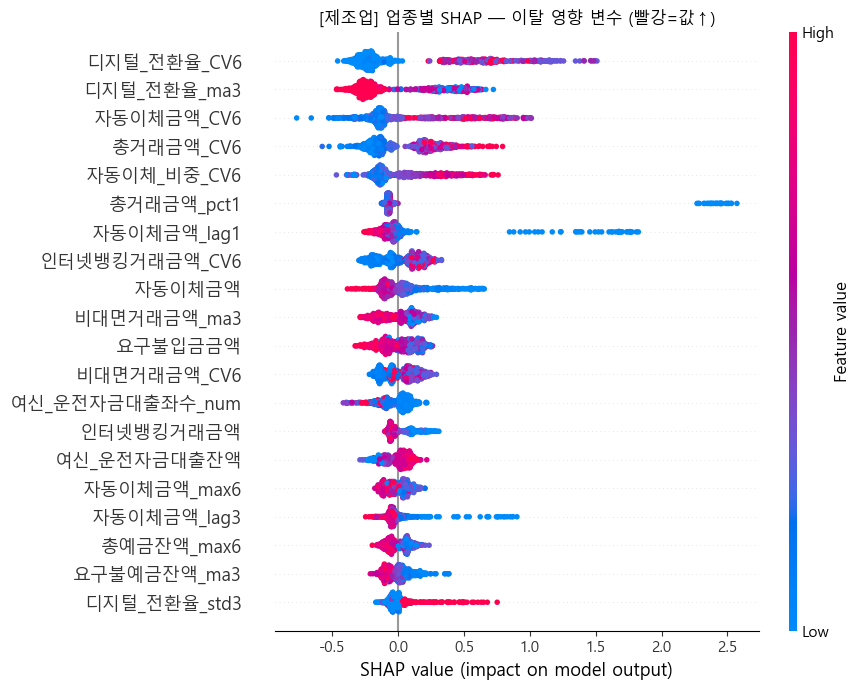


[제조업] SHAP 상위 15
                 평균기여(절대)  평균방향(+이탈↑)
디지털_전환율_CV6        0.3891      0.1050
디지털_전환율_ma3        0.2931     -0.0275
자동이체금액_CV6         0.2699      0.0420
총거래금액_CV6          0.2145      0.0351
자동이체_비중_CV6        0.1902      0.0237
총거래금액_pct1         0.1656      0.0217
자동이체금액_lag1        0.1470      0.0193
인터넷뱅킹거래금액_CV6      0.1360      0.0195
자동이체금액             0.1228      0.0226
비대면거래금액_ma3        0.1158      0.0163
요구불입금금액            0.1058      0.0052
비대면거래금액_CV6        0.1046      0.0159
여신_운전자금대출좌수_num    0.0840     -0.0168
인터넷뱅킹거래금액          0.0773      0.0156
여신_운전자금대출잔액        0.0742     -0.0045


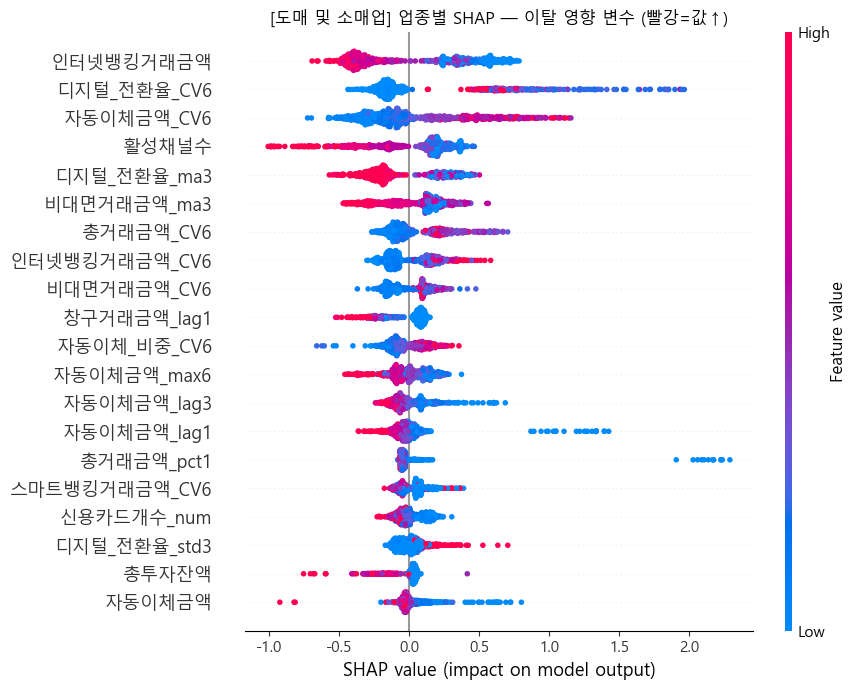


[도매 및 소매업] SHAP 상위 15
               평균기여(절대)  평균방향(+이탈↑)
인터넷뱅킹거래금액        0.3980      0.0145
디지털_전환율_CV6      0.3541      0.1259
자동이체금액_CV6       0.2902      0.0164
활성채널수            0.2537      0.0370
디지털_전환율_ma3      0.2447     -0.0728
비대면거래금액_ma3      0.1910      0.0398
총거래금액_CV6        0.1559      0.0389
인터넷뱅킹거래금액_CV6    0.1521     -0.0021
비대면거래금액_CV6      0.1315     -0.0116
창구거래금액_lag1      0.1171      0.0016
자동이체_비중_CV6      0.1060     -0.0271
자동이체금액_max6      0.1054      0.0001
자동이체금액_lag3      0.0937     -0.0073
자동이체금액_lag1      0.0896      0.0011
총거래금액_pct1       0.0799     -0.0020


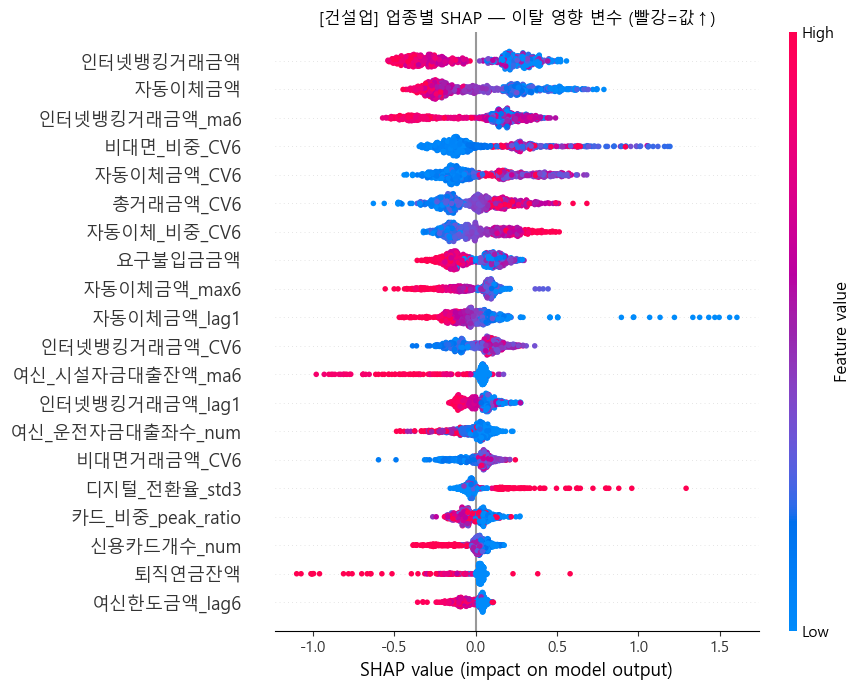


[건설업] SHAP 상위 15
                 평균기여(절대)  평균방향(+이탈↑)
인터넷뱅킹거래금액          0.2946     -0.0360
자동이체금액             0.2473      0.0066
인터넷뱅킹거래금액_ma6      0.2382      0.0412
비대면_비중_CV6         0.2204      0.0427
자동이체금액_CV6         0.1968      0.0256
총거래금액_CV6          0.1582     -0.0055
자동이체_비중_CV6        0.1486      0.0003
요구불입금금액            0.1314     -0.0120
자동이체금액_max6        0.1229     -0.0137
자동이체금액_lag1        0.1221     -0.0136
인터넷뱅킹거래금액_CV6      0.1108      0.0182
여신_시설자금대출잔액_ma6    0.0841     -0.0056
인터넷뱅킹거래금액_lag1     0.0779      0.0135
여신_운전자금대출좌수_num    0.0756     -0.0139
비대면거래금액_CV6        0.0743      0.0055


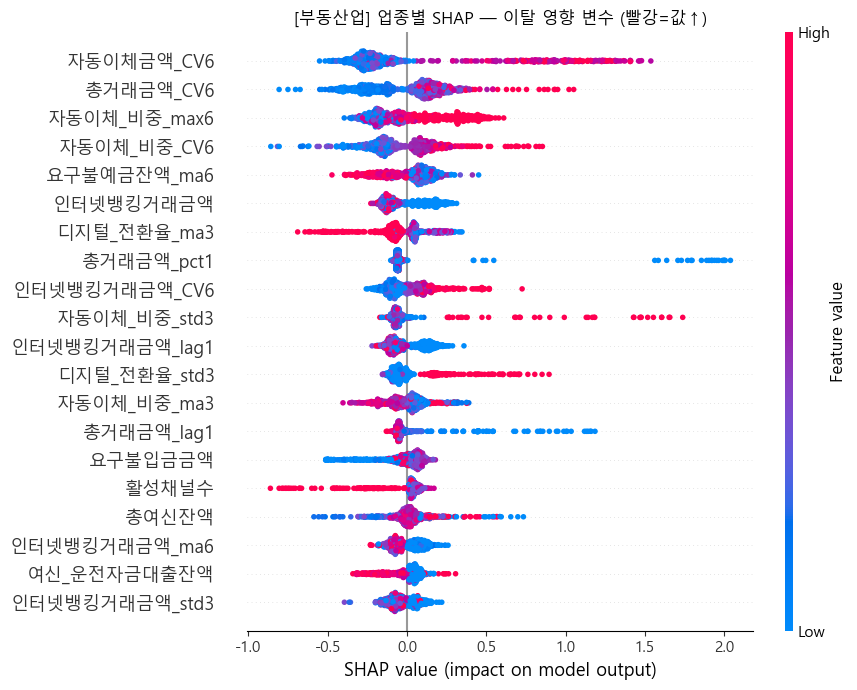


[부동산업] SHAP 상위 15
                평균기여(절대)  평균방향(+이탈↑)
자동이체금액_CV6        0.4016      0.0524
총거래금액_CV6         0.2068      0.0034
자동이체_비중_max6      0.1938      0.0223
자동이체_비중_CV6       0.1756     -0.0312
요구불예금잔액_ma6       0.1240      0.0151
인터넷뱅킹거래금액         0.1236     -0.0112
디지털_전환율_ma3       0.1195     -0.0396
총거래금액_pct1        0.1079     -0.0045
인터넷뱅킹거래금액_CV6     0.1054      0.0071
자동이체_비중_std3      0.1050     -0.0163
인터넷뱅킹거래금액_lag1    0.1018      0.0043
디지털_전환율_std3      0.1017      0.0130
자동이체_비중_ma3       0.0881     -0.0059
총거래금액_lag1        0.0866      0.0029
요구불입금금액           0.0826     -0.0125

업종별 SHAP 저장: IND_SHAP = ['제조업', '도매 및 소매업', '건설업', '부동산업']


: 

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 업종별 모델 각각 SHAP (IND_MODELS에 저장된 pipeline/clip/log/feature 재사용)
IND_SHAP = {}
for ind, info in IND_MODELS.items():
    pipe = info['pipeline']
    num_f = info['num_features']; cat_f = info['cat_features']
    bounds = info['clip_bounds']; logset = info['log_set']

    # 해당 업종 test 데이터를 학습과 동일하게 clip/log 변환
    te_i = df_test[df_test['업종_대분류'] == ind]
    if len(te_i) < 10:
        print(f'[{ind}] 스킵 (test {len(te_i)})'); continue
    te_p = apply_clip_log(te_i, NUM_FEAT_ALL, bounds, logset)

    # 파이프라인 전처리(OneHot) 통과 → 변환된 피처명
    prep = pipe.named_steps['prep']; lgbm = pipe.named_steps['model']
    Xt = prep.transform(te_p[num_f + cat_f])
    Xt = np.asarray(Xt.todense()) if hasattr(Xt, 'todense') else np.asarray(Xt)
    ohe = prep.named_transformers_.get('cat')
    names = (list(ohe.get_feature_names_out(cat_f)) if ohe is not None else []) + num_f

    n = min(800, Xt.shape[0]); Xs = Xt[:n]
    expl = shap.TreeExplainer(lgbm)
    sv = expl.shap_values(Xs)
    if isinstance(sv, list): sv = sv[1]
    sv = np.asarray(sv)
    if sv.ndim == 3: sv = sv[:, :, 1]

    IND_SHAP[ind] = {'shap': sv, 'X': Xs, 'names': names}

    # summary plot
    shap.summary_plot(sv, Xs, feature_names=names, show=False, max_display=20)
    fig = plt.gcf(); fig.set_size_inches(9, 7)
    plt.title(f'[{ind}] 업종별 SHAP — 이탈 영향 변수 (빨강=값↑)')
    plt.tight_layout(); plt.show()

    # 상위 15 (방향 포함)
    mean_abs = pd.Series(np.abs(sv).mean(0), index=names)
    mean_dir = pd.Series(sv.mean(0), index=names)
    top = mean_abs.sort_values(ascending=False).head(15)
    print(f'\n[{ind}] SHAP 상위 15')
    print(pd.DataFrame({'평균기여(절대)': top.round(4),
                        '평균방향(+이탈↑)': mean_dir[top.index].round(4)}).to_string())

print('\n업종별 SHAP 저장: IND_SHAP =', list(IND_SHAP.keys()))